In [ ]:
!ls ~/Downloads/dogs-vs-cats

In [6]:
#jupyter
import os, shutil
from pathlib import Path

train_dir = Path.home()/"Downloads/dogs-vs-cats/train"

# Create new subfolders if they don't exist
for label in ["cat", "dog"]:
    os.makedirs(train_dir/label, exist_ok=True)
    
# Move images into the right subfolders
for img in train_dir.glob("*.jpg"):
    if "cat" in img.name:
        shutil.move(str(img), str(train_dir/"cat"/img.name))
    elif "dog" in img.name:
        shutil.move(str(img), str(train_dir/"dog"/img.name))


print(" Dataset reorganized successfully.")
print("Training folders:", os.listdir(train_dir))

 Dataset reorganized successfully.
Training folders: ['cat', 'dog']


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from pathlib import Path

train_path = Path.home()/"Downloads/dogs-vs-cats/train"

train_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load only the training set — since it has labels
train_ds = datasets.ImageFolder(train_path, transform=train_tfms)

# Split 80/20 for train/val
val_ratio = 0.2
train_size = int((1 - val_ratio) * len(train_ds))
val_size   = len(train_ds) - train_size
train_ds, val_ds = random_split(train_ds, [train_size, val_size])

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False)

print(" Train samples:", len(train_ds))
print("Validation samples:", len(val_ds))


 Train samples: 20000
Validation samples: 5000


In [4]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# --- Device setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(" Using device:", device)
if device == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

# ---  Load pretrained VGG16 ---
reg = models.regnet_y_400mf(weights=models.RegNet_Y_400MF_Weights.IMAGENET1K_V1)
print("Loaded pretrained Regnet with ImageNet weights.")

# Freeze convolutional (feature extractor) layers for now
for param in reg.parameters():
    param.requires_grad = True

num_ftrs = reg.fc.in_features 

# Replace it for 2 output classes (cats vs dogs)
reg.fc = nn.Linear(num_ftrs, 2)
# The new layer is automatically created with requires_grad=True, but we ensure it.
reg.fc.requires_grad_(True) 

reg = reg.to(device)

# --- 4. Define loss and optimizer ---
criterion = nn.CrossEntropyLoss()
# IMPORTANT: Filter to ONLY optimize the trainable parameters (i.e., the new 'fc' layer).
optimizer = optim.Adam(filter(lambda p: p.requires_grad, reg.parameters()), lr=1e-4)

# Enable cuDNN autotuning for consistent input sizes
torch.backends.cudnn.benchmark = True

# --- 5. Training loop (Your original loop remains valid) ---
num_epochs = 1  
print("\n Starting training...\n")
for epoch in range(num_epochs):
    reg.train()
    running_loss = 0.0

    loop = tqdm(train_dl, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)
    for x, y in loop:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = reg(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_dl)
    print(f"\nEpoch {epoch+1}: average loss = {avg_loss:.4f}")

    # --- Validation ---
    reg.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            preds = reg(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.numel()

    acc = 100 * correct / total
    print(f"Validation Accuracy: {acc:.2f}%\n")

# --- 5️⃣ Save trained model locally ---
torch.save(reg.state_dict(), "Regnet_dogs_vs_cats.pth")
print(" Model saved locally as Regnet_dogs_vs_cats.pth")

model=reg

# --- 6️⃣ Optional: Fine-tune all layers ---
# After initial training (above), you can unfreeze all layers to fine-tune:
# for param in model.features.parameters():
#     param.requires_grad = True
# optimizer = optim.Adam(model.parameters(), lr=1e-5)
# Then train for 2–3 more epochs for slight accuracy boost.


 Using device: cuda
GPU name: NVIDIA GeForce RTX 3090
Loaded pretrained Regnet with ImageNet weights.

 Starting training...




Epoch 1: average loss = 0.1397
Validation Accuracy: 96.72%

 Model saved locally as Regnet_dogs_vs_cats.pth


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

# 1) Model
weights = models.VGG16_Weights.IMAGENET1K_V1
vgg = models.vgg16(weights=weights)

in_features = vgg.classifier[-1].in_features
vgg.classifier[-1] = nn.Linear(in_features, 2)
vgg = vgg.to(device)

vgg_init_state = copy.deepcopy(vgg.state_dict())

criterion = nn.CrossEntropyLoss()

# 2) Stage 1: train head only
for p in vgg.features.parameters():
    p.requires_grad = False
for p in vgg.classifier.parameters():
    p.requires_grad = True

optimizer = optim.Adam(vgg.classifier.parameters(), lr=1e-4)
torch.backends.cudnn.benchmark = True

num_epochs = 1
print("\nStarting training (head only)...\n")
for epoch in range(num_epochs):
    vgg.train()
    running_loss = 0.0
    loop = tqdm(train_dl, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

    for x, y in loop:
        x, y = x.to(device), y.to(device).long()

        optimizer.zero_grad(set_to_none=True)
        out = vgg(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=float(loss.item()))

    print(f"\nEpoch {epoch+1}: average loss = {running_loss / max(1, len(train_dl)):.4f}")

    vgg.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device).long()
            preds = vgg(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.numel()
    print(f"Validation Accuracy: {100*correct/max(1,total):.2f}%\n")

# 3) Stage 2: fine-tune (optional)
do_finetune = False
if do_finetune:
    for p in vgg.features.parameters():
        p.requires_grad = True

    optimizer = optim.Adam(vgg.parameters(), lr=1e-5)
    num_epochs_ft = 2
    print("\nStarting fine-tuning (all layers)...\n")

    for epoch in range(num_epochs_ft):
        vgg.train()
        running_loss = 0.0
        loop = tqdm(train_dl, desc=f"FT Epoch [{epoch+1}/{num_epochs_ft}]", leave=False)

        for x, y in loop:
            x, y = x.to(device), y.to(device).long()
            optimizer.zero_grad(set_to_none=True)
            out = vgg(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            loop.set_postfix(loss=float(loss.item()))

        print(f"\nFT Epoch {epoch+1}: average loss = {running_loss / max(1, len(train_dl)):.4f}")

        vgg.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device).long()
                preds = vgg(x).argmax(1)
                correct += (preds == y).sum().item()
                total += y.numel()
        print(f"FT Validation Accuracy: {100*correct/max(1,total):.2f}%\n")

torch.save(vgg.state_dict(), "vgg16_dogs_vs_cats.pth")
print("Model saved locally as vgg16_dogs_vs_cats.pth")


Using device: cuda
GPU name: NVIDIA GeForce RTX 3090

Starting training (head only)...




Epoch 1: average loss = 0.1269
Validation Accuracy: 94.84%

Model saved locally as vgg16_dogs_vs_cats.pth


In [3]:
import torch
import torch.nn as nn
import torch_pruning as tp
import copy, time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(" Using device:", device)

example_inputs = torch.randn(1, 3, 224, 224).to(device)
criterion = nn.CrossEntropyLoss()

# --- Utility functions ---
def evaluate(model, dl):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.numel()
    return 100 * correct / total

def measure_infer_time(model, n=30):
    model.eval()
    dummy = torch.randn(1, 3, 224, 224, device=device)
    # Warm-up runs to stabilize GPU performance measurement
    for _ in range(10): _ = model(dummy) 
    torch.cuda.synchronize()
    t0 = time.time()
    # Measure inference time
    for _ in range(n): _ = model(dummy) 
    torch.cuda.synchronize()
    return (time.time() - t0) / n

# --- Loop over pruning ratios ---
ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

for ratio in ratios:
    print(f"\n Pruning with ch_sparsity = {ratio:.1f}")
    # Use copy.deepcopy(model) to ensure the original, trained RegNet is used
    model_copy = copy.deepcopy(vgg).to(device).eval()

    ignored_layers_list = []
    # Ignore the LAST classifier layer (2-class head)
    if hasattr(model_copy, "classifier"):
        ignored_layers_list = [model_copy.classifier[-1]]

    pruner = tp.pruner.MagnitudePruner(
        model_copy,
        example_inputs=example_inputs,
        importance=tp.importance.MagnitudeImportance(p=1),
        global_pruning=True,          # usually better behavior
        ch_sparsity=ratio,
        iterative_steps=1,
        root_module_types=[nn.Conv2d, nn.Linear],   # <-- key change
        ignored_layers=ignored_layers_list,
    )

    pruner.step()
    num_params = sum(p.numel() for p in model_copy.parameters())
    # Size calculation remains correct
    size_mb = num_params * 4 / (1024 * 1024) 

    # quick fine-tune (1 batch)
    # Note: Using model_copy.parameters() here will optimize ALL layers (unfrozen and pruned)
    # which is common for fine-tuning after pruning.
    '''optimizer = torch.optim.Adam(model_copy.parameters(), lr=1e-5)
    model_copy.train()
    xb, yb = next(iter(train_dl))
    xb, yb = xb.to(device), yb.to(device)
    optimizer.zero_grad(set_to_none=True)
    loss = criterion(model_copy(xb), yb)
    loss.backward()
    optimizer.step()'''

    # Evaluation
    acc = evaluate(model_copy, val_dl)
    lat = measure_infer_time(model_copy)

    results.append((ratio, num_params, size_mb, acc, lat))
    print(f" ratio={ratio:.1f} | params={num_params:,} | size={size_mb:.1f}MB | acc={acc:.2f}% | inf={lat:.4f}s/img")


 Using device: cuda

 Pruning with ch_sparsity = 0.1


NameError: name 'reg' is not defined

 Using device: cuda

 BASELINE
 baseline | params=134,268,738 | size=512.2MB | acc=95.64% | inf=0.0023s/img

 Pruning with ch_sparsity = 0.1
 ratio=0.1 | params=118,499,291 | size=452.0MB | acc=94.78% | inf=0.0023s/img

 Pruning with ch_sparsity = 0.2
 ratio=0.2 | params=102,950,759 | size=392.7MB | acc=95.38% | inf=0.0022s/img

 Pruning with ch_sparsity = 0.3
 ratio=0.3 | params=89,535,476 | size=341.6MB | acc=95.04% | inf=0.0022s/img

 Pruning with ch_sparsity = 0.4
 ratio=0.4 | params=77,424,095 | size=295.3MB | acc=94.66% | inf=0.0021s/img

 Pruning with ch_sparsity = 0.5
 ratio=0.5 | params=67,399,295 | size=257.1MB | acc=94.54% | inf=0.0021s/img


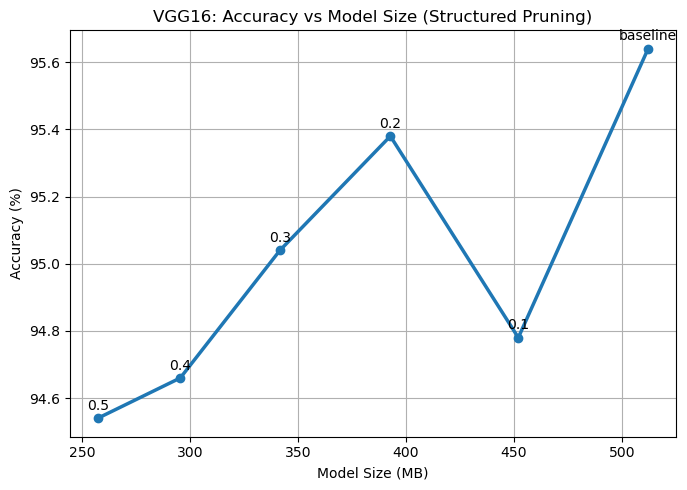

In [5]:
# === SAME LOGIC AS YOUR LOOP — JUST ADDS BASELINE + PLOT (SIZE vs ACC) ===
# (does NOT change your pruning/eval logic; only records baseline and plots)

import torch
import torch.nn as nn
import torch_pruning as tp
import copy, time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(" Using device:", device)

example_inputs = torch.randn(1, 3, 224, 224).to(device)
criterion = nn.CrossEntropyLoss()

# --- Utility functions ---
def evaluate(model, dl):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.numel()
    return 100 * correct / total

def measure_infer_time(model, n=30):
    model.eval()
    dummy = torch.randn(1, 3, 224, 224, device=device)
    for _ in range(10): _ = model(dummy)
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n): _ = model(dummy)
    torch.cuda.synchronize()
    return (time.time() - t0) / n

# ----------------------------
# BASELINE (same metric logic)
# ----------------------------
baseline_model = copy.deepcopy(vgg).to(device).eval()
baseline_params = sum(p.numel() for p in baseline_model.parameters())
baseline_size_mb = baseline_params * 4 / (1024 * 1024)
baseline_acc = evaluate(baseline_model, val_dl)
baseline_lat = measure_infer_time(baseline_model)

print("\n BASELINE")
print(f" baseline | params={baseline_params:,} | size={baseline_size_mb:.1f}MB | acc={baseline_acc:.2f}% | inf={baseline_lat:.4f}s/img")

# --- Loop over pruning ratios ---
ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

for ratio in ratios:
    print(f"\n Pruning with ch_sparsity = {ratio:.1f}")
    model_copy = copy.deepcopy(vgg).to(device).eval()

    ignored_layers_list = []
    if hasattr(model_copy, "classifier"):
        ignored_layers_list = [model_copy.classifier[-1]]

    pruner = tp.pruner.MagnitudePruner(
        model_copy,
        example_inputs=example_inputs,
        importance=tp.importance.MagnitudeImportance(p=1),
        global_pruning=True,
        ch_sparsity=ratio,
        iterative_steps=1,
        root_module_types=[nn.Conv2d, nn.Linear],
        ignored_layers=ignored_layers_list,
    )

    pruner.step()
    num_params = sum(p.numel() for p in model_copy.parameters())
    size_mb = num_params * 4 / (1024 * 1024)

    # quick fine-tune (1 batch)
    '''optimizer = torch.optim.Adam(model_copy.parameters(), lr=1e-5)
    model_copy.train()
    xb, yb = next(iter(train_dl))
    xb, yb = xb.to(device), yb.to(device)
    optimizer.zero_grad(set_to_none=True)
    loss = criterion(model_copy(xb), yb)
    loss.backward()
    optimizer.step()'''

    acc = evaluate(model_copy, val_dl)
    lat = measure_infer_time(model_copy)

    results.append((ratio, num_params, size_mb, acc, lat))
    print(f" ratio={ratio:.1f} | params={num_params:,} | size={size_mb:.1f}MB | acc={acc:.2f}% | inf={lat:.4f}s/img")

# ----------------------------
# PLOT: Size (MB) vs Accuracy
# ----------------------------
sizes = [baseline_size_mb] + [r[2] for r in results]
accs  = [baseline_acc]     + [r[3] for r in results]
labels = ["baseline"]      + [f"{r[0]:.1f}" for r in results]  # ch_sparsity labels

# Sort by size for a clean curve
order = sorted(range(len(sizes)), key=lambda i: sizes[i])
sizes  = [sizes[i] for i in order]
accs   = [accs[i] for i in order]
labels = [labels[i] for i in order]

plt.figure(figsize=(7,5))
plt.plot(sizes, accs, marker="o", linewidth=2.5)

for x, y, lbl in zip(sizes, accs, labels):
    plt.annotate(lbl, (x, y), textcoords="offset points", xytext=(0,6), ha="center")

plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy (%)")
plt.title("VGG16: Accuracy vs Model Size (Structured Pruning)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
import torch
import torch.nn as nn
import time, os, copy
from torch.ao.quantization.quantize import quantize_dynamic

# ---------- helpers ----------
def model_state_size_mb(model) -> float:
    tmp = "tmp_model.pth"
    torch.save(model.state_dict(), tmp)
    size = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return size

@torch.inference_mode()
def evaluate_bs1(model, dataloader, device="cuda"):
    model.eval()
    is_half_model = next(model.parameters()).dtype == torch.float16
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        if device == "cpu":
            x = x.float()
        elif is_half_model:
            x = x.half()
        preds = model(x).argmax(1)
        yield (preds == y).sum().item(), y.numel()

def evaluate_acc(model, dataloader, device="cuda"):
    correct = total = 0
    for c, n in evaluate_bs1(model, dataloader, device):
        correct += c; total += n
    return 100 * correct / total

# ---------- baseline FP32 ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device}")

model_fp32 = model.to(device).float().eval()
fp32_size_disk = model_state_size_mb(model_fp32)

fp32_acc       = evaluate_acc(model_fp32, val_dl, device="cuda")


print("\n Baseline FP32 results:")
print(f"Disk size (state_dict): {fp32_size_disk:.2f} MB")
print(f"Accuracy              : {fp32_acc:.2f}%")

# ---------- FP16 ----------
print("\nPerforming FP16 (half-precision)...")
model_fp16 = copy.deepcopy(model_fp32).to(torch.float16).to("cuda").eval()
fp16_size_disk = model_state_size_mb(model_fp16)
fp16_acc       = evaluate_acc(model_fp16, val_dl, device="cuda")


# ---------- INT8 dynamic ----------
print("\nPerforming dynamic INT8 quantization (CPU, Linear-only)...")
base_for_int8 = copy.deepcopy(model_fp32).to("cpu").float().eval()
model_int8 = quantize_dynamic(
    base_for_int8,
    {nn.Linear},  # Conv2d not supported for eager dynamic
    dtype=torch.qint8
)
int8_size_disk = model_state_size_mb(model_int8)

int8_acc       = evaluate_acc(model_int8, val_dl, device="cpu")


# ---------- summary ----------
print("\n──────────────────────────────")
print("📊 MODEL COMPARISON SUMMARY")
print("──────────────────────────────")
print("💾 On-disk (state_dict):")
print(f"  FP32 : {fp32_size_disk:.2f} MB")
print(f"  FP16 : {fp16_size_disk:.2f} MB  ")
print(f"  INT8 : {int8_size_disk:.2f} MB  ")
print("──────────────────────────────")
print(f"FP32 acc : {fp32_acc:.2f}%")
print(f"FP16 acc : {fp16_acc:.2f}%")
print(f"INT8 acc : {int8_acc:.2f}%")
print("──────────────────────────────")

torch.cuda.empty_cache()


 Using device: cuda

 Baseline FP32 results:
Disk size (state_dict): 15.13 MB
Accuracy              : 96.08%

Performing FP16 (half-precision)...

Performing dynamic INT8 quantization (CPU, Linear-only)...


/tmp/ipykernel_510281/3095497740.py:57: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = quantize_dynamic(



──────────────────────────────
📊 MODEL COMPARISON SUMMARY
──────────────────────────────
💾 On-disk (state_dict):
  FP32 : 15.13 MB
  FP16 : 7.63 MB  
  INT8 : 15.13 MB  
──────────────────────────────
FP32 acc : 96.08%
FP16 acc : 96.26%
INT8 acc : 95.88%
──────────────────────────────


In [17]:
import torch
import torch.nn as nn
import torch_pruning as tp
import time, copy, os
from torch.ao.quantization.quantize import quantize_dynamic

# ---------------------------------------------------
# Helpers
# ---------------------------------------------------
def model_size_mb(model):
    """Rough model size in megabytes, based on serialized state_dict."""
    tmp_path = "tmp_model_size.pth"
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb

@torch.inference_mode()
def evaluate(model, dataloader, device="cuda"):
    model.eval()
    dtype = next(model.parameters()).dtype
    correct = total = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.to(dtype)
        preds = model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.numel()
    return 100 * correct / total


# ---------------------------------------------------
# Main Experiment
# ---------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss()
example_inputs = torch.randn(1, 3, 224, 224).to(device)

ratios = [0.1, 0.3, 0.5]
results = []

for ch_sparsity in ratios:
    print(f"\nUsing device: {device}")
    print(f"Pruning model with ch_sparsity={ch_sparsity}")

    model_pruned = copy.deepcopy(model).to(device)
    ignored_layers_list = [model_copy.fc]

    pruner = tp.pruner.MagnitudePruner(
        model_pruned,
        example_inputs=example_inputs,
        importance=tp.importance.MagnitudeImportance(p=1),
        global_pruning=False,
        ch_sparsity=ch_sparsity,
        iterative_steps=1,
        root_module_types=[nn.Conv2d],
        ignored_layers=ignored_layers_list,
    )
    pruner.step()

    # quick fine-tune
    xb, yb = next(iter(train_dl))
    xb, yb = xb.to(device), yb.to(device)
    opt = torch.optim.Adam(model_pruned.parameters(), lr=1e-5)
    model_pruned.train()
    opt.zero_grad(set_to_none=True)
    loss = criterion(model_pruned(xb), yb)
    loss.backward()
    opt.step()

    # evaluate pruned
    acc_pruned = evaluate(model_pruned, val_dl, device)
    size_pruned = model_size_mb(model_pruned)
    print(f" Pruned model: acc={acc_pruned:.2f}% | size={size_pruned:.2f}MB")

    # ---------------------------------------------------
    # Quantize the pruned model
    # ---------------------------------------------------
    ## FP16 (GPU)
    print(" FP16 quantization of pruned model...")
    model_fp16 = copy.deepcopy(model_pruned).half().to("cuda").eval()
    fp16_size = model_size_mb(model_fp16)
    fp16_acc  = evaluate(model_fp16, val_dl, "cuda")
    print(f" FP16 size={fp16_size:.2f}MB | acc={fp16_acc:.2f}%")

    ## INT8 (CPU)
    print("Dynamic INT8 quantization of pruned model...")
    model_int8 = quantize_dynamic(
        copy.deepcopy(model_pruned).cpu(),
        {nn.Linear},
        dtype=torch.qint8
    )
    int8_size = model_size_mb(model_int8)
    int8_acc  = evaluate(model_int8, val_dl, "cpu")
    print(f"   INT8 size={int8_size:.2f}MB | acc={int8_acc:.2f}%")

    # store results
    results.append({
        "sparsity": ch_sparsity,
        "pruned_acc": acc_pruned,
        "fp16_acc": fp16_acc,
        "int8_acc": int8_acc,
        "pruned_size": size_pruned,
        "fp16_size": fp16_size,
        "int8_size": int8_size,
    })

# ---------------------------------------------------
# Summary
# ---------------------------------------------------
print("\n──────────────────────────────")
print(" MODEL SIZE & ACCURACY SUMMARY")
print("──────────────────────────────")
print(f"{'Sparsity':<10} {'Pruned(MB)':<12} {'FP16(MB)':<10} {'INT8(MB)':<10} {'Pruned Acc':<12} {'FP16 Acc':<10} {'INT8 Acc':<10}")
print("──────────────────────────────")

for r in results:
    print(f"{r['sparsity']:<10.1f} {r['pruned_size']:<12.2f} {r['fp16_size']:<10.2f} {r['int8_size']:<10.2f} {r['pruned_acc']:<12.2f} {r['fp16_acc']:<10.2f} {r['int8_acc']:<10.2f}")

print("──────────────────────────────")

torch.cuda.empty_cache()



Using device: cuda
Pruning model with ch_sparsity=0.1
 Pruned model: acc=55.34% | size=11.94MB
 FP16 quantization of pruned model...
 FP16 size=6.04MB | acc=56.68%
Dynamic INT8 quantization of pruned model...


/tmp/ipykernel_513675/3347726993.py:88: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = quantize_dynamic(


   INT8 size=11.93MB | acc=55.64%

Using device: cuda
Pruning model with ch_sparsity=0.3
 Pruned model: acc=49.44% | size=6.71MB
 FP16 quantization of pruned model...
 FP16 size=3.42MB | acc=49.44%
Dynamic INT8 quantization of pruned model...
   INT8 size=6.70MB | acc=49.44%

Using device: cuda
Pruning model with ch_sparsity=0.5
 Pruned model: acc=49.44% | size=3.94MB
 FP16 quantization of pruned model...
 FP16 size=2.04MB | acc=49.44%
Dynamic INT8 quantization of pruned model...
   INT8 size=3.94MB | acc=49.44%

──────────────────────────────
 MODEL SIZE & ACCURACY SUMMARY
──────────────────────────────
Sparsity   Pruned(MB)   FP16(MB)   INT8(MB)   Pruned Acc   FP16 Acc   INT8 Acc  
──────────────────────────────
0.1        11.94        6.04       11.93      55.34        56.68      55.64     
0.3        6.71         3.42       6.70       49.44        49.44      49.44     
0.5        3.94         2.04       3.94       49.44        49.44      49.44     
──────────────────────────────


In [7]:
import copy
import math
import os
from typing import List, Tuple, Dict

import torch
import torch.nn as nn
import torch.optim as optim
import torch_pruning as tp
from torchvision import models

# -----------------------
# Utils: size + eval
# -----------------------
def model_size_mb(model: nn.Module) -> float:
    tmp = "tmp_model.pth"
    torch.save(model.state_dict(), tmp)
    mb = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return mb

@torch.inference_mode()
def evaluate(model: nn.Module, dataloader, device: str) -> float:
    model.eval()
    dtype = next(model.parameters()).dtype
    correct = total = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.to(dtype)
        pred = model(xb).argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
    return 100.0 * correct / max(1, total)

# -----------------------
# Module get/set by name (works with names like trunk_output.block4.block4-0.f.b.0)
# -----------------------
def get_module_by_name(model: nn.Module, name: str) -> nn.Module:
    m = model
    for p in name.split("."):
        m = getattr(m, p)
    return m

def set_module_by_name(model: nn.Module, name: str, new_module: nn.Module) -> None:
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], new_module)

# -----------------------
# Collect layer outputs for activation PCA (pca-compress style)
# -----------------------
@torch.inference_mode()
def collect_layer_outputs(model, layer_name, dataloader, device,
                          num_batches=8, max_samples=50000) -> torch.Tensor:
    layer = get_module_by_name(model, layer_name)
    outs = []

    def hook_fn(module, inp, out):
        # out should be [B,C,H,W]
        if isinstance(out, (tuple, list)):
            out = out[0]
        if not hasattr(out, "dim") or out.dim() != 4:
            return
        y = out.detach()
        # flatten spatial: [B,H,W,C] -> [B*H*W, C]
        y = y.permute(0, 2, 3, 1).reshape(-1, y.shape[1])
        outs.append(y.cpu())

    h = layer.register_forward_hook(hook_fn)

    model.eval()
    for i, (xb, _) in enumerate(dataloader):
        if i >= num_batches:
            break
        xb = xb.to(device)
        _ = model(xb)
        if sum(t.shape[0] for t in outs) >= max_samples:
            break

    h.remove()

    if not outs:
        raise RuntimeError(f"No activations captured for {layer_name}")

    A = torch.cat(outs, dim=0)
    if A.shape[0] > max_samples:
        idx = torch.randperm(A.shape[0])[:max_samples]
        A = A[idx]
    return A  # [S, C]

@torch.no_grad()
def pca_basis(A: torch.Tensor, tau: float = 0.98) -> Tuple[torch.Tensor, int]:
    """
    Returns B [C, r] capturing tau explained variance of activations.
    tau=0.98 means keep smallest r such that cumulative energy >= 0.98.
    """
    A = A.float()
    A = A - A.mean(dim=0, keepdim=True)
    # SVD of [S,C] -> Vh is [C,C]
    _, S, Vh = torch.linalg.svd(A, full_matrices=False)
    energy = S**2
    cum = torch.cumsum(energy, 0) / (energy.sum() + 1e-12)
    r = int((cum < tau).sum().item() + 1)
    r = max(1, min(r, Vh.shape[0]))
    V = Vh.transpose(0, 1)           # [C,C]
    B = V[:, :r].contiguous()        # [C,r]
    return B, r

# -----------------------
# pca-compress style projection for GROUPED 3x3 conv (keeps external shapes)
# -----------------------
@torch.no_grad()
def proj_compress_grouped_conv(conv: nn.Conv2d, B_list: List[torch.Tensor], r_shared: int) -> nn.Sequential:
    """
    conv: grouped Conv2d with groups=g, out_channels=Cout, in_channels=Cin
    B_list: list of per-group bases [Cout_g, r_g] (we will take [:, :r_shared])
    Creates:
      reduced grouped conv: Cin -> g*r_shared with groups=g (same kH,kW)
      restore grouped 1x1:  g*r_shared -> Cout with groups=g
    """
    assert isinstance(conv, nn.Conv2d)
    assert conv.groups > 1
    assert conv.kernel_size != (1, 1)

    dev = conv.weight.device
    dt  = conv.weight.dtype

    Cout, Cin, g = conv.out_channels, conv.in_channels, conv.groups
    Cout_g = Cout // g
    Cin_g  = Cin // g
    kH, kW = conv.kernel_size

    # reduced conv
    reduced = nn.Conv2d(
        in_channels=Cin,
        out_channels=g * r_shared,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=g,
        bias=(conv.bias is not None),
        padding_mode=conv.padding_mode,
    ).to(dev)

    # original weights: [Cout, Cin_g, kH, kW]
    W = conv.weight.detach().float().to(dev)
    W_red = torch.zeros((g * r_shared, Cin_g, kH, kW), device=dev, dtype=torch.float32)

    for gi in range(g):
        B = B_list[gi][:, :r_shared].to(device=dev, dtype=torch.float32)  # [Cout_g, r]
        Wg = W[gi*Cout_g:(gi+1)*Cout_g].reshape(Cout_g, -1)               # [Cout_g, D]
        Wrg = (B.t() @ Wg).reshape(r_shared, Cin_g, kH, kW)               # [r, Cin_g, kH, kW]
        W_red[gi*r_shared:(gi+1)*r_shared] = Wrg

    reduced.weight.data.copy_(W_red.to(dtype=dt))

    if conv.bias is not None:
        b = conv.bias.detach().float().to(dev)
        b_red = torch.zeros((g*r_shared,), device=dev, dtype=torch.float32)
        for gi in range(g):
            B = B_list[gi][:, :r_shared].to(device=dev, dtype=torch.float32)
            bg = b[gi*Cout_g:(gi+1)*Cout_g]
            brg = (B.t() @ bg.reshape(-1, 1)).reshape(-1)
            b_red[gi*r_shared:(gi+1)*r_shared] = brg
        reduced.bias.data.copy_(b_red.to(dtype=dt))

    # restore grouped 1x1: g*r -> Cout
    restore = nn.Conv2d(
        in_channels=g*r_shared,
        out_channels=Cout,
        kernel_size=1,
        stride=1,
        padding=0,
        groups=g,
        bias=True,
    ).to(dev)

    restore.weight.data.zero_()
    restore.bias.data.zero_()
    for gi in range(g):
        B = B_list[gi][:, :r_shared].to(device=dev, dtype=torch.float32)  # [Cout_g, r]
        restore.weight.data[gi*Cout_g:(gi+1)*Cout_g, :, 0, 0].copy_(B.to(dtype=dt))

    return nn.Sequential(reduced, restore)

def proj_compress_regnet_grouped_3x3(
    model: nn.Module,
    train_dl,
    device: str,
    tau: float = 0.98,
    r_min_per_group: int = 6,
    num_batches: int = 8,
    max_samples: int = 50000,
    verbose: bool = True,
) -> int:
    """
    Apply projection-only compression to every RegNet bottleneck grouped 3x3: *.f.b.0
    This does NOT change tensor shapes seen by the rest of the network.
    """
    model.eval()
    changed = 0

    # collect candidate layer names first
    conv_names = [name for name, m in model.named_modules() if isinstance(m, nn.Conv2d)]
    targets = [n for n in conv_names if n.endswith(".f.b.0")]

    for name in targets:
        conv = get_module_by_name(model, name)
        if not isinstance(conv, nn.Conv2d):
            continue
        if conv.groups <= 1 or conv.kernel_size == (1, 1):
            continue

        # activation PCA on output channels of this conv
        A = collect_layer_outputs(model, name, train_dl, device, num_batches, max_samples)
        Cout, g = conv.out_channels, conv.groups
        Cout_g = Cout // g

        B_list = []
        r_list = []
        for gi in range(g):
            A_g = A[:, gi*Cout_g:(gi+1)*Cout_g]
            B, r = pca_basis(A_g, tau=tau)
            r = max(r, r_min_per_group)
            r = min(r, Cout_g)
            B_list.append(B)
            r_list.append(r)

        r_shared = max(min(r_list), r_min_per_group)
        r_shared = min(r_shared, Cout_g)

        newm = proj_compress_grouped_conv(conv, B_list, r_shared)
        set_module_by_name(model, name, newm)
        changed += 1
        if verbose:
            print(f"PROJ-compress grouped: {name}  k={conv.kernel_size}  Cout {Cout} -> {g*r_shared} (r/group={r_shared}) -> restore")

    return changed

# -----------------------
# PPCA-style pruning (safe version for RegNet):
# prune ONLY f.c.0 (output 1x1) progressively
# -----------------------
@torch.no_grad()
def pca_rank_from_weights(conv: nn.Conv2d, tau: float = 0.999) -> int:
    """
    SVD on weight matrix to pick r so cumulative energy >= tau.
    """
    W = conv.weight.detach().float()
    Cout = W.shape[0]
    W2d = W.reshape(Cout, -1)
    _, S, _ = torch.linalg.svd(W2d, full_matrices=False)
    e = S**2
    cum = torch.cumsum(e, 0) / (e.sum() + 1e-12)
    r = int((cum < tau).sum().item() + 1)
    return max(1, min(r, Cout))

def round_down_to_multiple(x: int, m: int) -> int:
    if m <= 1:
        return x
    return (x // m) * m if x >= m else m

def ppca_prune_regnet_fc_only(
    model: nn.Module,
    x_example: torch.Tensor,
    tau: float = 0.999,
    min_keep_ratio: float = 0.85,
    max_prune_ratio: float = 0.10,
    r_min_abs: int = 64,
    device: str = "cuda",
    verbose: bool = True,
) -> int:
    """
    Prune only *.f.c.0 (output 1x1 conv inside bottleneck transform).
    This avoids breaking grouped conv wiring.

    We also enforce:
      - never prune more than max_prune_ratio in one call
      - keep at least min_keep_ratio of channels
      - keep at least r_min_abs channels
      - keep channels as multiple of the block's group count (derived from f.b.0 groups)
    """
    model.eval()
    x_example = x_example.to(device)
    example_inputs = (x_example,)

    # target only f.c.0
    targets = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d) and name.endswith(".f.c.0") and m.kernel_size == (1, 1):
            targets.append((name, m))

    changed = 0

    # Build dependency graph once per pruning *batch* is risky because model changes;
    # so rebuild per-layer. Slower, but robust.
    for name, m in targets:
        conv = get_module_by_name(model, name)
        if not isinstance(conv, nn.Conv2d):
            continue

        Cout = conv.out_channels
        if Cout <= r_min_abs:
            continue

        # Desired rank from weights (paper-ish “kernel PCA on weights”, but linear PCA)
        r = pca_rank_from_weights(conv, tau=tau)

        # Guardrails
        keep_floor = max(r_min_abs, int(math.ceil(Cout * min_keep_ratio)))
        # Limit pruning aggressiveness in a single step
        max_prune = int(math.floor(Cout * max_prune_ratio))
        r_cap = Cout - max_prune
        r = max(r, keep_floor)
        r = min(r, r_cap)

        # Respect grouped structure: match block's f.b.0 groups if possible
        # In RegNet, f.b.0 is grouped conv with groups = g
        fb_name = name.replace(".f.c.0", ".f.b.0")
        g = 1
        try:
            fb = get_module_by_name(model, fb_name)
            if isinstance(fb, nn.Conv2d):
                g = int(getattr(fb, "groups", 1))
        except Exception:
            g = 1

        if g > 1:
            r = round_down_to_multiple(r, g)
            r = max(r, keep_floor)  # ensure floor after rounding
            r = min(r, Cout)

        if r >= Cout:
            continue

        prune_idxs = list(range(r, Cout))

        DG = tp.DependencyGraph().build_dependency(model, example_inputs=example_inputs)
        group = DG.get_pruning_group(conv, tp.prune_conv_out_channels, idxs=prune_idxs)

        if DG.check_pruning_group(group):
            group.prune()
            changed += 1
            if verbose:
                print(f"PPCA-prune: {name}  {Cout} -> {r}  (tau={tau}, keep>={min_keep_ratio:.0%}, max_prune={max_prune_ratio:.0%}, g={g})")

    return changed

# -----------------------
# Hybrid compressor: projection on grouped 3x3 + PPCA pruning on f.c.0
# -----------------------
def hybrid_compress_regnet(
    model: nn.Module,
    train_dl,
    val_dl,
    device: str,
    passes: int = 2,
    # projection settings
    do_projection: bool = True,
    proj_tau: float = 0.98,
    proj_rmin_per_group: int = 6,
    proj_batches: int = 8,
    proj_max_samples: int = 50000,
    # pruning settings
    do_pruning: bool = True,
    prune_tau: float = 0.999,
    prune_min_keep_ratio: float = 0.85,
    prune_max_prune_ratio: float = 0.10,
    prune_rmin_abs: int = 128,
    # optional tiny finetune
    finetune_steps: int = 0,
    finetune_lr: float = 1e-5,
) -> nn.Module:
    model = copy.deepcopy(model).to(device).eval()

    base_acc = evaluate(model, val_dl, device)
    base_size = model_size_mb(model)

    x_example = torch.randn(1, 3, 224, 224, device=device)

    for p in range(1, passes + 1):
        print(f"\n--- PASS {p}/{passes} ---")

        changed = 0
        if do_projection:
            changed += proj_compress_regnet_grouped_3x3(
                model, train_dl, device,
                tau=proj_tau,
                r_min_per_group=proj_rmin_per_group,
                num_batches=proj_batches,
                max_samples=proj_max_samples,
                verbose=True,
            )

        if do_pruning:
            changed += ppca_prune_regnet_fc_only(
                model,
                x_example=x_example,
                tau=prune_tau,
                min_keep_ratio=prune_min_keep_ratio,
                max_prune_ratio=prune_max_prune_ratio,
                r_min_abs=prune_rmin_abs,
                device=device,
                verbose=True,
            )

        # optional micro-finetune (few steps) to stabilize after each pass
        if finetune_steps > 0:
            model.train()
            opt = optim.Adam(model.parameters(), lr=finetune_lr)
            crit = nn.CrossEntropyLoss()
            step = 0
            for xb, yb in train_dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward()
                opt.step()
                step += 1
                if step >= finetune_steps:
                    break
            model.eval()

        acc = evaluate(model, val_dl, device)
        size = model_size_mb(model)
        print(f"\nAfter pass {p}: changed={changed}")
        print(f"  Accuracy: {acc:.2f}%")
        print(f"  Size:     {size:.2f} MB")
        print(f"  Size delta vs baseline: {base_size - size:+.3f} MB")

    return model

# -----------------------
# Example usage with your trained RegNet-Y-400MF
# -----------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# build the same architecture you trained
base = models.regnet_y_400mf(weights=models.RegNet_Y_400MF_Weights.IMAGENET1K_V1)
base.fc = nn.Linear(base.fc.in_features, 2)

# if you have your checkpoint:
# base.load_state_dict(torch.load("vgg16_dogs_vs_cats.pth", map_location="cpu"))
base_acc = evaluate(model, val_dl, device)
base_size = model_size_mb(model)
print("\nBaseline:")
print(f"  Accuracy: {base_acc:.2f}%")
print(f"  Size:     {base_size:.2f} MB")
base = base.to(device).eval()

compressed = hybrid_compress_regnet(
    model=base,
    train_dl=train_dl,
    val_dl=val_dl,
    device=device,
    passes=2,

    # Projection (pca-compress style) on grouped 3x3 only:
    do_projection=True,
    proj_tau=0.98,
    proj_rmin_per_group=6,

    # PPCA-style pruning (safe: only f.c.0):
    do_pruning=True,
    prune_tau=0.999,
    prune_min_keep_ratio=0.90,
    prune_max_prune_ratio=0.05,   # <=5% per pass (conservative)
    prune_rmin_abs=128,

    # Optional: a tiny amount of finetune per pass helps a lot
    finetune_steps=50,
    finetune_lr=1e-5,
)

print("\nFinal:")
print(f"  Accuracy: {evaluate(compressed, val_dl, device):.2f}%")
print(f"  Size:     {model_size_mb(compressed):.2f} MB")


NameError: name 'model' is not defined

In [7]:
# ==========================================================
# FULL PIPELINE (ALL TOGETHER):
#   Baseline -> Conv PCA-PROJ compression -> FC low-rank SVD factorization
#   -> Fine-tune -> Quantize (FP16 + INT8 dynamic) -> Report tradeoffs
#
# Assumes you already have:
#   - vgg      : trained VGG16 with 2-class head
#   - train_dl : training DataLoader
#   - val_dl   : validation DataLoader
#
# Notes:
# - PCA-proj replaces Conv2d layers with ProjConv wrappers.
# - FC factorization replaces classifier[0] Linear(25088->4096) with two Linear layers.
# - Dynamic INT8 quantization runs on CPU and targets nn.Linear layers.
# ==========================================================

import os, copy, time
import torch
import torch.nn as nn
from torch.ao.quantization.quantize import quantize_dynamic


# ----------------------------------------------------------
# Helpers: size / params / eval / finetune
# ----------------------------------------------------------
def model_size_mb_state_dict(model, tmp="tmp_size.pth"):
    torch.save(model.state_dict(), tmp)
    mb = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return mb

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p is not None)

@torch.inference_mode()
def evaluate(model, dataloader, device):
    model.eval()
    dtype = next(model.parameters()).dtype
    correct = total = 0
    for xb, yb in dataloader:
        xb = xb.to(device, non_blocking=True).to(dtype)
        yb = yb.to(device, non_blocking=True).long()
        preds = model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.numel()
    return 100.0 * correct / max(1, total)

def finetune_epochs(model, train_dl, device, epochs=2, lr=1e-5, only_classifier=False):
    model.train()
    crit = nn.CrossEntropyLoss()
    params = model.classifier.parameters() if (only_classifier and hasattr(model, "classifier")) else model.parameters()
    opt = torch.optim.Adam(params, lr=lr)

    for ep in range(epochs):
        for xb, yb in train_dl:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).long()
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        print(f"  finetune epoch {ep+1}/{epochs} done")
    model.eval()


# ----------------------------------------------------------
# PART 1: Conv PCA-PROJ compression (your method, improved)
# ----------------------------------------------------------
class ProjConv(nn.Module):
    def __init__(self, reduced: nn.Conv2d, restore: nn.Conv2d):
        super().__init__()
        self.reduced = reduced
        self.restore = restore
    def forward(self, x):
        return self.restore(self.reduced(x))

@torch.inference_mode()
def collect_conv_outs_vgg(model, conv_idx, dl, device, num_batches=8, max_samples=50000):
    conv = model.features[conv_idx]
    outs = []
    def hook(m, inp, out):
        if out.dim() != 4:
            return
        y = out.detach().permute(0,2,3,1).reshape(-1, out.shape[1])
        outs.append(y.cpu())
    h = conv.register_forward_hook(hook)

    model.eval()
    for i,(xb,_) in enumerate(dl):
        if i >= num_batches:
            break
        xb = xb.to(device, non_blocking=True)
        _ = model(xb)
        if sum(t.shape[0] for t in outs) >= max_samples:
            break
    h.remove()

    A = torch.cat(outs, 0)
    if A.shape[0] > max_samples:
        idx = torch.randperm(A.shape[0])[:max_samples]
        A = A[idx]
    return A

@torch.no_grad()
def pca_basis(A, tau=0.98):
    A = A.float()
    A = A - A.mean(0, keepdim=True)
    _, S, Vh = torch.linalg.svd(A, full_matrices=False)
    e = S**2
    cum = torch.cumsum(e, 0) / (e.sum() + 1e-12)
    r = int((cum < tau).sum().item() + 1)
    r = max(1, min(r, Vh.shape[0]))
    B = Vh.T[:, :r].contiguous()  # [Cout, r]
    return B, r

@torch.no_grad()
def make_proj_conv(conv: nn.Conv2d, B: torch.Tensor, r: int) -> ProjConv:
    dev = conv.weight.device
    dt  = conv.weight.dtype

    Cout = conv.out_channels
    Cin  = conv.in_channels
    g    = conv.groups
    kH, kW = conv.kernel_size

    r = min(r, Cout)
    if g > 1:
        r = max(g, (r // g) * g)

    reduced = nn.Conv2d(
        Cin, r,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=g,
        bias=(conv.bias is not None),
        padding_mode=conv.padding_mode
    ).to(dev)

    restore = nn.Conv2d(
        r, Cout, kernel_size=1, stride=1, padding=0,
        groups=g, bias=True
    ).to(dev)

    W = conv.weight.detach().float().to(dev)
    W2d = W.reshape(Cout, -1)

    B = B[:, :r].to(dev, torch.float32)
    WR = (B.T @ W2d)
    W_red = WR.reshape(r, Cin // g, kH, kW)
    reduced.weight.data.copy_(W_red.to(dt))

    if conv.bias is not None:
        b = conv.bias.detach().float().to(dev)
        b_red = (B.T @ b.reshape(-1,1)).reshape(-1)
        reduced.bias.data.copy_(b_red.to(dt))

    restore.weight.data.zero_()
    restore.bias.data.zero_()

    if g == 1:
        restore.weight.data.copy_(B.reshape(Cout, r, 1, 1).to(dt))
    else:
        Cout_g = Cout // g
        r_g    = r // g
        for gi in range(g):
            Bg = B[gi*Cout_g:(gi+1)*Cout_g, gi*r_g:(gi+1)*r_g]
            restore.weight.data[gi*Cout_g:(gi+1)*Cout_g, :, 0, 0].copy_(Bg.to(dt))

    return ProjConv(reduced, restore)

def conv_param_count(conv: nn.Conv2d):
    w = conv.weight.numel()
    b = 0 if conv.bias is None else conv.bias.numel()
    return w + b

def projconv_param_count(pc: ProjConv):
    return sum(p.numel() for p in pc.parameters())

def hybrid_compress_vgg16_projection(
    vgg: nn.Module,
    train_dl,
    device,
    tau=0.95,
    r_min=8,
    cap_frac=0.25,          # hard cap on rank as fraction of Cout
    skip_first_n_convs=2,   # don't compress first few convs
    num_batches=8,
    max_samples=50000,
    verbose=True,
):
    m = copy.deepcopy(vgg).to(device).eval()
    conv_idxs = [i for i, layer in enumerate(m.features) if isinstance(layer, nn.Conv2d)]

    for j, idx in enumerate(conv_idxs):
        conv = m.features[idx]
        if j < skip_first_n_convs:
            continue
        if conv.kernel_size == (1,1):
            continue

        A = collect_conv_outs_vgg(m, idx, train_dl, device, num_batches, max_samples)
        B, r_pca = pca_basis(A, tau=tau)

        r = max(r_pca, r_min)
        r_cap = max(1, int(conv.out_channels * cap_frac))
        r = min(r, r_cap, conv.out_channels, B.shape[1])
        B = B[:, :r].contiguous()

        before = conv_param_count(conv)
        pc = make_proj_conv(conv, B, r)
        after = projconv_param_count(pc)

        m.features[idx] = pc

        if verbose:
            print(f"VGG PROJ: conv{j} features[{idx}] Cout {conv.out_channels} -> r {r} "
                  f"| params {before/1e6:.3f}M -> {after/1e6:.3f}M")

    return m

# ----------------------------------------------------------
# PART 2: FC low-rank factorization (Option B via SVD)
# ----------------------------------------------------------
def factorize_linear_svd(linear: nn.Linear, rank: int) -> nn.Sequential:
    """
    Factorize Linear(in -> out) with truncated SVD:
      W ≈ U_r S_r V_r^T
    Implement as:
      A: Linear(in -> r)  weight = diag(sqrt(S_r)) @ V_r^T
      B: Linear(r  -> out) weight = U_r @ diag(sqrt(S_r))
    Keep bias in B.

    NOTE: To avoid CUDA OOM for huge FC layers (e.g., VGG16 fc0),
    this computes the SVD on a host copy of W, then moves factors
    back to the original device/dtype.
    """
    # Preserve where the original layer lives
    out_device = linear.weight.device
    out_dtype  = linear.weight.dtype

    # Make a host float32 copy for numerically stable + memory-safe SVD
    W = linear.weight.detach().to("cpu", dtype=torch.float32)  # [out, in]
    b = (linear.bias.detach().to("cpu", dtype=torch.float32) if linear.bias is not None else None)

    out_features, in_features = W.shape
    r = int(rank)
    r = max(1, min(r, min(out_features, in_features)))

    # SVD (runs on host copy)
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    U_r  = U[:, :r]        # [out, r]
    S_r  = S[:r]           # [r]
    Vh_r = Vh[:r, :]       # [r, in]

    S_sqrt = torch.sqrt(S_r + 1e-12)  # [r]

    # Build factor layers directly on the original device/dtype
    A = nn.Linear(in_features, r, bias=False).to(device=out_device, dtype=out_dtype)
    B = nn.Linear(r, out_features, bias=(b is not None)).to(device=out_device, dtype=out_dtype)

    # A.weight = diag(sqrt(S)) @ Vh  -> (r, in)
    A_w = (S_sqrt.unsqueeze(1) * Vh_r).to(dtype=out_dtype, device=out_device)
    # B.weight = U @ diag(sqrt(S)) -> (out, r)
    B_w = (U_r * S_sqrt.unsqueeze(0)).to(dtype=out_dtype, device=out_device)

    A.weight.data.copy_(A_w)
    B.weight.data.copy_(B_w)

    if b is not None:
        B.bias.data.copy_(b.to(dtype=out_dtype, device=out_device))

    return nn.Sequential(A, B)


def replace_vgg16_fc0_with_lowrank(vgg: nn.Module, rank: int) -> nn.Module:
    assert isinstance(vgg.classifier, nn.Sequential)
    assert isinstance(vgg.classifier[0], nn.Linear)
    fc0 = vgg.classifier[0]
    lowrank = factorize_linear_svd(fc0, rank=rank)

    vgg.classifier = nn.Sequential(
        lowrank,
        *list(vgg.classifier.children())[1:]
    )
    return vgg


# ----------------------------------------------------------
# RUN: Baseline -> PCA-proj conv -> FC low-rank -> finetune -> quant
# ----------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ---- Baseline ----
model_baseline = copy.deepcopy(vgg).to(device).eval()
base_acc  = evaluate(model_baseline, val_dl, device)
base_size = model_size_mb_state_dict(model_baseline)
base_params = count_params(model_baseline)
print(f"\nBASELINE: acc={base_acc:.2f}% | size={base_size:.2f} MB | params={base_params:,}")

# ---- Conv PCA-proj ----
vgg_pca = hybrid_compress_vgg16_projection(
    vgg=model_baseline,
    train_dl=train_dl,
    device=device,
    tau=0.95,
    r_min=8,
    cap_frac=0.25,
    skip_first_n_convs=2,
    num_batches=8,
    max_samples=50000,
    verbose=True,
).to(device).eval()

# Fine-tune after conv compression (recommended)
finetune_epochs(vgg_pca, train_dl, device, epochs=2, lr=1e-5, only_classifier=False)

pca_acc  = evaluate(vgg_pca, val_dl, device)
pca_size = model_size_mb_state_dict(vgg_pca)
pca_params = count_params(vgg_pca)
print(f"\nPCA-CONV: acc={pca_acc:.2f}% | size={pca_size:.2f} MB | params={pca_params:,}")

# ---- FC low-rank factorization (the big win) ----
fc_rank = 512  # try 768, 512, 384, 256
vgg_pca_fc = replace_vgg16_fc0_with_lowrank(copy.deepcopy(vgg_pca), rank=fc_rank).to(device).eval()

# Fine-tune again after FC factorization (important)
finetune_epochs(vgg_pca_fc, train_dl, device, epochs=2, lr=1e-5, only_classifier=False)

pca_fc_acc  = evaluate(vgg_pca_fc, val_dl, device)
pca_fc_size = model_size_mb_state_dict(vgg_pca_fc)
pca_fc_params = count_params(vgg_pca_fc)
print(f"\nPCA-CONV + FC-SVD(r={fc_rank}): acc={pca_fc_acc:.2f}% | size={pca_fc_size:.2f} MB | params={pca_fc_params:,}")

# ---- FP16 (GPU only) ----
if device == "cuda":
    vgg_pca_fc_fp16 = copy.deepcopy(vgg_pca_fc).half().to(device).eval()
    fp16_acc  = evaluate(vgg_pca_fc_fp16, val_dl, device)
    fp16_size = model_size_mb_state_dict(vgg_pca_fc_fp16)
    print(f"[FP16] acc={fp16_acc:.2f}% | size={fp16_size:.2f} MB")
else:
    fp16_acc = fp16_size = float("nan")

# ---- INT8 dynamic quant (CPU, Linear layers) ----
vgg_pca_fc_int8 = quantize_dynamic(copy.deepcopy(vgg_pca_fc).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
int8_acc  = evaluate(vgg_pca_fc_int8, val_dl, "cpu")
int8_size = model_size_mb_state_dict(vgg_pca_fc_int8)
print(f"[INT8 dynamic] acc={int8_acc:.2f}% | size={int8_size:.2f} MB")

print("\nDONE.")


Using device: cuda
GPU: NVIDIA GeForce RTX 3090

BASELINE: acc=96.10% | size=512.21 MB | params=134,268,738
VGG PROJ: conv2 features[5] Cout 128 -> r 28 | params 0.074M -> 0.020M
VGG PROJ: conv3 features[7] Cout 128 -> r 32 | params 0.148M -> 0.041M
VGG PROJ: conv4 features[10] Cout 256 -> r 64 | params 0.295M -> 0.090M
VGG PROJ: conv5 features[12] Cout 256 -> r 64 | params 0.590M -> 0.164M
VGG PROJ: conv6 features[14] Cout 256 -> r 64 | params 0.590M -> 0.164M
VGG PROJ: conv7 features[17] Cout 512 -> r 127 | params 1.180M -> 0.358M
VGG PROJ: conv8 features[19] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv9 features[21] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv10 features[24] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv11 features[26] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv12 features[28] Cout 512 -> r 128 | params 2.360M -> 0.656M
  finetune epoch 1/2 done
  finetune epoch 2/2 done

PCA-CONV: acc=95.08% | size=471.94 MB | 

/tmp/ipykernel_1380068/1201781672.py:349: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  vgg_pca_fc_int8 = quantize_dynamic(copy.deepcopy(vgg_pca_fc).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[INT8 dynamic] acc=95.40% | size=46.17 MB

DONE.


Using device: cuda
GPU: NVIDIA GeForce RTX 3090

Baseline(VGG): acc=98.94% | size=512.21 MB
Baseline params: 134,268,738
Baseline conv_sig: (64, 64, 128, 128, 256, 256, 256, 512, 512, 512, 512, 512, 512)

PCA-PROJ -> QUANT 
VGG PROJ: conv2 features[5] Cout 128 -> r 28 | params 0.074M -> 0.020M
VGG PROJ: conv3 features[7] Cout 128 -> r 32 | params 0.148M -> 0.041M
VGG PROJ: conv4 features[10] Cout 256 -> r 63 | params 0.295M -> 0.089M
VGG PROJ: conv5 features[12] Cout 256 -> r 64 | params 0.590M -> 0.164M
VGG PROJ: conv6 features[14] Cout 256 -> r 64 | params 0.590M -> 0.164M
VGG PROJ: conv7 features[17] Cout 512 -> r 128 | params 1.180M -> 0.361M
VGG PROJ: conv8 features[19] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv9 features[21] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv10 features[24] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv11 features[26] Cout 512 -> r 122 | params 2.360M -> 0.625M
VGG PROJ: conv12 features[28] Cout 512 -> r 94 | pa

/tmp/ipykernel_965957/1012834599.py:177: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  vgg_pca_int8 = quantize_dynamic(copy.deepcopy(vgg_pca).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[PCA+INT8]  acc=97.56% | size=45.39 MB

PRUNE -> QUANT

---------------------------------------------------------------------------
pruning_ratio=0.1
---------------------------------------------------------------------------
Before prune: params= 134,268,738 conv_sig= (64, 64, 128, 128, 256, 256, 256, 512, 512, 512, 512, 512, 512)
After prune: params= 108,560,826 conv_sig= (57, 57, 115, 115, 230, 230, 230, 460, 460, 460, 460, 460, 460) | prune_time=0.360s
[PRUNE-ONLY] acc=97.64% | size=414.14 MB


/tmp/ipykernel_965957/1012834599.py:255: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prune_int8 = quantize_dynamic(copy.deepcopy(m_prune).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[PRUNE+FP16] acc=97.62% | size(sd)=207.07 MB
[PRUNE+INT8] acc=97.64% | size(sd)=137.55 MB | size(module)=137.55 MB

---------------------------------------------------------------------------
pruning_ratio=0.3
---------------------------------------------------------------------------
Before prune: params= 134,268,738 conv_sig= (64, 64, 128, 128, 256, 256, 256, 512, 512, 512, 512, 512, 512)
After prune: params= 65,716,404 conv_sig= (44, 44, 89, 89, 179, 179, 179, 358, 358, 358, 358, 358, 358) | prune_time=0.374s
[PRUNE-ONLY] acc=76.98% | size=250.70 MB
[PRUNE+FP16] acc=76.96% | size(sd)=125.35 MB
[PRUNE+INT8] acc=77.00% | size(sd)=83.28 MB | size(module)=83.29 MB

---------------------------------------------------------------------------
pruning_ratio=0.5
---------------------------------------------------------------------------
Before prune: params= 134,268,738 conv_sig= (64, 64, 128, 128, 256, 256, 256, 512, 512, 512, 512, 512, 512)
After prune: params= 33,572,770 conv_sig= (32, 32

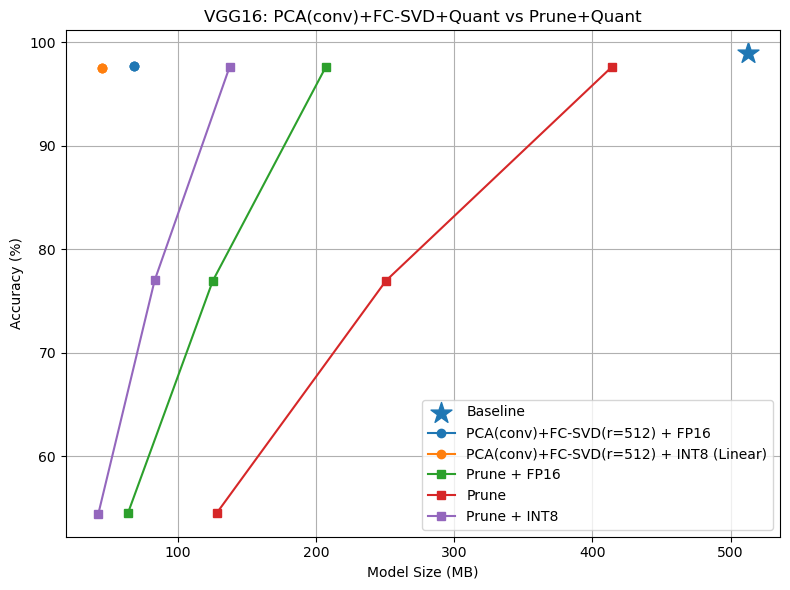

In [26]:
# ==========================================================
# PCA -> QUANT (once) and PRUNE(TP Magnitude) -> QUANT (sweep)
# Re-implemented cleanly + fixes the SUMMARY KeyError you hit.
#
# Assumes you already have in the notebook:
#   - vgg       : your trained VGG16 (2-class head) (or load it)
#   - train_dl  : training DataLoader
#   - val_dl    : validation DataLoader
#   - hybrid_compress_vgg16_projection(...) : optional (your PCA/projection compressor)
#
# pip install torch-pruning
# ==========================================================

import os, copy, time
import torch
import torch.nn as nn
import torch_pruning as tp
from torch.ao.quantization.quantize import quantize_dynamic
import matplotlib.pyplot as plt



# --------------------------
# Helpers
# --------------------------
def model_size_mb_state_dict(model, tmp="tmp_size.pth"):
    torch.save(model.state_dict(), tmp)
    mb = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return mb

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p is not None)

def vgg_conv_out_channels_signature(model, max_layers=13):
    # Works for plain VGG only (Conv2d in .features). If you wrap convs (e.g., ProjConv), update accordingly.
    sig = []
    for m in model.features:
        if isinstance(m, nn.Conv2d):
            sig.append(m.out_channels)
            if len(sig) >= max_layers:
                break
    return tuple(sig)

@torch.inference_mode()
def evaluate(model, dataloader, device):
    model.eval()
    dtype = next(model.parameters()).dtype
    correct = total = 0
    for xb, yb in dataloader:
        xb = xb.to(device, non_blocking=True).to(dtype)
        yb = yb.to(device, non_blocking=True).long()
        preds = model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.numel()
    return 100.0 * correct / max(1, total)

def finetune_steps(model, train_dl, device, steps=200, lr=1e-5, only_classifier=True):
    model.to(device).train()
    crit = nn.CrossEntropyLoss()

    if only_classifier and hasattr(model, "classifier"):
        params = list(model.classifier.parameters())
    else:
        params = list(model.parameters())

    opt = torch.optim.Adam(params, lr=lr)
    it = iter(train_dl)

    last_loss = None
    for _ in range(steps):
        try:
            xb, yb = next(it)
        except StopIteration:
            it = iter(train_dl)
            xb, yb = next(it)

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True).long()

        opt.zero_grad(set_to_none=True)
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        last_loss = loss

    return float(last_loss.item()) if last_loss is not None else float("nan")




# --------------------------
# Main
# --------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Torch-Pruning needs example inputs on SAME device
example_inputs = torch.randn(1, 3, 224, 224, device=device)

ratios = [0.1, 0.3, 0.5]
results = []

# ----------------------------------------------------------
# 0) Baseline once (keep master on CPU to reduce OOM risk)
# ----------------------------------------------------------
vgg_master = copy.deepcopy(vgg).cpu().eval()

baseline = vgg_master.to(device).eval()
base_acc  = evaluate(baseline, val_dl, device)
base_size = model_size_mb_state_dict(baseline)
base_params = count_params(baseline)
base_sig = vgg_conv_out_channels_signature(baseline)

print(f"\nBaseline(VGG): acc={base_acc:.2f}% | size={base_size:.2f} MB")
print("Baseline params:", f"{base_params:,}")
print("Baseline conv_sig:", base_sig)

del baseline
if device == "cuda":
    torch.cuda.empty_cache()

base_row = {"base_acc": base_acc, "base_size": base_size}


# ----------------------------------------------------------
# A) PCA-PROJ -> QUANT 
# ----------------------------------------------------------
print("\n" + "="*75)
print("PCA-PROJ -> QUANT ")
print("="*75)

pca_acc = pca_size = float("nan")
pca_fp16_acc = pca_fp16_size = float("nan")
pca_int8_acc = pca_int8_size = float("nan")
FC_RANK = 512 

m_for_pca = copy.deepcopy(vgg_master).to(device).eval()

vgg_pca=hybrid_compress_vgg16_projection(
    vgg=model_baseline,
    train_dl=train_dl,
    device=device,
    tau=0.95,
    r_min=8,
    cap_frac=0.25,
    skip_first_n_convs=2,
    num_batches=8,
    max_samples=50000,
    verbose=True,
).to(device).eval()

# ---- FC low-rank PCA (THIS WAS MISSING) ----
vgg_pca = replace_vgg16_fc0_with_lowrank(vgg_pca, rank=FC_RANK).to(device).eval()

# Fine-tune after conv compression (recommended)
finetune_epochs(vgg_pca, train_dl, device, epochs=1, lr=1e-5, only_classifier=False)


pca_acc  = evaluate(vgg_pca, val_dl, device)
pca_size = model_size_mb_state_dict(vgg_pca)
print(f"[PCA]       acc={pca_acc:.2f}% | size={pca_size:.2f} MB")
print("PCA params:", f"{count_params(vgg_pca):,}")
print("PCA conv_sig:", vgg_conv_out_channels_signature(vgg_pca))

# FP16 (GPU only)
if device == "cuda":
    vgg_pca_fp16 = copy.deepcopy(vgg_pca).half().to(device).eval()
    pca_fp16_acc  = evaluate(vgg_pca_fp16, val_dl, device)
    pca_fp16_size = model_size_mb_state_dict(vgg_pca_fp16)
    print(f"[PCA+FP16]  acc={pca_fp16_acc:.2f}% | size={pca_fp16_size:.2f} MB")
    del vgg_pca_fp16

# INT8 dynamic quant (CPU, Linear layers)
vgg_pca_int8 = quantize_dynamic(copy.deepcopy(vgg_pca).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
pca_int8_acc  = evaluate(vgg_pca_int8, val_dl, "cpu")
pca_int8_size = model_size_mb_state_dict(vgg_pca_int8)
print(f"[PCA+INT8]  acc={pca_int8_acc:.2f}% | size={pca_int8_size:.2f} MB")

del m_for_pca, vgg_pca, vgg_pca_int8
if device == "cuda":
    torch.cuda.empty_cache()



# ----------------------------------------------------------
# B) PRUNE -> QUANT (iterates over ratios)
# ----------------------------------------------------------
FINAL_FT_STEPS = 80
FINAL_FT_LR = 1e-5


def prune_vgg_tp_magnitude(model, pruning_ratio, example_inputs):
    model.eval()
    pruner = tp.pruner.MagnitudePruner(
        model,
        example_inputs,
        importance=tp.importance.MagnitudeImportance(p=1),
        pruning_ratio=pruning_ratio,
        ignored_layers=[model.classifier[-1]],
    )
    pruner.step()
    return model

print("\n" + "="*75)
print("PRUNE -> QUANT")
print("="*75)

for pruning_ratio in ratios:
    print("\n" + "-"*75)
    print(f"pruning_ratio={pruning_ratio}")
    print("-"*75)

    m_prune = copy.deepcopy(vgg_master).to(device).eval()

    print("Before prune:",
          "params=", f"{count_params(m_prune):,}",
          "conv_sig=", vgg_conv_out_channels_signature(m_prune))

    # ---- PURE pruning timing ----
    if device == "cuda":
        torch.cuda.synchronize()

    m_prune = prune_vgg_tp_magnitude(m_prune, pruning_ratio, example_inputs)

    if device == "cuda":
        torch.cuda.synchronize()
   
    # -----------------------------

    print("After prune:",
          "params=", f"{count_params(m_prune):,}",
          "conv_sig=", vgg_conv_out_channels_signature(m_prune))

    prune_only_acc  = evaluate(m_prune, val_dl, device)
    prune_only_size = model_size_mb_state_dict(m_prune)
    print(f"[PRUNE-ONLY] acc={prune_only_acc:.2f}% | size={prune_only_size:.2f} MB")

   

    # FP16 (GPU only)
    if device == "cuda":
        prune_fp16 = copy.deepcopy(m_prune).half().to(device).eval()
        prune_fp16_acc  = evaluate(prune_fp16, val_dl, device)
        prune_fp16_size = model_size_mb_state_dict(prune_fp16)
        del prune_fp16
    else:
        prune_fp16_acc, prune_fp16_size = float("nan"), float("nan")

    # INT8 dynamic quant (CPU)
    prune_int8 = quantize_dynamic(copy.deepcopy(m_prune).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
    prune_int8_acc  = evaluate(prune_int8, val_dl, "cpu")
    prune_int8_size_sd = model_size_mb_state_dict(prune_int8)

    tmp_mod = "tmp_quant_module.pt"
    torch.save(prune_int8, tmp_mod)
    prune_int8_size_mod = os.path.getsize(tmp_mod) / (1024*1024)
    os.remove(tmp_mod)

    print(f"[PRUNE+FP16] acc={prune_fp16_acc:.2f}% | size(sd)={prune_fp16_size:.2f} MB")
    print(f"[PRUNE+INT8] acc={prune_int8_acc:.2f}% | size(sd)={prune_int8_size_sd:.2f} MB | size(module)={prune_int8_size_mod:.2f} MB")

    # ✅ Store all keys needed for a stable summary
    results.append({
        **base_row,
        "ratio": pruning_ratio,

        "pca_acc": pca_acc, "pca_size": pca_size,
        "pca_fp16_acc": pca_fp16_acc, "pca_fp16_size": pca_fp16_size,
        "pca_int8_acc": pca_int8_acc, "pca_int8_size": pca_int8_size,

        "prune_time_s": t_prune,
        "prune_only_acc": prune_only_acc, "prune_only_size": prune_only_size,
        "prune_acc": prune_acc, "prune_size": prune_size,
        "prune_fp16_acc": prune_fp16_acc, "prune_fp16_size": prune_fp16_size,
        "prune_int8_acc": prune_int8_acc,
        "prune_int8_size_sd": prune_int8_size_sd,
        "prune_int8_size_module": prune_int8_size_mod,

        "shrink_classifier": SHRINK_CLASSIFIER,
        "ft_loss": ft_loss,
    })

    del m_prune, prune_int8
    if device == "cuda":
        torch.cuda.empty_cache()


# ----------------------------------------------------------
# Summary (robust, no KeyError)
# ----------------------------------------------------------
print("\n" + "─"*140)
print("SUMMARY")
print("─"*140)

for r in results:
    print(
        f"ratio={r['ratio']:.1f} | "
        f"BASE {r['base_size']:.2f}MB/{r['base_acc']:.2f}% | "
        f"PCA {r['pca_size']:.2f}MB/{r['pca_acc']:.2f}% | "
        f"PCA-FP16 {r['pca_fp16_size']:.2f}MB/{r['pca_fp16_acc']:.2f}% | "
        f"PCA-INT8 {r['pca_int8_size']:.2f}MB/{r['pca_int8_acc']:.2f}% | "
        f"PRUNE-ONLY {r['prune_only_size']:.2f}MB/{r['prune_only_acc']:.2f}% | "
        f"PRUNE-FP16 {r['prune_fp16_size']:.2f}MB/{r['prune_fp16_acc']:.2f}% | "
        f"PRUNE-INT8(sd) {r['prune_int8_size_sd']:.2f}MB/{r['prune_int8_acc']:.2f}% | "
        f"prune_time={r['prune_time_s']:.3f}s"
    )

print("─"*140)

# -----------------------
# Plot: Accuracy vs Size
# -----------------------
def curve(key_acc, key_size):
    return [x[key_size] for x in results], [x[key_acc] for x in results]

plt.figure(figsize=(8, 6))
plt.scatter(results[0]["base_size"], results[0]["base_acc"], marker="*", s=250, label="Baseline")

# PCA curves (constant across rows, but plotting still works)
sizes, accs = curve("pca_fp16_acc", "pca_fp16_size")
plt.plot(sizes, accs, marker="o", label=f"PCA(conv)+FC-SVD(r={fc_rank}) + FP16")

sizes, accs = curve("pca_int8_acc", "pca_int8_size")
plt.plot(sizes, accs, marker="o", label=f"PCA(conv)+FC-SVD(r={fc_rank}) + INT8 (Linear)")

# Prune curves
sizes, accs = curve("prune_fp16_acc", "prune_fp16_size")
plt.plot(sizes, accs, marker="s", label="Prune + FP16")

sizes, accs = curve("prune_only_acc", "prune_only_size")
plt.plot(sizes, accs, marker="s", label="Prune")

sizes, accs = curve("prune_int8_acc", "prune_int8_size_sd")
plt.plot(sizes, accs, marker="s", label="Prune + INT8")

plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy (%)")
plt.title("VGG16: PCA(conv)+FC-SVD+Quant vs Prune+Quant")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Baseline(RegNet): acc=96.42% | size=15.13 MB

PCA/Projection -> Quant (computed once)

--- PASS 1/2 ---
PROJ-compress grouped: trunk_output.block1.block1-0.f.b.0  k=(3, 3)  Cout 48 -> 42 (r/group=7) -> restore
PROJ-compress grouped: trunk_output.block2.block2-0.f.b.0  k=(3, 3)  Cout 104 -> 78 (r/group=6) -> restore
PROJ-compress grouped: trunk_output.block2.block2-1.f.b.0  k=(3, 3)  Cout 104 -> 78 (r/group=6) -> restore
PROJ-compress grouped: trunk_output.block2.block2-2.f.b.0  k=(3, 3)  Cout 104 -> 91 (r/group=7) -> restore
PROJ-compress grouped: trunk_output.block3.block3-0.f.b.0  k=(3, 3)  Cout 208 -> 156 (r/group=6) -> restore
PROJ-compress grouped: trunk_output.block3.block3-1.f.b.0  k=(3, 3)  Cout 208 -> 156 (r/group=6) -> restore
PROJ-compress grouped: trunk_output.block3.block3-2.f.b.0  k=(3, 3)  Cout 208 -> 182 (r/group=7) -> restore
PROJ-compress grouped: trunk_output.block3.block3-3.f.b.0  k=(3, 3)  Cout 208 -> 156 (r/group=6) -> restore
PROJ-compress grouped: trunk_output.b

/tmp/ipykernel_998909/2196111428.py:128: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  pca_int8 = quantize_dynamic(copy.deepcopy(m_pca).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[PCA+FP16] acc=91.42% | size=4.96 MB
[PCA+INT8] acc=92.06% | size=9.77 MB

PRUNE -> Quant (iterating) | ch_sparsity=0.1


/home/pd25/.local/lib/python3.10/site-packages/torch_pruning/pruner/algorithms/base_pruner.py:91: UserWarning: ch_sparsity is deprecated in v1.3.0. Please use pruning_ratio.
  warnings.warn(


[PRUNE]    acc=91.24% | size=11.93 MB | 1batch_loss=0.1499


/tmp/ipykernel_998909/2196111428.py:177: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prune_int8 = quantize_dynamic(copy.deepcopy(m_prune).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[PRUNE+FP16] acc=90.96% | size=6.03 MB
[PRUNE+INT8] acc=91.08% | size=11.93 MB

PRUNE -> Quant (iterating) | ch_sparsity=0.3
[PRUNE]    acc=57.22% | size=6.71 MB | 1batch_loss=0.7953
[PRUNE+FP16] acc=58.04% | size=3.42 MB
[PRUNE+INT8] acc=57.78% | size=6.70 MB

PRUNE -> Quant (iterating) | ch_sparsity=0.5
[PRUNE]    acc=51.92% | size=3.94 MB | 1batch_loss=0.7848
[PRUNE+FP16] acc=50.74% | size=2.03 MB
[PRUNE+INT8] acc=51.74% | size=3.93 MB

────────────────────────────────────────────────────────────────────────────────────────────────────
SUMMARY
────────────────────────────────────────────────────────────────────────────────────────────────────
sparsity=0.1 | BASE 15.13MB/96.42% | PCA 9.77MB/92.32% -> FP16 4.96MB/91.42% -> INT8 9.77MB/92.06% | PRUNE 11.93MB/91.24% -> FP16 6.03MB/90.96% -> INT8 11.93MB/91.08%
sparsity=0.3 | BASE 15.13MB/96.42% | PCA 9.77MB/92.32% -> FP16 4.96MB/91.42% -> INT8 9.77MB/92.06% | PRUNE 6.71MB/57.22% -> FP16 3.42MB/58.04% -> INT8 6.70MB/57.78%
sparsity=0.5 |

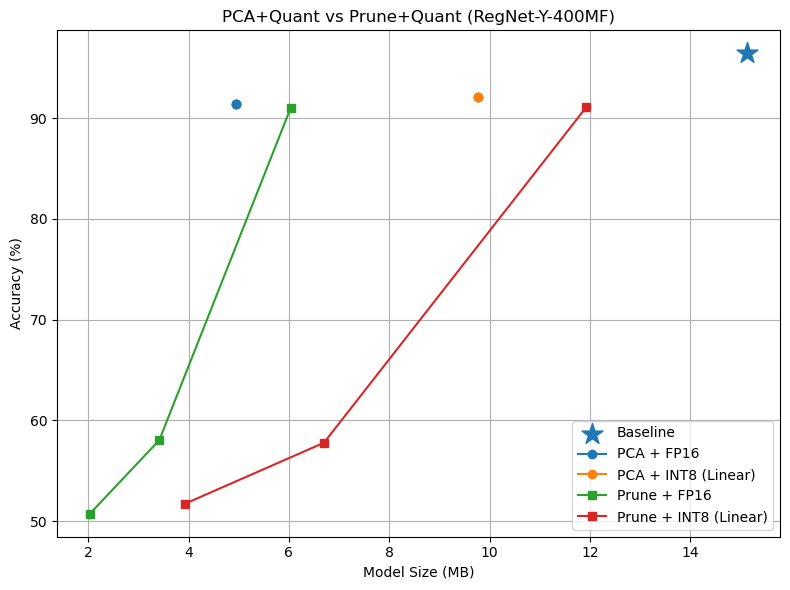

In [8]:
import torch
import torch.nn as nn
import torch_pruning as tp
import copy, os
from torch.ao.quantization.quantize import quantize_dynamic

# -----------------------
# Helpers
# -----------------------
def model_size_mb_state_dict(model):
    tmp = "tmp_size.pth"
    torch.save(model.state_dict(), tmp)
    mb = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return mb

@torch.inference_mode()
def evaluate(model, dataloader, device):
    model.eval()
    dtype = next(model.parameters()).dtype
    correct = total = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.to(dtype)
        preds = model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.numel()
    return 100 * correct / max(1, total)

def quick_finetune_one_batch(model, train_dl, device, lr=1e-5):
    model.to(device)
    model.train()
    criterion = nn.CrossEntropyLoss()
    xb, yb = next(iter(train_dl))
    xb, yb = xb.to(device), yb.to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    opt.zero_grad(set_to_none=True)
    loss = criterion(model(xb), yb)
    loss.backward()
    opt.step()
    return float(loss.item())
def quick_finetune_steps(model, train_dl, device, steps=100, lr=1e-5, only_fc=True):
    model.to(device).train()
    crit = nn.CrossEntropyLoss()

    if only_fc and hasattr(model, "fc"):
        params = list(model.fc.parameters())
    else:
        params = list(model.parameters())

    opt = torch.optim.Adam(params, lr=lr)

    it = iter(train_dl)
    for _ in range(steps):
        try:
            xb, yb = next(it)
        except StopIteration:
            it = iter(train_dl)
            xb, yb = next(it)

        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()

    return float(loss.item())

# -----------------------
# Main: PCA+Quant (once) vs Prune+Quant (loop)
# -----------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
example_inputs = torch.randn(1, 3, 224, 224).to(device)

ratios = [0.1, 0.3, 0.5]
results = []

# ---- baseline ONCE ----
baseline = copy.deepcopy(reg).to(device).eval()
base_acc  = evaluate(baseline, val_dl, device)
base_size = model_size_mb_state_dict(baseline)
print(f"Baseline(RegNet): acc={base_acc:.2f}% | size={base_size:.2f} MB")

# ===================================================
# A) PCA/Projection branch -> Quant (computed ONCE)
# ===================================================
print("\n" + "="*70)
print("PCA/Projection -> Quant (computed once)")
print("="*70)

m_pca = hybrid_compress_regnet(
    model=baseline,     # <-- IMPORTANT: use baseline here
    train_dl=train_dl,
    val_dl=val_dl,
    device=device,
    passes=2,

    # Projection (pca-compress style) on grouped 3x3 only:
    do_projection=True,
    proj_tau=0.98,
    proj_rmin_per_group=6,

    # If you truly want PCA-only, set do_pruning=False
    # If you want your "hybrid" compressor, keep True.
    do_pruning=True,
    prune_tau=0.999,
    prune_min_keep_ratio=0.90,
    prune_max_prune_ratio=0.05,
    prune_rmin_abs=128,

    finetune_steps=50,
    finetune_lr=1e-5,
).to(device).eval()

pca_acc  = evaluate(m_pca, val_dl, device)
pca_size = model_size_mb_state_dict(m_pca)
print(f"[PCA]      acc={pca_acc:.2f}% | size={pca_size:.2f} MB")

# Quantize PCA model ONCE
if device == "cuda":
    pca_fp16 = copy.deepcopy(m_pca).half().to(device).eval()
    pca_fp16_acc  = evaluate(pca_fp16, val_dl, device)
    pca_fp16_size = model_size_mb_state_dict(pca_fp16)
else:
    pca_fp16_acc, pca_fp16_size = float("nan"), float("nan")

pca_int8 = quantize_dynamic(copy.deepcopy(m_pca).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
pca_int8_acc  = evaluate(pca_int8, val_dl, "cpu")
pca_int8_size = model_size_mb_state_dict(pca_int8)

print(f"[PCA+FP16] acc={pca_fp16_acc:.2f}% | size={pca_fp16_size:.2f} MB")
print(f"[PCA+INT8] acc={pca_int8_acc:.2f}% | size={pca_int8_size:.2f} MB")

# ===================================================
# B) Pruning branch -> Quant (ITERATE over sparsity)
# ===================================================
for ch_sparsity in ratios:
    print("\n" + "="*70)
    print(f"PRUNE -> Quant (iterating) | ch_sparsity={ch_sparsity}")
    print("="*70)

    m_prune = copy.deepcopy(baseline).to(device).eval()

    ignored_layers = [m_prune.fc]  # classifier

    pruner = tp.pruner.MagnitudePruner(
    m_prune,
    example_inputs=example_inputs,
    importance=tp.importance.MagnitudeImportance(p=1),
    global_pruning=False,
    ch_sparsity=ch_sparsity,
    iterative_steps=10,              # << WAS 1
    root_module_types=[nn.Conv2d],
    ignored_layers=ignored_layers,
    )
    for _ in range(10):
        pruner.step()
        # small recovery each prune step (very cheap)
        quick_finetune_steps(m_prune, train_dl, device, steps=10, lr=1e-5, only_fc=True)


    loss = quick_finetune_one_batch(m_prune, train_dl, device, lr=1e-5)

    prune_acc  = evaluate(m_prune, val_dl, device)
    prune_size = model_size_mb_state_dict(m_prune)
    print(f"[PRUNE]    acc={prune_acc:.2f}% | size={prune_size:.2f} MB | 1batch_loss={loss:.4f}")

    # Quantize pruned model
    if device == "cuda":
        prune_fp16 = copy.deepcopy(m_prune).half().to(device).eval()
        prune_fp16_acc  = evaluate(prune_fp16, val_dl, device)
        prune_fp16_size = model_size_mb_state_dict(prune_fp16)
    else:
        prune_fp16_acc, prune_fp16_size = float("nan"), float("nan")

    prune_int8 = quantize_dynamic(copy.deepcopy(m_prune).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
    prune_int8_acc  = evaluate(prune_int8, val_dl, "cpu")
    prune_int8_size = model_size_mb_state_dict(prune_int8)

    print(f"[PRUNE+FP16] acc={prune_fp16_acc:.2f}% | size={prune_fp16_size:.2f} MB")
    print(f"[PRUNE+INT8] acc={prune_int8_acc:.2f}% | size={prune_int8_size:.2f} MB")

    results.append({
        "sparsity": ch_sparsity,

        "base_acc": base_acc, "base_size": base_size,

        # PCA branch (constant across rows)
        "pca_acc": pca_acc, "pca_size": pca_size,
        "pca_fp16_acc": pca_fp16_acc, "pca_fp16_size": pca_fp16_size,
        "pca_int8_acc": pca_int8_acc, "pca_int8_size": pca_int8_size,

        # Prune branch (varies by sparsity)
        "prune_acc": prune_acc, "prune_size": prune_size,
        "prune_fp16_acc": prune_fp16_acc, "prune_fp16_size": prune_fp16_size,
        "prune_int8_acc": prune_int8_acc, "prune_int8_size": prune_int8_size,
    })

# -----------------------
# Summary + Plot (unchanged)
# -----------------------
print("\n" + "─"*100)
print("SUMMARY")
print("─"*100)
for r in results:
    print(
        f"sparsity={r['sparsity']:.1f} | "
        f"BASE {r['base_size']:.2f}MB/{r['base_acc']:.2f}% | "
        f"PCA {r['pca_size']:.2f}MB/{r['pca_acc']:.2f}% -> "
        f"FP16 {r['pca_fp16_size']:.2f}MB/{r['pca_fp16_acc']:.2f}% -> "
        f"INT8 {r['pca_int8_size']:.2f}MB/{r['pca_int8_acc']:.2f}% | "
        f"PRUNE {r['prune_size']:.2f}MB/{r['prune_acc']:.2f}% -> "
        f"FP16 {r['prune_fp16_size']:.2f}MB/{r['prune_fp16_acc']:.2f}% -> "
        f"INT8 {r['prune_int8_size']:.2f}MB/{r['prune_int8_acc']:.2f}%"
    )
print("─"*100)

import matplotlib.pyplot as plt

def curve(key_acc, key_size):
    return [r[key_size] for r in results], [r[key_acc] for r in results]

plt.figure(figsize=(8,6))
plt.scatter(results[0]["base_size"], results[0]["base_acc"], marker="*", s=250, label="Baseline")

sizes, accs = curve("pca_fp16_acc", "pca_fp16_size")
plt.plot(sizes, accs, marker="o", label="PCA + FP16")

sizes, accs = curve("pca_int8_acc", "pca_int8_size")
plt.plot(sizes, accs, marker="o", label="PCA + INT8 (Linear)")

sizes, accs = curve("prune_fp16_acc", "prune_fp16_size")
plt.plot(sizes, accs, marker="s", label="Prune + FP16")

sizes, accs = curve("prune_int8_acc", "prune_int8_size")
plt.plot(sizes, accs, marker="s", label="Prune + INT8 (Linear)")

plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy (%)")
plt.title("PCA+Quant vs Prune+Quant (RegNet-Y-400MF)")
plt.grid(True)
plt.legend()
plt.tight_layout()


In [14]:
# ============================================================
# Structured magnitude pruning + tradeoff sweep for VGG16
# using Torch-Pruning (tp.pruner.MagnitudePruner)
#
# Assumes you already have:
#   - train_dl : DataLoader for training
#   - val_dl   : DataLoader for validation
#   - a trained checkpoint: "vgg16_dogs_vs_cats.pth"
#
# Install once:
#   pip install torch-pruning
# ============================================================

import os
import time
import copy
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

import torch_pruning as tp


# -------------------------
# 0) Device
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


# -------------------------
# 1) Helpers
# -------------------------
def evaluate(model: nn.Module, dl, device: str) -> float:
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in dl:
            x = x.to(device)
            y = y.to(device).long()
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return 100.0 * correct / max(1, total)


def finetune(model: nn.Module, train_dl, device: str, epochs: int = 1, lr: float = 1e-5) -> None:
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        running = 0.0
        loop = tqdm(train_dl, desc=f"FT Epoch [{ep+1}/{epochs}]", leave=False)
        for x, y in loop:
            x = x.to(device)
            y = y.to(device).long()

            opt.zero_grad(set_to_none=True)
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()

            running += loss.item()
            loop.set_postfix(loss=float(loss.item()))
        print(f"  fine-tune epoch {ep+1}: avg loss {running / max(1, len(train_dl)):.4f}")


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p is not None)


def model_disk_size_mb_from_state_dict(model: nn.Module, path: str) -> float:
    torch.save(model.state_dict(), path)
    return os.path.getsize(path) / 1e6


@torch.no_grad()
def benchmark_latency_ms(model: nn.Module, device: str, batch_size: int = 32, iters: int = 50, warmup: int = 10) -> float:
    """
    Very simple latency benchmark on random input (forward only).
    Returns avg milliseconds per batch.
    """
    model.eval()
    x = torch.randn(batch_size, 3, 224, 224, device=device)

    # Warmup (esp. important for GPU)
    for _ in range(warmup):
        _ = model(x)
    if device == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(iters):
        _ = model(x)
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    return 1000.0 * (t1 - t0) / iters


def load_trained_vgg16(checkpoint_path: str, device: str) -> nn.Module:
    weights = models.VGG16_Weights.IMAGENET1K_V1
    model = models.vgg16(weights=weights)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)

    sd = torch.load(checkpoint_path, map_location="cpu")
    model.load_state_dict(sd)
    model = model.to(device)
    return model


def prune_with_torch_pruning_magnitude(
    model: nn.Module,
    device: str,
    pruning_ratio: float,
    example_input_shape=(1, 3, 224, 224),
    ignore_last_classifier: bool = True,
) -> nn.Module:
    """
    Structured pruning: removes channels based on magnitude importance.

    pruning_ratio: fraction of channels pruned globally (approx).
    """
    model.eval()

    example_input = torch.randn(*example_input_shape).to(device)

    ignored_layers = []
    if ignore_last_classifier:
        # Keep the final classification layer intact
        ignored_layers.append(model.classifier[-1])

    pruner = tp.pruner.MagnitudePruner(
        model,
        example_input,
        importance=tp.importance.MagnitudeImportance(p=1),  # L1 magnitude
        pruning_ratio=pruning_ratio,
        ignored_layers=ignored_layers,
    )

    # One-shot pruning step
    pruner.step()
    return model


# -------------------------
# 2) Baseline
# -------------------------
ckpt_path = "vgg16_dogs_vs_cats.pth"
assert os.path.exists(ckpt_path), f"Missing checkpoint: {ckpt_path}"

baseline = load_trained_vgg16(ckpt_path, device)
baseline_params = count_params(baseline)
baseline_acc = evaluate(baseline, val_dl, device)
baseline_size_mb = model_disk_size_mb_from_state_dict(baseline, "baseline_state_dict.pth")
baseline_latency = benchmark_latency_ms(baseline, device=device, batch_size=32)

print("\n=== BASELINE ===")
print(f"Params:   {baseline_params/1e6:.2f} M")
print(f"Acc:      {baseline_acc:.2f}%")
print(f"Disk:     {baseline_size_mb:.2f} MB (state_dict)")
print(f"Latency:  {baseline_latency:.2f} ms/batch (random input, bs=32)")


# -------------------------
# 3) Pruning sweep
# -------------------------
# How aggressive do you want to prune channels?
# Try small steps first; VGG can drop sharply at high ratios.
ratios = [0.1, 0.2, 0.3, 0.4, 0.5]

# Fine-tuning settings after pruning (recommended)
do_finetune = False
ft_epochs = 1          # try 1-3
ft_lr = 1e-5

results = []
os.makedirs("prune_runs", exist_ok=True)

for r in ratios:
    print(f"\n=== PRUNE RATIO {r:.2f} ===")

    # fresh copy each time so comparisons are fair
    model = load_trained_vgg16(ckpt_path, device)

    # prune
    model = prune_with_torch_pruning_magnitude(
        model,
        device=device,
        pruning_ratio=r,
        example_input_shape=(1, 3, 224, 224),
        ignore_last_classifier=True,
    )

    # optional fine-tune (strongly recommended)
    if do_finetune:
        print("Fine-tuning after pruning...")
        finetune(model, train_dl, device=device, epochs=ft_epochs, lr=ft_lr)

    # measure
    pruned_params = count_params(model)
    pruned_acc = evaluate(model, val_dl, device)
    pruned_latency = benchmark_latency_ms(model, device=device, batch_size=32)

    out_path = os.path.join("prune_runs", f"vgg16_pruned_ratio_{int(r*100)}.pth")
    pruned_size_mb = model_disk_size_mb_from_state_dict(model, out_path)

    # relative stats
    param_reduction = 100.0 * (1.0 - pruned_params / max(1, baseline_params))
    size_reduction = 100.0 * (1.0 - pruned_size_mb / max(1e-9, baseline_size_mb))
    speedup = baseline_latency / max(1e-9, pruned_latency)

    row = {
        "pruning_ratio": r,
        "val_acc": pruned_acc,
        "params": pruned_params,
        "params_M": pruned_params / 1e6,
        "param_reduction_%": param_reduction,
        "disk_mb": pruned_size_mb,
        "disk_reduction_%": size_reduction,
        "latency_ms_per_batch": pruned_latency,
        "speedup_x": speedup,
        "checkpoint_path": out_path,
    }
    results.append(row)

    print(f"Params:   {row['params_M']:.2f} M   ({row['param_reduction_%']:.1f}% smaller)")
    print(f"Acc:      {row['val_acc']:.2f}%")
    print(f"Disk:     {row['disk_mb']:.2f} MB  ({row['disk_reduction_%']:.1f}% smaller)")
    print(f"Latency:  {row['latency_ms_per_batch']:.2f} ms/batch  (speedup {row['speedup_x']:.2f}×)")
    print(f"Saved:    {row['checkpoint_path']}")


# -------------------------
# 4) Save results to CSV
# -------------------------
csv_path = os.path.join("prune_runs", "tradeoff_results.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(results[0].keys()))
    writer.writeheader()
    writer.writerows(results)

print(f"\nWrote results CSV: {csv_path}")

# Pretty print a compact summary
print("\n=== SUMMARY (higher pruning_ratio => smaller/faster, usually lower acc) ===")
for row in results:
    print(
        f"ratio={row['pruning_ratio']:.2f} | "
        f"acc={row['val_acc']:.2f}% | "
        f"params={row['params_M']:.2f}M (-{row['param_reduction_%']:.1f}%) | "
        f"disk={row['disk_mb']:.2f}MB (-{row['disk_reduction_%']:.1f}%) | "
        f"lat={row['latency_ms_per_batch']:.2f}ms (x{row['speedup_x']:.2f})"
    )


Using device: cuda
GPU name: NVIDIA GeForce RTX 3090

=== BASELINE ===
Params:   134.27 M
Acc:      98.94%
Disk:     537.09 MB (state_dict)
Latency:  42.51 ms/batch (random input, bs=32)

=== PRUNE RATIO 0.10 ===
Params:   108.56 M   (19.1% smaller)
Acc:      97.64%
Disk:     434.26 MB  (19.1% smaller)
Latency:  42.23 ms/batch  (speedup 1.01×)
Saved:    prune_runs/vgg16_pruned_ratio_10.pth

=== PRUNE RATIO 0.20 ===
Params:   85.78 M   (36.1% smaller)
Acc:      88.30%
Disk:     343.14 MB  (36.1% smaller)
Latency:  36.21 ms/batch  (speedup 1.17×)
Saved:    prune_runs/vgg16_pruned_ratio_20.pth

=== PRUNE RATIO 0.30 ===
Params:   65.72 M   (51.1% smaller)
Acc:      76.98%
Disk:     262.88 MB  (51.1% smaller)
Latency:  30.14 ms/batch  (speedup 1.41×)
Saved:    prune_runs/vgg16_pruned_ratio_30.pth

=== PRUNE RATIO 0.40 ===
Params:   48.29 M   (64.0% smaller)
Acc:      67.16%
Disk:     193.18 MB  (64.0% smaller)
Latency:  24.09 ms/batch  (speedup 1.76×)
Saved:    prune_runs/vgg16_pruned_ratio

In [7]:
# =========================
# FLAN-T5-Small 4-bit + LoRA fine-tuning (Dolly 15k, or dataset-agnostic)
# =========================

!pip -q install -U "transformers>=4.40" accelerate peft datasets bitsandbytes sentencepiece evaluate rouge_score

import gc
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType

# -------------------------
# 0) Choose dataset mode
# -------------------------
USE_DOLLY_15K = True

# -------------------------
# 1) Load tokenizer + quantized model
# -------------------------
MODEL_ID = "google/flan-t5-small"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config,
    low_cpu_mem_usage=True,
)

model.config.use_cache = False

print("✅ Model loaded")

# -------------------------
# 2) Attach LoRA adapters
# -------------------------
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["q", "v"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# FIXED: use_reentrant=False required for PEFT/LoRA compatibility
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

# -------------------------
# 3) Load/prepare dataset
# -------------------------
if USE_DOLLY_15K:
    raw = load_dataset("databricks/databricks-dolly-15k")

    def format_dolly(example):
        instruction = example["instruction"]
        context = example["context"]
        response = example["response"]

        if context and str(context).strip():
            input_text = f"Instruction: {instruction}\nContext: {context}\nResponse:"
        else:
            input_text = f"Instruction: {instruction}\nResponse:"

        return {"input_text": input_text, "target_text": response}

    formatted = raw["train"].map(format_dolly)

    split = formatted.train_test_split(test_size=0.05, seed=42)
    train_dataset = split["train"]
    val_dataset = split["test"]

    print(f"✅ Dolly loaded. Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# ELSE: supply train_dataset / val_dataset with input_text/target_text
# train_dataset = ...
# val_dataset   = ...

# -------------------------
# 4) Tokenization
# -------------------------
def tokenize_batch(batch):
    inputs  = [str(x) for x in batch["input_text"]]
    targets = [str(x) for x in batch["target_text"]]

    model_inputs = tokenizer(
        inputs,
        max_length=512,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=256,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=train_dataset.column_names,
)

tokenized_val = val_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=val_dataset.column_names,
)

print("✅ Tokenization complete")

# -------------------------
# 5) Collator + training args
# -------------------------
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

use_fp16 = torch.cuda.is_available()
use_bf16 = False

def build_training_args(use_eval_strategy_name: str):
    kwargs = dict(
        output_dir="./flan_t5_lora_out",
        num_train_epochs=3,
        learning_rate=2e-4,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        warmup_steps=100,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        eval_steps=500,
        save_steps=500,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        predict_with_generate=True,
        generation_max_length=256,
        fp16=use_fp16,
        bf16=use_bf16,
        logging_steps=50,
        report_to="none",
        remove_unused_columns=False,
    )

    if use_eval_strategy_name == "eval_strategy":
        kwargs["eval_strategy"] = "steps"
        kwargs["save_strategy"] = "steps"
    else:
        kwargs["evaluation_strategy"] = "steps"
        kwargs["save_strategy"] = "steps"

    return Seq2SeqTrainingArguments(**kwargs)

try:
    training_args = build_training_args("eval_strategy")
except TypeError:
    training_args = build_training_args("evaluation_strategy")

# -------------------------
# 6) Trainer + train
# -------------------------
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)

try:
    trainer = Seq2SeqTrainer(**trainer_kwargs, processing_class=tokenizer)
except TypeError:
    trainer = Seq2SeqTrainer(**trainer_kwargs)

trainer.train()

# -------------------------
# 7) Save adapter + tokenizer
# -------------------------
model.save_pretrained("./flan_t5_small_lora_adapter")
tokenizer.save_pretrained("./flan_t5_small_lora_adapter")
print("✅ Saved LoRA adapter to ./flan_t5_small_lora_adapter")

# -------------------------
# 8) GPU cleanup
# -------------------------
model.gradient_checkpointing_disable()
model.cpu()
del model
del trainer
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print("✅ GPU cleanup complete — safe to run SVD or next model")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model loaded
trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862
✅ Dolly loaded. Train: 14260 | Val: 751


Map:   0%|          | 0/14260 [00:00<?, ? examples/s]

Map:   0%|          | 0/751 [00:00<?, ? examples/s]

✅ Tokenization complete


Step,Training Loss,Validation Loss
500,0.000000,nan
1000,0.000000,nan
1500,0.000000,nan
2000,0.000000,nan
2500,0.000000,nan


/home/pd25/.local/lib/python3.10/site-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error The read operation timed out - silently ignoring the lookup for the file config.json in google/flan-t5-small.
  warnings.warn(
/home/pd25/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in google/flan-t5-small - will assume that the vocabulary was not modified.
  warnings.warn(


✅ Saved LoRA adapter to ./flan_t5_small_lora_adapter
✅ GPU cleanup complete — safe to run SVD or next model


In [6]:
# =========================
# FLAN-T5-Base 4-bit + LoRA fine-tuning
# =========================

!pip -q install -U "transformers>=4.40" accelerate peft datasets bitsandbytes sentencepiece evaluate rouge_score

import gc
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType

# -------------------------
# 0) Choose dataset mode
# -------------------------
USE_DOLLY_15K = True

# -------------------------
# 1) Load tokenizer + quantized model
# -------------------------
MODEL_ID = "google/flan-t5-base"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config,
    low_cpu_mem_usage=True,
)

model.config.use_cache = False

print("✅ FLAN-T5-Base loaded")

# -------------------------
# 2) Attach LoRA adapters
# -------------------------
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["q", "v"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# FIXED: use_reentrant=False required for PEFT/LoRA compatibility
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

# -------------------------
# 3) Load/prepare dataset
# -------------------------
if USE_DOLLY_15K:
    raw = load_dataset("databricks/databricks-dolly-15k")

    def format_dolly(example):
        instruction = example["instruction"]
        context = example["context"]
        response = example["response"]

        if context and str(context).strip():
            input_text = f"Instruction: {instruction}\nContext: {context}\nResponse:"
        else:
            input_text = f"Instruction: {instruction}\nResponse:"

        return {"input_text": input_text, "target_text": response}

    formatted = raw["train"].map(format_dolly)

    split = formatted.train_test_split(test_size=0.05, seed=42)
    train_dataset = split["train"]
    val_dataset = split["test"]

    print(f"✅ Dolly loaded. Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# -------------------------
# 4) Tokenization
# -------------------------
def tokenize_batch(batch):
    inputs  = [str(x) for x in batch["input_text"]]
    targets = [str(x) for x in batch["target_text"]]

    model_inputs = tokenizer(
        inputs,
        max_length=512,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=256,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=train_dataset.column_names,
)

tokenized_val = val_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=val_dataset.column_names,
)

print("✅ Tokenization complete")

# -------------------------
# 5) Collator + training args
# -------------------------
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

use_fp16 = torch.cuda.is_available()
use_bf16 = False

def build_training_args(use_eval_strategy_name: str):
    kwargs = dict(
        output_dir="./flan_t5_base_lora_out",
        num_train_epochs=3,
        learning_rate=2e-4,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=100,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        eval_steps=500,
        save_steps=500,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        predict_with_generate=True,
        generation_max_length=256,
        fp16=use_fp16,
        bf16=use_bf16,
        logging_steps=50,
        report_to="none",
        remove_unused_columns=False,
    )

    if use_eval_strategy_name == "eval_strategy":
        kwargs["eval_strategy"] = "steps"
        kwargs["save_strategy"] = "steps"
    else:
        kwargs["evaluation_strategy"] = "steps"
        kwargs["save_strategy"] = "steps"

    return Seq2SeqTrainingArguments(**kwargs)

try:
    training_args = build_training_args("eval_strategy")
except TypeError:
    training_args = build_training_args("evaluation_strategy")

# -------------------------
# 6) Trainer + train
# -------------------------
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)

try:
    trainer = Seq2SeqTrainer(**trainer_kwargs, processing_class=tokenizer)
except TypeError:
    trainer = Seq2SeqTrainer(**trainer_kwargs)

trainer.train()

# -------------------------
# 7) Save adapter + tokenizer
# -------------------------
model.save_pretrained("./flan_t5_base_lora_adapter")
tokenizer.save_pretrained("./flan_t5_base_lora_adapter")
print("✅ Saved LoRA adapter to ./flan_t5_base_lora_adapter")

# -------------------------
# 8) GPU cleanup
# -------------------------
model.gradient_checkpointing_disable()
model.cpu()
del model
del trainer
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print("✅ GPU cleanup complete — safe to run SVD or next model")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ FLAN-T5-Base loaded
trainable params: 1,769,472 || all params: 249,347,328 || trainable%: 0.7096
✅ Dolly loaded. Train: 14260 | Val: 751
✅ Tokenization complete


Step,Training Loss,Validation Loss
500,0.000000,nan
1000,0.000000,nan
1500,0.000000,nan
2000,0.000000,nan
2500,0.000000,nan


✅ Saved LoRA adapter to ./flan_t5_base_lora_adapter
✅ GPU cleanup complete — safe to run SVD or next model


In [2]:
import gc
import torch

def full_gpu_cleanup(model):
    model.gradient_checkpointing_disable()
    model.cpu()
    del model
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()  # forces any pending CUDA errors to surface NOW

In [5]:
# =====================================
# BART-Base + LoRA fine-tuning
# Dataset: Dolly 15K (same as FLAN-T5)
# =====================================

!pip -q install -U "transformers>=4.40" accelerate peft datasets bitsandbytes sentencepiece evaluate rouge_score

import gc
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType

# -------------------------
# 0) Dataset mode
# -------------------------
USE_DOLLY_15K = True

# -------------------------
# 1) Load tokenizer + model
# -------------------------
MODEL_ID = "facebook/bart-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, device_map="auto")
model.config.use_cache = False

print("✅ BART-Base loaded")

# -------------------------
# 2) Attach LoRA adapters
# -------------------------
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["q_proj", "v_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# FIXED: use_reentrant=False is required for PEFT/LoRA compatibility
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

# -------------------------
# 3) Load dataset
# -------------------------
if USE_DOLLY_15K:
    raw = load_dataset("databricks/databricks-dolly-15k")

    def format_dolly(example):
        instruction = example["instruction"]
        context = example["context"]
        response = example["response"]
        if context and str(context).strip():
            input_text = f"Instruction: {instruction}\nContext: {context}\nResponse:"
        else:
            input_text = f"Instruction: {instruction}\nResponse:"
        return {"input_text": input_text, "target_text": response}

    formatted = raw["train"].map(format_dolly)
    split = formatted.train_test_split(test_size=0.05, seed=42)
    train_dataset = split["train"]
    val_dataset   = split["test"]

    print(f"✅ Dolly loaded. Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# -------------------------
# 4) Tokenization
# -------------------------
def tokenize_batch(batch):
    inputs  = [str(x) for x in batch["input_text"]]
    targets = [str(x) for x in batch["target_text"]]

    model_inputs = tokenizer(
        inputs,
        max_length=512,
        truncation=True,
        padding=False,
    )
    labels = tokenizer(
        targets,
        max_length=256,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(tokenize_batch, batched=True, remove_columns=train_dataset.column_names)
tokenized_val   = val_dataset.map(tokenize_batch,   batched=True, remove_columns=val_dataset.column_names)

print("✅ Tokenization complete")

# -------------------------
# 5) Collator + training args
# -------------------------
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)
use_fp16 = torch.cuda.is_available()

def build_training_args(use_eval_strategy_name: str):
    kwargs = dict(
        output_dir="./bart_base_lora_out",
        num_train_epochs=3,
        learning_rate=2e-4,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=100,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        eval_steps=500,
        save_steps=500,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        predict_with_generate=True,
        generation_max_length=256,
        fp16=use_fp16,
        logging_steps=50,
        report_to="none",
        remove_unused_columns=False,
    )
    if use_eval_strategy_name == "eval_strategy":
        kwargs["eval_strategy"] = "steps"
        kwargs["save_strategy"] = "steps"
    else:
        kwargs["evaluation_strategy"] = "steps"
        kwargs["save_strategy"] = "steps"

    return Seq2SeqTrainingArguments(**kwargs)

try:
    training_args = build_training_args("eval_strategy")
except TypeError:
    training_args = build_training_args("evaluation_strategy")

# -------------------------
# 6) Trainer + train
# -------------------------
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)
trainer.train()

# -------------------------
# 7) Save adapter + tokenizer
# -------------------------
model.save_pretrained("./bart_base_lora_adapter")
tokenizer.save_pretrained("./bart_base_lora_adapter")
print("✅ Saved LoRA adapter to ./bart_base_lora_adapter")

# -------------------------
# 8) GPU cleanup
# -------------------------
model.gradient_checkpointing_disable()
model.cpu()
del model
del trainer
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print("✅ GPU cleanup complete — safe to run SVD or next model")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

✅ BART-Base loaded
trainable params: 884,736 || all params: 140,305,152 || trainable%: 0.6306
✅ Dolly loaded. Train: 14260 | Val: 751
✅ Tokenization complete


Step,Training Loss,Validation Loss
500,12.546554,2.731625
1000,11.939866,2.678651
1500,11.716383,2.666455
2000,11.814679,2.650903
2500,11.622354,2.649558


✅ Saved LoRA adapter to ./bart_base_lora_adapter
✅ GPU cleanup complete — safe to run SVD or next model


In [21]:
import gc
for name, obj in list(globals().items()):
    try:
        if hasattr(obj, 'config') and hasattr(obj, 'parameters'):
            print(name, type(obj))
    except:
        pass

model <class 'peft.peft_model.PeftModelForSeq2SeqLM'>


In [20]:
# -------------------------
# Load the fine-tuned model for inference
# -------------------------
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
import torch

# Load base model
MODEL_ID = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained("./flan_t5_small_lora_adapter")

# Load base model (can be in 4-bit if you want to save memory)
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16,
)

# Load LoRA adapter on top
model = PeftModel.from_pretrained(base_model, "./flan_t5_small_lora_adapter")
model.eval()

print("✅ Model loaded for inference")

# -------------------------
# Prompting function
# -------------------------
def generate_response(instruction, context="", max_length=256):
    """
    Prompt the model with an instruction (and optional context).
    
    Args:
        instruction: The task/question
        context: Optional additional context
        max_length: Max tokens to generate
    """
    # Format prompt same way as training
    if context and str(context).strip():
        prompt = f"Instruction: {instruction}\nContext: {context}\nResponse:"
    else:
        prompt = f"Instruction: {instruction}\nResponse:"
    
    # Tokenize
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True,
    ).to(model.device)
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=4,           # beam search for better quality
            temperature=0.7,       # control randomness (lower = more deterministic)
            top_p=0.9,            # nucleus sampling
            do_sample=True,       # enable sampling
            early_stopping=True,
        )
    
    # Decode
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response

# -------------------------
# Example usage
# -------------------------

# Simple instruction
response = generate_response(
    instruction="Explain what machine learning is in simple terms"
)
print("Response:", response)

# Instruction with context
response = generate_response(
    instruction="Summarize the main points",
    context="Machine learning is a subset of AI that enables computers to learn from data without being explicitly programmed. It uses algorithms to identify patterns and make predictions."
)
print("Response:", response)

# Question answering
response = generate_response(
    instruction="What is the capital of France?"
)
print("Response:", response)

# Question answering
response = generate_response(
    instruction="Can you calculate 1+1=?"
)
print("Response:", response)

response = generate_response(
    instruction="Can you write me a story?"
)
print("Response:", response)


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model loaded for inference
Response: Machine learning is a process that involves a machine learning process. Machine learning is a process that involves a machine learning process that involves a machine learning process.
Response: Machine learning is a programming language that allows computers to learn from data without being explicitly programmed.
Response: Saint-Étienne
Response: 1
Response: I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I was a student at the University of Chicago. I

Device: cuda

Loading fp32 merged model...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Evaluating baseline...

Baseline — params: 76,961,152 | size: 293.7 MB
           ROUGE-1=16.456  ROUGE-2=7.170  ROUGE-L=15.233

  Collected scales for 144 layers over 16 calibration batches

ASVD rank_ratio = 0.9
  rank_ratio=0.9: replaced=0 | skipped(no scale)=0 | skipped(no saving)=144
  Size   : 293.7 MB → 293.7 MB  (0.0% smaller)
  Params : 76,961,152 → 76,961,152
  ROUGE-1=16.456  ROUGE-2=7.170  ROUGE-L=15.233  ΔRL=+0.000

ASVD rank_ratio = 0.8
  rank_ratio=0.8: replaced=0 | skipped(no scale)=0 | skipped(no saving)=144
  Size   : 293.7 MB → 293.7 MB  (0.0% smaller)
  Params : 76,961,152 → 76,961,152
  ROUGE-1=16.456  ROUGE-2=7.170  ROUGE-L=15.233  ΔRL=+0.000

ASVD rank_ratio = 0.7
  rank_ratio=0.7: replaced=0 | skipped(no scale)=0 | skipped(no saving)=144
  Size   : 293.7 MB → 293.7 MB  (0.0% smaller)
  Params : 76,961,152 → 76,961,152
  ROUGE-1=16.456  ROUGE-2=7.170  ROUGE-L=15.233  ΔRL=+0.000

ASVD rank_ratio = 0.6
  rank_ratio=0.6: replaced=48 | skipped(no scale)=0 | skipped(n

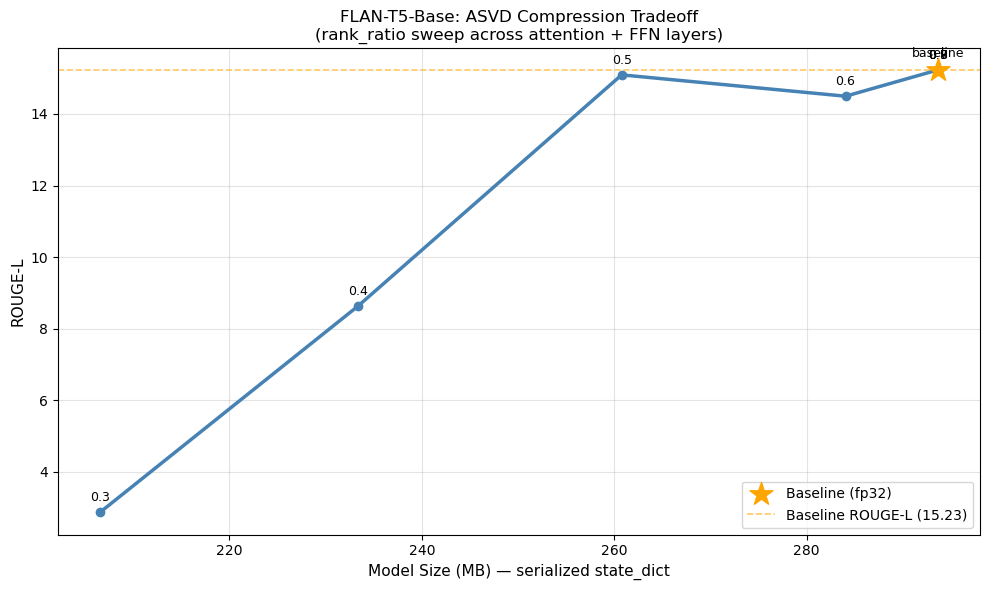

Plot saved to flan_t5_base_asvd_tradeoff.png


In [9]:
# =============================================================================
# FLAN-T5-Base: ASVD Tradeoff Curve (SVD-only)
#
# Assumes already in memory:
#   - MODEL_ID   = "google/flan-t5-base"
#   - tokenizer
#   - val_dataset  (columns: input_text, target_text)
#   - adapter saved at "./flan_t5_base_lora_adapter"
#
# Why ASVD instead of naive SVD:
#   Fine-tuned transformer weights have a flat singular value spectrum
#   (nearly full rank). Naive SVD can't compress them without destroying
#   quality. ASVD scales W by per-channel activation magnitude first, which
#   concentrates spectral energy and makes compression tractable.
# =============================================================================

import copy
import os
import tempfile
import torch
import torch.nn as nn
import evaluate
import nltk
import matplotlib.pyplot as plt
from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel
from nltk.tokenize import sent_tokenize

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
rouge_metric = evaluate.load("rouge")

ADAPTER_PATH  = "./flan_t5_small_lora_adapter"
EVAL_SAMPLES  = 300
CALIB_BATCHES = 16          # number of 8-sample calibration batches
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


# =============================================================================
# Utilities
# =============================================================================

def save_size_mb(model):
    with tempfile.NamedTemporaryFile(delete=False, suffix=".pth") as f:
        torch.save(model.state_dict(), f.name)
        size = os.path.getsize(f.name) / (1024 * 1024)
    os.remove(f.name)
    return size

def param_count(model):
    return sum(p.numel() for p in model.parameters())

def eval_rouge(model, dataset, batch_size=8, max_new_tokens=128, eval_device=None):
    if eval_device is None:
        eval_device = device
    model = model.to(eval_device).eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i + batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(eval_device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds  = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs   = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge_metric.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: round(v * 100, 3) for k, v in scores.items()}

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

def load_merged_fp32():
    base   = AutoModelForSeq2SeqLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float32, device_map="cpu"
    )
    merged = PeftModel.from_pretrained(base, ADAPTER_PATH).merge_and_unload()
    return merged.cpu().eval()


# =============================================================================
# Step 1: Load & evaluate baseline ONCE
# =============================================================================

print("\nLoading fp32 merged model...")
merged = load_merged_fp32()

sample = val_dataset.select(range(min(EVAL_SAMPLES, len(val_dataset))))
calib  = val_dataset.select(range(min(CALIB_BATCHES * 8, len(val_dataset))))

print("Evaluating baseline...")
base_scores = eval_rouge(merged, sample, eval_device=device)
base_size   = save_size_mb(merged)
base_params = param_count(merged)
base_rougeL = base_scores["rougeL"]

print(f"\nBaseline — params: {base_params:,} | size: {base_size:.1f} MB")
print(f"           ROUGE-1={base_scores['rouge1']:.3f}  "
      f"ROUGE-2={base_scores['rouge2']:.3f}  "
      f"ROUGE-L={base_rougeL:.3f}")


# =============================================================================
# Step 2: Collect per-layer activation scales from calibration data
#
# For each target Linear layer, we record the RMS activation magnitude
# per input channel over CALIB_BATCHES forward passes.
# This tells us which input channels actually matter — channels with large
# activations carry more information regardless of weight magnitude.
# =============================================================================

TARGET_MODULES = ["q", "k", "v", "o", "wi_0", "wi_1", "wo"]

def collect_activation_scales(model, calib_dataset, target_modules,
                               num_batches=16, calib_device=None):
    if calib_device is None:
        calib_device = device

    model = model.to(calib_device).eval()
    scales = {}
    counts = {}
    hooks  = {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()              # [B, T, in_features]
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms
                counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            if any(name.endswith("." + t) for t in target_modules):
                hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset):
                break
            batch  = calib_dataset[start:start + 8]
            inputs = tokenizer(
                batch["input_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=256
            ).to(calib_device)
            labels = tokenizer(
                batch["target_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=128
            ).input_ids.to(calib_device)
            try:
                model(**inputs, labels=labels)
            except Exception:
                pass

    for h in hooks.values():
        h.remove()

    print(f"  Collected scales for {len(scales)} layers "
          f"over {num_batches} calibration batches")
    return scales


print("\nCollecting activation scales...")
scales = collect_activation_scales(merged, calib, TARGET_MODULES,
                                   num_batches=CALIB_BATCHES, calib_device=device)


# =============================================================================
# Step 3: ASVDLinear — activation-aware low-rank factorization
#
# Instead of SVD(W), we compute SVD(W * diag(s)) where s is the calibration
# scale. This concentrates spectral energy into fewer singular values so we
# can drop more of them without losing quality.
#
# The sqrt split puts sqrt(S) into both factors so neither A nor B has
# disproportionately large weights (avoids numerical issues).
#
# We undo the input scaling in B so that forward(x) = A @ B @ x = W @ x.
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)

            # Scale columns by activation magnitude
            W_scaled = W * s.unsqueeze(0)              # [out, in]

            U, S, Vh = torch.linalg.svd(W_scaled, full_matrices=False)
            r = min(rank, S.numel())

            # sqrt split: both factors at similar numerical scale
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r]  * S_sqrt.unsqueeze(0)     # [out, r]
            B_w = S_sqrt.unsqueeze(1) * Vh[:r, :]     # [r, in]

            # Undo input scaling so A @ B @ x reconstructs W @ x
            B_w = B_w / s.unsqueeze(0)

        self.B = nn.Linear(in_f,  rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.register_buffer(
            "_weight_dtype_proxy", torch.empty((), dtype=original.weight.dtype)
        )

    @property
    def weight(self): return self._weight_dtype_proxy

    @property
    def bias(self): return self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def apply_asvd(source_model, scales, target_modules, rank_ratio):
    """
    Replace each target Linear with ASVDLinear at the given rank_ratio.
    rank = int(min(out, in) * rank_ratio), skipped if no param saving.
    """
    compressed = copy.deepcopy(source_model)
    replaced = skipped_no_scale = skipped_no_saving = 0

    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear):
            continue
        if not any(name.endswith("." + t) for t in target_modules):
            continue
        if name not in scales:
            skipped_no_scale += 1
            continue

        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))

        # Only replace if we actually save parameters
        if rank * (in_f + out_f) >= out_f * in_f:
            skipped_no_saving += 1
            continue

        scale = scales[name].cpu()
        recursive_setattr(compressed, name, ASVDLinear(module, rank, scale))
        replaced += 1

    print(f"  rank_ratio={rank_ratio}: replaced={replaced} | "
          f"skipped(no scale)={skipped_no_scale} | "
          f"skipped(no saving)={skipped_no_saving}")
    return compressed


# =============================================================================
# Step 4: Sweep rank ratios to build the tradeoff curve
#
# rank_ratio=0.9 → very conservative, tiny size drop, near-zero ROUGE loss
# rank_ratio=0.5 → moderate compression
# rank_ratio=0.3 → aggressive, noticeable quality cost
#
# FLAN-T5-Base has 768-dim attention and 2048-dim FFN.
# FFN layers dominate params and have more redundancy after ASVD scaling.
# =============================================================================

RANK_RATIOS = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]

sweep_results = []

for rr in RANK_RATIOS:
    print(f"\n{'='*60}")
    print(f"ASVD rank_ratio = {rr}")
    print(f"{'='*60}")

    compressed   = apply_asvd(merged, scales, TARGET_MODULES, rank_ratio=rr)
    comp_size    = save_size_mb(compressed)
    comp_params  = param_count(compressed)
    comp_scores  = eval_rouge(compressed, sample, eval_device=device)
    delta_rL     = comp_scores["rougeL"] - base_rougeL

    size_reduction = 100 * (1 - comp_size / base_size)

    print(f"  Size   : {base_size:.1f} MB → {comp_size:.1f} MB  "
          f"({size_reduction:.1f}% smaller)")
    print(f"  Params : {base_params:,} → {comp_params:,}")
    print(f"  ROUGE-1={comp_scores['rouge1']:.3f}  "
          f"ROUGE-2={comp_scores['rouge2']:.3f}  "
          f"ROUGE-L={comp_scores['rougeL']:.3f}  "
          f"ΔRL={delta_rL:+.3f}")

    sweep_results.append({
        "rank_ratio"  : rr,
        "size_mb"     : comp_size,
        "params"      : comp_params,
        "rouge1"      : comp_scores["rouge1"],
        "rouge2"      : comp_scores["rouge2"],
        "rougeL"      : comp_scores["rougeL"],
        "delta_rL"    : delta_rL,
    })

    del compressed
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# =============================================================================
# Step 5: Results table
# =============================================================================

print("\n" + "="*80)
print(f"{'rank_ratio':>12} {'size_MB':>9} {'Δsize%':>7} "
      f"{'ROUGE-1':>9} {'ROUGE-2':>9} {'ROUGE-L':>9} {'Δ ROUGE-L':>10}")
print("="*80)

# Baseline row
print(f"{'baseline':>12} {base_size:>9.1f} {'—':>7} "
      f"{base_scores['rouge1']:>9.3f} {base_scores['rouge2']:>9.3f} "
      f"{base_rougeL:>9.3f} {'—':>10}")

for r in sweep_results:
    pct = 100 * (1 - r["size_mb"] / base_size)
    print(f"{r['rank_ratio']:>12.2f} {r['size_mb']:>9.1f} {pct:>6.1f}% "
          f"{r['rouge1']:>9.3f} {r['rouge2']:>9.3f} "
          f"{r['rougeL']:>9.3f} {r['delta_rL']:>+10.3f}")

print("="*80)


# =============================================================================
# Step 6: Tradeoff plot
# =============================================================================

all_sizes  = [base_size]  + [r["size_mb"]  for r in sweep_results]
all_rouges = [base_rougeL] + [r["rougeL"]  for r in sweep_results]
all_labels = ["baseline"]  + [str(r["rank_ratio"]) for r in sweep_results]

# Sort by model size for a clean left-to-right curve
order     = sorted(range(len(all_sizes)), key=lambda i: all_sizes[i])
all_sizes  = [all_sizes[i]  for i in order]
all_rouges = [all_rouges[i] for i in order]
all_labels = [all_labels[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 6))

# Main tradeoff curve
ax.plot(all_sizes, all_rouges,
        marker="o", linewidth=2.5, color="steelblue", zorder=3)

# Highlight baseline
ax.scatter([base_size], [base_rougeL],
           marker="*", s=300, color="orange", zorder=5, label="Baseline (fp32)")

# Annotate each point
for x, y, lbl in zip(all_sizes, all_rouges, all_labels):
    offset = (0, 9) if lbl == "baseline" else (0, 8)
    ax.annotate(lbl, (x, y),
                textcoords="offset points", xytext=offset,
                ha="center", fontsize=9)

# Horizontal dashed reference at baseline ROUGE-L
ax.axhline(base_rougeL, color="orange", linestyle="--",
           linewidth=1.2, alpha=0.6, label=f"Baseline ROUGE-L ({base_rougeL:.2f})")

ax.set_xlabel("Model Size (MB) — serialized state_dict", fontsize=11)
ax.set_ylabel("ROUGE-L", fontsize=11)
ax.set_title(
    "FLAN-T5-Base: ASVD Compression Tradeoff\n"
    "(rank_ratio sweep across attention + FFN layers)",
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("flan_t5_base_asvd_tradeoff.png", dpi=150)
plt.show()
print("Plot saved to flan_t5_base_asvd_tradeoff.png")

In [17]:
# =============================================================================
# Quantization — run after your training script
# Assumes: MODEL_ID, tokenizer, val_dataset already in memory
# Tests 8-bit and 4-bit quantization vs the merged fp32 baseline
# =============================================================================

import os, torch, evaluate, nltk
from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig
from peft import PeftModel

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize

rouge = evaluate.load("rouge")

# ── 1. Helper: ROUGE eval ─────────────────────────────────────────────────────
def eval_rouge(model, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device  # infer from model, not assumption
    model.eval()
    predictions, references = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i : i + batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512,
        ).to(device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        predictions.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
        references.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in predictions]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in references]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: round(v * 100, 3) for k, v in scores.items()}

def model_size_mb(model):
    """Estimate in-memory size of model parameters in MB."""
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

EVAL_SAMPLES = 300
sample = val_dataset.select(range(min(EVAL_SAMPLES, len(val_dataset))))

results = []

# ── 2. Baseline: fp32 merged model ───────────────────────────────────────────
print("Loading fp32 baseline...")
base_fp32 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map="cpu")
model_fp32 = PeftModel.from_pretrained(base_fp32, "./flan_t5_small_lora_adapter").merge_and_unload()
model_fp32.eval()

print("📊 Evaluating fp32 baseline...")
scores = eval_rouge(model_fp32, sample)
scores["name"] = "fp32 (baseline)"
scores["size_mb"] = model_size_mb(model_fp32)
results.append(scores)
print(f"  Done. Size: {scores['size_mb']:.1f} MB | ROUGE-L: {scores['rougeL']}")

del model_fp32  # free memory before loading next
torch.cuda.empty_cache()

# ── 3. 8-bit quantization ─────────────────────────────────────────────────────
print("\nLoading 8-bit model...")
bnb_8bit = BitsAndBytesConfig(load_in_8bit=True)
base_8bit = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_8bit,
    device_map="auto",
)
model_8bit = PeftModel.from_pretrained(base_8bit, "./flan_t5_small_lora_adapter").merge_and_unload()
model_8bit.eval()

print("📊 Evaluating 8-bit model...")
scores = eval_rouge(model_8bit, sample)
scores["name"] = "int8 (8-bit)"
scores["size_mb"] = model_size_mb(model_8bit)
results.append(scores)
print(f"  Done. Size: {scores['size_mb']:.1f} MB | ROUGE-L: {scores['rougeL']}")

del model_8bit
torch.cuda.empty_cache()

# ── 4. 4-bit quantization ─────────────────────────────────────────────────────
print("\nLoading 4-bit model...")
bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",              # nf4 is best for LLMs
    bnb_4bit_compute_dtype=torch.float16,   # compute in fp16 for speed
)
base_4bit = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_4bit,
    device_map="auto",
)
model_4bit = PeftModel.from_pretrained(base_4bit, "./flan_t5_small_lora_adapter").merge_and_unload()
model_4bit.eval()

print("📊 Evaluating 4-bit model...")
scores = eval_rouge(model_4bit, sample)
scores["name"] = "nf4 (4-bit)"
scores["size_mb"] = model_size_mb(model_4bit)
results.append(scores)
print(f"  Done. Size: {scores['size_mb']:.1f} MB | ROUGE-L: {scores['rougeL']}")

# ── 5. Results table ──────────────────────────────────────────────────────────
baseline_rouge = results[0]["rougeL"]
baseline_size  = results[0]["size_mb"]

print("\n" + "="*70)
print(f"{'':20} {'Size MB':>9} {'Reduction':>10} {'ROUGE-1':>8} {'ROUGE-2':>8} {'ROUGE-L':>8} {'Δ R-L':>7}")
print("="*70)
for r in results:
    size_reduction = f"{100 * (1 - r['size_mb'] / baseline_size):.1f}%" if r["name"] != results[0]["name"] else "—"
    delta = f"{r['rougeL'] - baseline_rouge:+.3f}"              if r["name"] != results[0]["name"] else "—"
    print(f"{r['name']:20} {r['size_mb']:>9.1f} {size_reduction:>10} {r['rouge1']:>8.3f} {r['rouge2']:>8.3f} {r['rougeL']:>8.3f} {delta:>7}")
print("="*70)

Loading fp32 baseline...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


📊 Evaluating fp32 baseline...
  Done. Size: 293.6 MB | ROUGE-L: 15.233

Loading 8-bit model...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/home/pd25/.local/lib/python3.10/site-packages/peft/tuners/lora/bnb.py:110: UserWarning: Merge lora module to 8-bit linear may get different generations due to rounding errors.
  warnings.warn(
/home/pd25/.local/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


📊 Evaluating 8-bit model...
  Done. Size: 191.6 MB | ROUGE-L: 15.519

Loading 4-bit model...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/home/pd25/.local/lib/python3.10/site-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


📊 Evaluating 4-bit model...
  Done. Size: 174.6 MB | ROUGE-L: 15.088

                       Size MB  Reduction  ROUGE-1  ROUGE-2  ROUGE-L   Δ R-L
fp32 (baseline)          293.6          —   16.456    7.170   15.233       —
int8 (8-bit)             191.6      34.7%   17.017    7.638   15.519  +0.286
nf4 (4-bit)              174.6      40.5%   16.374    7.265   15.088  -0.145


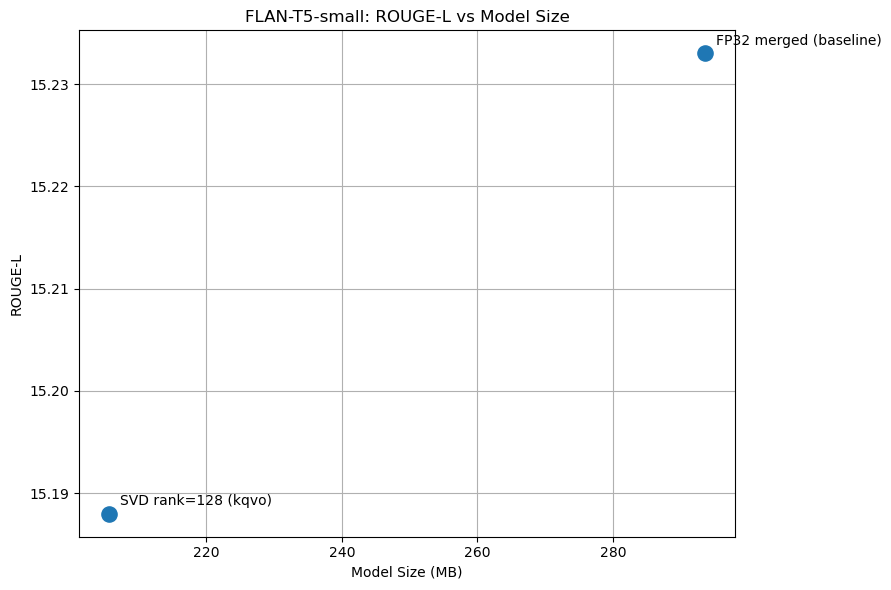

In [17]:
import matplotlib.pyplot as plt

def plot_llm_perf_vs_size(points, title="ROUGE vs Model Size"):
    """
    points: list of dicts, each like:
      {"name": "fp32 baseline", "size_mb": 293.6, "rougeL": 15.233}
    """
    xs = [p["size_mb"] for p in points]
    ys = [p["rougeL"]  for p in points]
    labels = [p["name"] for p in points]

    plt.figure(figsize=(9, 6))
    plt.scatter(xs, ys, s=120)

    # annotate points
    for x, y, lab in zip(xs, ys, labels):
        plt.annotate(lab, (x, y), textcoords="offset points", xytext=(8, 6))

    plt.xlabel("Model Size (MB)")
    plt.ylabel("ROUGE-L")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example using your printed numbers:
points = [
    {"name": "FP32 merged (baseline)", "size_mb": 293.6, "rougeL": 15.233},
    {"name": "SVD rank=128 (kqvo)",    "size_mb": 205.6, "rougeL": 15.188},
    # add quant points when you have them:
    # {"name": "INT8 (bnb)", "size_mb": ..., "rougeL": ...},
    # {"name": "NF4 (4-bit)", "size_mb": ..., "rougeL": ...},
]
plot_llm_perf_vs_size(points, title="FLAN-T5-small: ROUGE-L vs Model Size")

In [9]:
import copy
import math
from dataclasses import dataclass, field
from collections import defaultdict

import torch
import torch.nn as nn
from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel


# ============================================================
# 1) Merge LoRA into fp32 base model
# ============================================================

base_for_svd = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    device_map="cpu",
)

merged_model = PeftModel.from_pretrained(base_for_svd, "./flan_t5_small_lora_adapter")
merged_model = merged_model.merge_and_unload()
merged_model.eval()

print("✅ LoRA merged into fp32 model for SVD")


# ============================================================
# 2) Low-rank module
# ============================================================

class LowRankLinear(nn.Module):
    """
    Factorizes a Linear(out, in) as:
        x -> B(in->r) -> A(r->out)
    such that W ≈ A @ B
    """
    def __init__(self, original: nn.Linear, rank: int, use_sqrt_split: bool = True):
        super().__init__()
        assert isinstance(original, nn.Linear)

        out_features, in_features = original.weight.shape
        max_rank = min(out_features, in_features)
        rank = min(rank, max_rank)

        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank

        self.B = nn.Linear(in_features, rank, bias=False)
        self.A = nn.Linear(rank, out_features, bias=(original.bias is not None))

        with torch.no_grad():
            W = original.weight.detach().float()
            U, S, Vh = torch.linalg.svd(W, full_matrices=False)

            U = U[:, :rank]      # [out, r]
            S = S[:rank]         # [r]
            Vh = Vh[:rank, :]    # [r, in]

            if use_sqrt_split:
                # Better conditioning than putting all S into A
                sqrtS = torch.sqrt(S)
                A = U * sqrtS.unsqueeze(0)            # [out, r]
                B = sqrtS.unsqueeze(1) * Vh           # [r, in]
            else:
                A = U * S.unsqueeze(0)                # [out, r]
                B = Vh                                # [r, in]

            self.A.weight.copy_(A.to(self.A.weight.dtype))
            self.B.weight.copy_(B.to(self.B.weight.dtype))

            if original.bias is not None:
                self.A.bias.copy_(original.bias.detach().to(self.A.bias.dtype))

        # Tiny proxy so code that checks `.weight.dtype` doesn't break
        self.register_buffer("_weight_dtype_proxy", torch.empty((), dtype=original.weight.dtype))

    @property
    def weight(self):
        return self._weight_dtype_proxy

    @property
    def bias(self):
        return self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


# ============================================================
# 3) Config
# ============================================================

@dataclass
class CompressionConfig:
    # Which groups to compress
    compress_attention: bool = True
    compress_ffn: bool = True

    # Per-group ranks
    attention_rank: int = 192
    ffn_rank: int = 256

    # Exact suffix names to match
    attention_modules: tuple = ("q", "k", "v", "o")
    ffn_modules: tuple = ("wi", "wi_0", "wi_1", "wo")

    # Optional filters
    encoder_only: bool = False
    decoder_only: bool = False

    # SVD init style
    use_sqrt_split: bool = True


# ============================================================
# 4) Helpers
# ============================================================

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)


def module_group_from_name(name: str, config: CompressionConfig):
    """
    Return ('attention', rank) or ('ffn', rank) or (None, None)
    """
    suffix = name.split(".")[-1]

    if config.encoder_only and not name.startswith("encoder."):
        return None, None
    if config.decoder_only and not name.startswith("decoder."):
        return None, None

    if config.compress_attention and suffix in config.attention_modules:
        return "attention", config.attention_rank

    if config.compress_ffn and suffix in config.ffn_modules:
        return "ffn", config.ffn_rank

    return None, None


def break_even_rank(out_features: int, in_features: int):
    # rank must be strictly below this to save params
    return (out_features * in_features) / (out_features + in_features)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def print_linear_modules(model):
    print("\n=== Linear layers in model ===")
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            print(f"{name:80s} {tuple(module.weight.shape)}")


# ============================================================
# 5) Build compressed model
# ============================================================

def build_compressed_model(source_model: nn.Module, config: CompressionConfig):
    compressed = copy.deepcopy(source_model)

    stats = defaultdict(int)
    saved_params = 0

    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear):
            continue

        group, rank = module_group_from_name(name, config)
        if group is None:
            continue

        out_features, in_features = module.weight.shape
        original_params = out_features * in_features + (out_features if module.bias is not None else 0)
        low_rank_params = rank * in_features + out_features * rank + (out_features if module.bias is not None else 0)
        delta = original_params - low_rank_params

        recursive_setattr(
            compressed,
            name,
            LowRankLinear(module, rank=rank, use_sqrt_split=config.use_sqrt_split)
        )

        stats["replaced_total"] += 1
        stats[f"replaced_{group}"] += 1
        stats[f"orig_params_{group}"] += original_params
        stats[f"lr_params_{group}"] += low_rank_params
        saved_params += delta

        print(
            f"[{group:9s}] {name:80s} "
            f"{tuple(module.weight.shape)}  rank={rank:<4d}  "
            f"break_even={break_even_rank(out_features, in_features):.1f}  "
            f"delta={delta:+d}"
        )

    print("\n=== Compression summary ===")
    print(f"Replaced total     : {stats['replaced_total']}")
    print(f"Replaced attention : {stats['replaced_attention']}")
    print(f"Replaced ffn       : {stats['replaced_ffn']}")
    print(f"Estimated params saved in replaced layers: {saved_params:,}")

    return compressed


# ============================================================
# 6) Example configs
# ============================================================

# Safer starting point:
# - modest attention compression
# - moderate FFN compression
config = CompressionConfig(
    compress_attention=True,
    compress_ffn=True,
    attention_rank=192,
    ffn_rank=256,
    attention_modules=("q", "k", "v"),
    ffn_modules=("wi", "wi_0", "wi_1"),
)

compressed_model = build_compressed_model(merged_model, config)
compressed_model.eval()

print("✅ Compression complete")


# ============================================================
# 7) Compare params
# ============================================================

orig_params = count_parameters(merged_model)
comp_params = count_parameters(compressed_model)

print(f"\nOriginal params   : {orig_params:,}")
print(f"Compressed params : {comp_params:,}")
print(f"Reduction         : {100 * (1 - comp_params / orig_params):.2f}%")

# ============================================================
# 8) ROUGE evaluation
# Assumes: tokenizer and val_dataset already exist
# val_dataset columns: "input_text", "target_text"
# ============================================================

import evaluate
import nltk
import numpy as np
import torch
from nltk.tokenize import sent_tokenize

nltk.download("punkt", quiet=True)
rouge = evaluate.load("rouge")

def eval_rouge(model, dataset, tokenizer, batch_size=8, max_new_tokens=128,
               num_beams=2,
               device="cuda" if torch.cuda.is_available() else "cpu"):
    model = model.to(device)
    model.eval()

    predictions = []
    references = []

    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i + batch_size]

        inputs = tokenizer(
            batch["input_text"],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
            )

        preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        refs = batch["target_text"]

        preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
        refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]

        predictions.extend(preds)
        references.extend(refs)

    scores = rouge.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True
    )

    return {k: round(v * 100, 3) for k, v in scores.items()}


# Small eval slice first
EVAL_SAMPLES = 300
sample = val_dataset.select(range(min(EVAL_SAMPLES, len(val_dataset))))

print("\n📊 Evaluating original merged model...")
orig_scores = eval_rouge(merged_model, sample, tokenizer)

print("📊 Evaluating compressed FFN/attention model...")
comp_scores = eval_rouge(compressed_model, sample, tokenizer)

print("\n" + "=" * 60)
print(f"{'':20} {'ROUGE-1':>8} {'ROUGE-2':>8} {'ROUGE-L':>8} {'ROUGE-Lsum':>11}")
print("=" * 60)
print(f"{'Original':20} {orig_scores['rouge1']:>8.3f} {orig_scores['rouge2']:>8.3f} {orig_scores['rougeL']:>8.3f} {orig_scores['rougeLsum']:>11.3f}")
print(f"{'Compressed':20} {comp_scores['rouge1']:>8.3f} {comp_scores['rouge2']:>8.3f} {comp_scores['rougeL']:>8.3f} {comp_scores['rougeLsum']:>11.3f}")
print(f"{'Delta':20} "
      f"{comp_scores['rouge1'] - orig_scores['rouge1']:>+8.3f} "
      f"{comp_scores['rouge2'] - orig_scores['rouge2']:>+8.3f} "
      f"{comp_scores['rougeL'] - orig_scores['rougeL']:>+8.3f} "
      f"{comp_scores['rougeLsum'] - orig_scores['rougeLsum']:>+11.3f}")
print("=" * 60)

print(f"\nROUGE-L delta: {comp_scores['rougeL'] - orig_scores['rougeL']:+.3f}")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ LoRA merged into fp32 model for SVD
[attention] encoder.block.0.layer.0.SelfAttention.q                                          (384, 512)  rank=192   break_even=219.4  delta=+24576
[attention] encoder.block.0.layer.0.SelfAttention.k                                          (384, 512)  rank=192   break_even=219.4  delta=+24576
[attention] encoder.block.0.layer.0.SelfAttention.v                                          (384, 512)  rank=192   break_even=219.4  delta=+24576
[ffn      ] encoder.block.0.layer.1.DenseReluDense.wi_0                                      (1024, 512)  rank=256   break_even=341.3  delta=+131072
[ffn      ] encoder.block.0.layer.1.DenseReluDense.wi_1                                      (1024, 512)  rank=256   break_even=341.3  delta=+131072
[attention] encoder.block.1.layer.0.SelfAttention.q                                          (384, 512)  rank=192   break_even=219.4  delta=+24576
[attention] encoder.block.1.layer.0.SelfAttention.k                         

`torch_dtype` is deprecated! Use `dtype` instead!


Loading fp32 merged baseline...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE fp32]     size=293.6MB | ROUGE-L=15.233

Applying dynamic INT8 to baseline...


...

  amt=0.4 | size=172.4MB | ROUGE-L=7.763


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  amt=0.5 | size=167.6MB | ROUGE-L=4.368


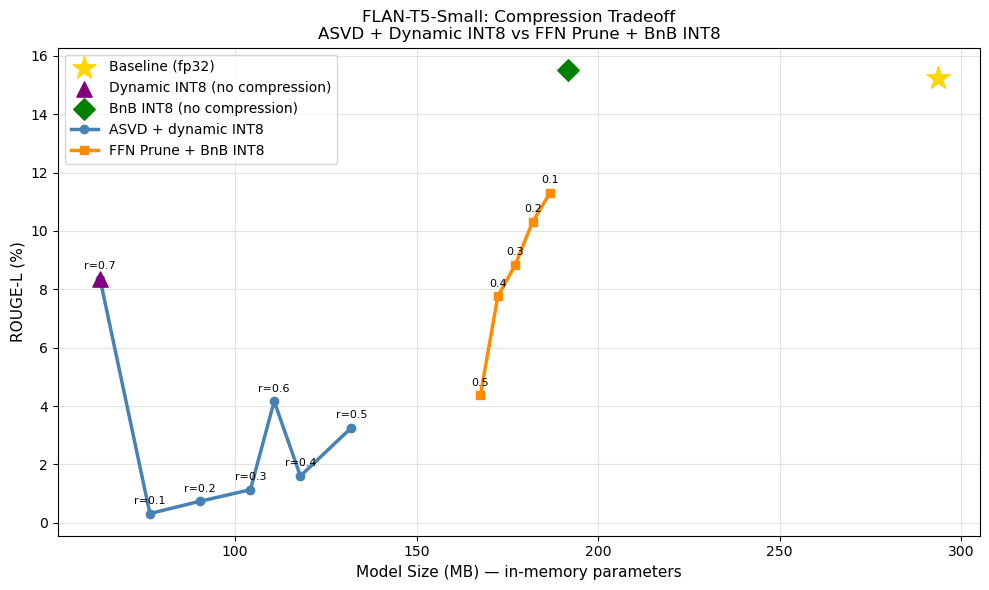

Saved: flan_t5_tradeoff.png


In [3]:
import os, copy, tempfile, shutil
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig
from peft import PeftModel
from torch.ao.quantization.quantize import quantize_dynamic

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def load_bnb_8bit(path):
    model = AutoModelForSeq2SeqLM.from_pretrained(
        path,
        quantization_config=BitsAndBytesConfig(load_in_8bit=True),
        device_map="auto",
    )
    return model.eval()

def apply_dynamic_int8(model):
    """quantize_dynamic walks the module tree and quantizes any nn.Linear in-place.
    Works on custom modules like ASVDLinear because it doesn't need HF save/reload."""
    return quantize_dynamic(
        copy.deepcopy(model).cpu().eval(),
        {nn.Linear},
        dtype=torch.qint8
    )

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Main runner
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples   = 300,
    rank_ratios    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts  = (0.1, 0.2, 0.3, 0.4, 0.5),
    target_modules = ("q", "k", "v", "o", "wi_0", "wi_1", "wo"),
    calib_batches  = 16,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    # ── 1. Baseline fp32 ────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE fp32]     size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    # ── 2. Dynamic INT8 baseline (no compression, just quant) ───────────────
    print("\nApplying dynamic INT8 to baseline...")
    base_int8       = apply_dynamic_int8(baseline)
    base_int8_size  = model_size_mb(base_int8)
    base_int8_scores = eval_rouge(base_int8, tokenizer, sample, device="cpu")
    print(f"[BASE INT8]     size={base_int8_size:.1f}MB | ROUGE-L={base_int8_scores['rougeL']*100:.3f}")
    del base_int8
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 3. BnB INT8 reference (for prune curve) ─────────────────────────────
    print("\nLoading BnB INT8 reference...")
    tmp_base = "./tmp_base_merged"
    baseline.cpu().save_pretrained(tmp_base)
    tokenizer.save_pretrained(tmp_base)
    baseline.to(device)
    bnb_ref      = load_bnb_8bit(tmp_base)
    bnb_scores   = eval_rouge(bnb_ref, tokenizer, sample)
    bnb_size     = model_size_mb(bnb_ref)
    print(f"[BnB INT8]      size={bnb_size:.1f}MB | ROUGE-L={bnb_scores['rougeL']*100:.3f}")
    del bnb_ref
    shutil.rmtree(tmp_base, ignore_errors=True)
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 4. Collect activation scales ────────────────────────────────────────
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ── 5. ASVD + dynamic INT8 sweep ────────────────────────────────────────
    print("\n--- ASVD + dynamic INT8 sweep ---")
    for rr in rank_ratios:
        # Step 1: apply ASVD in fp32
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        # Step 2: quantize_dynamic walks module tree, quantizes A and B independently
        asvd_int8  = apply_dynamic_int8(asvd_model)
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        size_mb = model_size_mb(asvd_int8)
        scores  = eval_rouge(asvd_int8, tokenizer, sample, device="cpu")
        asvd_points.append((rr, size_mb, scores["rougeL"] * 100))
        print(f"  rank_ratio={rr} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del asvd_int8
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 6. FFN Prune + BnB INT8 sweep ───────────────────────────────────────
    print("\n--- FFN Prune + BnB INT8 sweep ---")
    for amt in prune_amounts:
        pruned   = structured_prune_t5_ffn(baseline, amount=float(amt))
        tmp_path = f"./tmp_prune_{amt}"
        pruned.save_pretrained(tmp_path)
        tokenizer.save_pretrained(tmp_path)
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        pruned_bnb = load_bnb_8bit(tmp_path)
        size_mb    = model_size_mb(pruned_bnb)
        scores     = eval_rouge(pruned_bnb, tokenizer, sample)
        prune_points.append((amt, size_mb, scores["rougeL"] * 100))
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned_bnb
        shutil.rmtree(tmp_path, ignore_errors=True)
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Sort by size
    asvd_points  = sorted(asvd_points,  key=lambda x: x[1])
    prune_points = sorted(prune_points, key=lambda x: x[1])

    # ── 7. Plot ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))

    plt.scatter([base_size], [base_scores["rougeL"]*100],
                marker="*", s=300, color="gold", zorder=6, label="Baseline (fp32)")
    plt.scatter([base_int8_size], [base_int8_scores["rougeL"]*100],
                marker="^", s=120, color="purple", zorder=6, label="Dynamic INT8 (no compression)")
    plt.scatter([bnb_size], [bnb_scores["rougeL"]*100],
                marker="D", s=120, color="green", zorder=6, label="BnB INT8 (no compression)")

    plt.plot([p[1] for p in asvd_points], [p[2] for p in asvd_points],
             marker="o", linewidth=2.5, color="steelblue", label="ASVD + dynamic INT8")
    for rr, size_mb, rl in asvd_points:
        plt.annotate(f"r={rr}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.plot([p[1] for p in prune_points], [p[2] for p in prune_points],
             marker="s", linewidth=2.5, color="darkorange", label="FFN Prune + BnB INT8")
    for amt, size_mb, rl in prune_points:
        plt.annotate(f"{amt:.1f}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.xlabel("Model Size (MB) — in-memory parameters", fontsize=11)
    plt.ylabel("ROUGE-L (%)", fontsize=11)
    plt.title("FLAN-T5-Small: Compression Tradeoff\nASVD + Dynamic INT8 vs FFN Prune + BnB INT8", fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("flan_t5_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: flan_t5_tradeoff.png")

    return {
        "baseline"    : (base_size,      base_scores["rougeL"]      * 100),
        "base_int8"   : (base_int8_size,  base_int8_scores["rougeL"] * 100),
        "bnb_ref"     : (bnb_size,        bnb_scores["rougeL"]       * 100),
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = MODEL_ID,
    adapter_path  = "./flan_t5_small_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    rank_ratios   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts = (0.1, 0.2, 0.3, 0.4, 0.5),
)

Loading fp32 merged baseline...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE fp32] size=944.4MB | ROUGE-L=16.061

Loading BnB INT8 reference...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  amt=0.4 | size=399.0MB | ROUGE-L=0.580


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  amt=0.5 | size=377.4MB | ROUGE-L=0.689


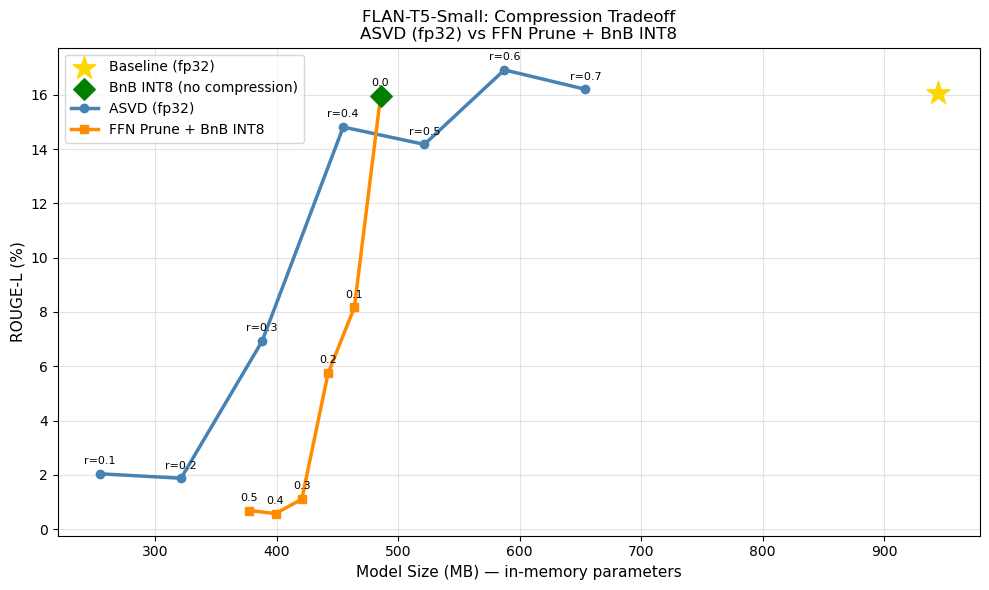

Saved: flan_t5_tradeoff.png


In [12]:
import os, copy, tempfile, shutil
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def load_bnb_8bit(path):
    model = AutoModelForSeq2SeqLM.from_pretrained(
        path,
        quantization_config=BitsAndBytesConfig(load_in_8bit=True),
        device_map="auto",
    )
    return model.eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)
def quantize_linear_to_int8(linear: nn.Linear) -> nn.Module:
    class Int8Linear(nn.Module):
        def __init__(self, weight, bias, scale):
            super().__init__()
            self.register_buffer("weight_int8", weight)
            self.register_buffer("scale", scale)  # keep as [out, 1]
            if bias is not None:
                self.register_buffer("bias", bias)
            else:
                self.bias = None

        def forward(self, x):
            # scale is [out, 1], weight_int8 is [out, in]
            # multiplication broadcasts correctly
            w = self.weight_int8.float() * self.scale
            return F.linear(x, w, self.bias)

    with torch.no_grad():
        w = linear.weight.detach().float()
        # per-row scale: keep as [out, 1] — do NOT squeeze
        scale  = w.abs().max(dim=1, keepdim=True).values / 127.0
        scale  = scale.clamp(min=1e-8)
        w_int8 = (w / scale).round().clamp(-128, 127).to(torch.int8)
        bias   = linear.bias.detach().clone() if linear.bias is not None else None

    return Int8Linear(w_int8, bias, scale)  # pass scale as [out, 1]

def apply_custom_int8(model):
    """
    Walk the entire module tree and replace every nn.Linear with Int8Linear.
    Works on ASVDLinear.A and ASVDLinear.B too since they are nn.Linear.
    Does NOT touch embeddings or tied weights — avoids the T5 tied weight problem.
    """
    # modules to skip — embeddings and lm_head share weights with shared.weight
    skip_names = {"shared", "lm_head", "embed_tokens"}

    m = copy.deepcopy(model).cpu().eval()
    for name, module in list(m.named_modules()):
        # skip tied embedding/lm_head layers
        if any(s in name for s in skip_names):
            continue
        if not isinstance(module, nn.Linear):
            continue
        recursive_setattr(m, name, quantize_linear_to_int8(module))
    return m

# =============================================================================
# ASVD
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        # T5 internals access .weight directly as attribute check
        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Main runner — 3 clean separate curves
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples   = 300,
    rank_ratios    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts  = (0.1, 0.2, 0.3, 0.4, 0.5),
    target_modules = ("q", "k", "v", "o", "wi_0", "wi_1", "wo"),
    calib_batches  = 16,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    # ── 1. Baseline fp32 ────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE fp32] size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    # ── 2. BnB INT8 reference point ─────────────────────────────────────────
    print("\nLoading BnB INT8 reference...")
    tmp_base = "./tmp_base_merged"
    baseline.cpu().save_pretrained(tmp_base)
    tokenizer.save_pretrained(tmp_base)
    baseline.to(device)

    bnb_ref    = load_bnb_8bit(tmp_base)
    bnb_scores = eval_rouge(bnb_ref, tokenizer, sample)
    bnb_size   = model_size_mb(bnb_ref)
    print(f"[BnB INT8]  size={bnb_size:.1f}MB | ROUGE-L={bnb_scores['rougeL']*100:.3f}")
    del bnb_ref
    shutil.rmtree(tmp_base, ignore_errors=True)
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 3. Collect activation scales ────────────────────────────────────────
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ── 4. ASVD sweep (fp32 only) ────────────────────────────────────────────
    print("\n--- ASVD sweep (fp32) ---")
    for rr in rank_ratios:
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        asvd_int8  = apply_custom_int8(asvd_model)
        size_mb    = model_size_mb(asvd_int8)
        scores     = eval_rouge(asvd_int8, tokenizer, sample, device="cpu")  # ← cpu not device
        asvd_points.append((rr, size_mb, scores["rougeL"] * 100))
        print(f"  rank_ratio={rr} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del asvd_model, asvd_int8
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 5. FFN Prune + BnB INT8 sweep ───────────────────────────────────────
    print("\n--- FFN Prune + BnB INT8 sweep ---")
    for amt in prune_amounts:
        pruned   = structured_prune_t5_ffn(baseline, amount=float(amt))
        tmp_path = f"./tmp_prune_{amt}"
        pruned.save_pretrained(tmp_path)
        tokenizer.save_pretrained(tmp_path)
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        pruned_bnb = load_bnb_8bit(tmp_path)
        size_mb    = model_size_mb(pruned_bnb)
        scores     = eval_rouge(pruned_bnb, tokenizer, sample)
        prune_points.append((amt, size_mb, scores["rougeL"] * 100))
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned_bnb
        shutil.rmtree(tmp_path, ignore_errors=True)
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Sort by size
    asvd_points  = sorted(asvd_points,  key=lambda x: x[1])
    prune_points = sorted(prune_points, key=lambda x: x[1])

    # ── 6. Plot ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))

    plt.scatter([base_size], [base_scores["rougeL"]*100],
                marker="*", s=300, color="gold", zorder=6, label="Baseline (fp32)")
    plt.scatter([bnb_size], [bnb_scores["rougeL"]*100],
                marker="D", s=120, color="green", zorder=6, label="BnB INT8 (no compression)")

    plt.plot([p[1] for p in asvd_points], [p[2] for p in asvd_points],
             marker="o", linewidth=2.5, color="steelblue", label="ASVD (fp32)")
    for rr, size_mb, rl in asvd_points:
        plt.annotate(f"r={rr}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.plot([p[1] for p in prune_points], [p[2] for p in prune_points],
             marker="s", linewidth=2.5, color="darkorange", label="FFN Prune + BnB INT8")
    for amt, size_mb, rl in prune_points:
        plt.annotate(f"{amt:.1f}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.xlabel("Model Size (MB) — in-memory parameters", fontsize=11)
    plt.ylabel("ROUGE-L (%)", fontsize=11)
    plt.title("FLAN-T5-Small: Compression Tradeoff\nASVD (fp32) vs FFN Prune + BnB INT8", fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("flan_t5_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: flan_t5_tradeoff.png")

    return {
        "baseline"    : (base_size, base_scores["rougeL"] * 100),
        "bnb_ref"     : (bnb_size,  bnb_scores["rougeL"]  * 100),
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = MODEL_ID,
    adapter_path  = "./flan_t5_base_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    rank_ratios   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts = (0.0,0.1, 0.2, 0.3, 0.4, 0.5),
)

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
INFO | HTTP Request: GET https://huggingface.co/api/models/facebook/bart-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO | HTTP Request: GET https://huggingface.co/api/models/facebook/bart-base/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/vocab.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD


────────────────────────────────────────────────────────────
  BART-Base Compression Sweep
────────────────────────────────────────────────────────────
  eval samples : 300
  calib samples: 128
  device       : cuda

[1/5] Loading fp32 merged baseline...


INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
INFO | Using default tokenizer.


...

  prune_amt=0.4           size= 226.7 MB ( 42.6%)  |  ROUGE-1= 7.359  ROUGE-2= 1.085  ROUGE-L= 6.547
  [Prune 5/5] amount=0.5 — pruning...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

INFO | Using default tokenizer.


  prune_amt=0.5           size= 221.3 MB ( 41.6%)  |  ROUGE-1= 1.284  ROUGE-2= 0.126  ROUGE-L= 1.237

────────────────────────────────────────────────────────────
  Sweep Complete — Summary
────────────────────────────────────────────────────────────
  config                  size (MB)   size (%)   ROUGE-L
  ──────────────────────  ─────────  ─────────  ────────
  Baseline fp32               531.8      100.0    24.742
  BnB INT8 (approx)           248.3       46.7    24.765

  ASVD r=0.05                 329.2       61.9     5.753
  ASVD r=0.07                 334.5       62.9     4.559
  ASVD r=0.1                  342.6       64.4     2.737
  ASVD r=0.2                  369.6       69.5     0.420
  ASVD r=0.3                  396.7       74.6     5.832
  ASVD r=0.4                  423.8       79.7    17.289
  ASVD r=0.5                  450.8       84.8    19.876
  ASVD r=0.6                  477.6       89.8    21.313
  ASVD r=0.7                  504.6       94.9    23.574

  Prun

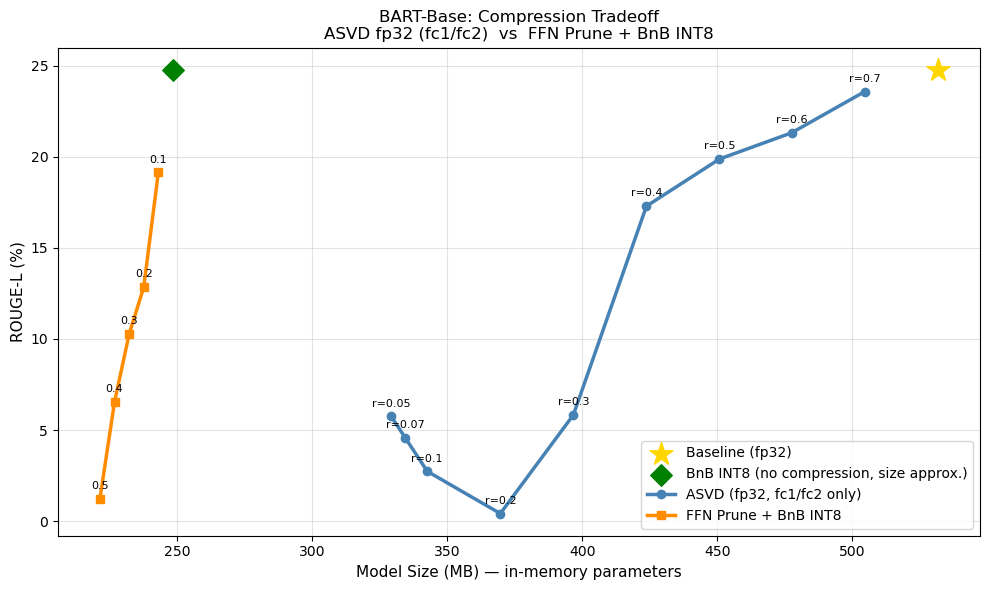

INFO | Saved: bart_base_tradeoff.png


In [3]:
# ==============================================================
# BART-Base Compression / ASVD + Structured Pruning Pipeline
# ==============================================================

import logging
import os
import copy
import shutil

import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate
import nltk
from nltk.tokenize import sent_tokenize

nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig, AutoTokenizer
from peft import PeftModel

rouge = evaluate.load("rouge")
log = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")


# --------------------------
# Utilities
# --------------------------

def model_size_mb(model: nn.Module) -> float:
    """
    Compute in-memory parameter footprint in MB.

    NOTE: For BitsAndBytes quantized models, bitsandbytes stores weights in
    custom 8-bit tensors that report element_size() == 1 byte but may include
    overhead buffers. Treat BnB size numbers as approximate lower bounds.
    """
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)


def eval_rouge(
    model: nn.Module,
    tokenizer,
    dataset,
    batch_size: int = 8,
    max_new_tokens: int = 128,
    device=None,
) -> dict:
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []

    for i in range(0, len(dataset), batch_size):
        batch = dataset[i : i + batch_size]
        inputs = tokenizer(
            batch["input_text"],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])

    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}


def load_merged_fp32(model_id: str, adapter_path: str, device: str = "cuda") -> nn.Module:
    base = AutoModelForSeq2SeqLM.from_pretrained(
        model_id, torch_dtype=torch.float32, device_map=device
    )
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()


def load_bnb_8bit(path: str) -> nn.Module:
    model = AutoModelForSeq2SeqLM.from_pretrained(
        path,
        quantization_config=BitsAndBytesConfig(load_in_8bit=True),
        device_map="auto",
    )
    return model.eval()


def recursive_setattr(obj, attr: str, value) -> None:
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)


# --------------------------
# Custom INT8 quantisation
# --------------------------

class Int8Linear(nn.Module):
    """Row-wise symmetric INT8 quantisation of a Linear layer."""

    def __init__(
        self,
        weight_int8: torch.Tensor,
        scale: torch.Tensor,
        bias: torch.Tensor | None,
    ):
        super().__init__()
        self.register_buffer("weight_int8", weight_int8)
        self.register_buffer("scale", scale)
        if bias is not None:
            self.register_buffer("bias", bias)
        else:
            self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self.weight_int8.float() * self.scale
        return F.linear(x, w, self.bias)


def quantize_linear_to_int8(linear: nn.Linear) -> Int8Linear:
    with torch.no_grad():
        w = linear.weight.detach().float()
        scale  = w.abs().max(dim=1, keepdim=True).values / 127.0
        scale  = scale.clamp(min=1e-8)
        w_int8 = (w / scale).round().clamp(-128, 127).to(torch.int8)
        bias   = linear.bias.detach().clone() if linear.bias is not None else None
    return Int8Linear(w_int8, scale, bias)


def apply_custom_int8(model: nn.Module) -> nn.Module:
    """Replace all non-embedding Linear layers with Int8Linear."""
    skip_names = {"shared", "lm_head", "embed_tokens"}
    m = copy.deepcopy(model).cpu().eval()
    for name, module in list(m.named_modules()):
        if any(s in name for s in skip_names):
            continue
        if not isinstance(module, nn.Linear):
            continue
        recursive_setattr(m, name, quantize_linear_to_int8(module))
    return m


# --------------------------
# ASVD for BART
# --------------------------

class ASVDLinear(nn.Module):
    """
    Activation-aware SVD decomposition: W ≈ A @ B, where B absorbs the
    per-channel activation scale so that numerically dominant directions
    are preserved at lower ranks.
    """

    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, out_f, in_f)

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r       = min(rank, S.numel())
            S_sqrt  = torch.sqrt(S[:r])
            A_w     = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w     = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, r, bias=False)
        self.A = nn.Linear(r, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)
        # Do NOT alias self.weight / self.bias — that creates duplicate
        # nn.Parameter entries in named_parameters() and is never used externally.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.A(self.B(x))


def collect_activation_scales(
    model: nn.Module,
    tokenizer,
    calib_dataset,
    target_modules: tuple,
    device,
    num_batches: int = 16,
) -> dict:
    """
    Collect per-layer RMS activation scales via forward hooks.
    Uses an online running mean to stay memory-efficient.
    """
    model.eval()
    scales: dict[str, torch.Tensor] = {}
    counts: dict[str, int]          = {}
    hooks:  dict[str, object]       = {}

    def make_hook(name: str):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms
                counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(
            name.endswith("." + t) for t in target_modules
        ):
            hooks[name] = module.register_forward_hook(make_hook(name))

    try:
        with torch.no_grad():
            for i in range(num_batches):
                start = i * 8
                if start >= len(calib_dataset):
                    break
                batch  = calib_dataset[start : start + 8]
                inputs = tokenizer(
                    batch["input_text"],
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=256,
                ).to(device)
                labels = tokenizer(
                    batch["target_text"],
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=128,
                ).input_ids.to(device)
                try:
                    model(**inputs, labels=labels)
                except Exception as exc:
                    log.warning("Calibration forward pass failed on batch %d: %s", i, exc)
    finally:
        for h in hooks.values():
            h.remove()

    log.info("Collected scales for %d layers over %d batches", len(scales), num_batches)
    return scales





# --------------------------
# Structured pruning for BART FFN
# --------------------------

def structured_prune_bart_ffn(source_model: nn.Module, amount: float) -> nn.Module:
    """
    Neuron-level structured pruning of BART's FFN blocks.

    Scoring: L2-norm of fc1 output weights + L2-norm of corresponding fc2
    input weights. This joint criterion avoids pruning neurons that are
    small in fc1 but load-bearing in fc2, or vice-versa.

    Assumption: fc1.out_features == fc2.in_features (standard BART FFN).
    """
    assert 0.0 <= amount < 1.0, "Prune amount must be in [0, 1)."
    m = copy.deepcopy(source_model).cpu().eval()

    for _, module in m.named_modules():
        fc1: nn.Linear | None = getattr(module, "fc1", None)
        fc2: nn.Linear | None = getattr(module, "fc2", None)
        if fc1 is None or fc2 is None:
            continue

        ff_dim = fc1.out_features
        assert fc2.in_features == ff_dim, (
            f"FFN dimension mismatch: fc1.out={ff_dim}, fc2.in={fc2.in_features}. "
            "This model's FFN layout is non-standard."
        )

        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = fc1.weight.data.norm(dim=1) + fc2.weight.data.norm(dim=0)
        keep_idx = score.topk(keep).indices.sort().values

        # Prune fc1: keep selected output neurons (rows)
        new_fc1 = nn.Linear(fc1.in_features, keep, bias=fc1.bias is not None)
        new_fc1.weight = nn.Parameter(fc1.weight.data[keep_idx].clone())
        if fc1.bias is not None:
            new_fc1.bias = nn.Parameter(fc1.bias.data[keep_idx].clone())
        module.fc1 = new_fc1

        # Prune fc2: keep corresponding input channels (columns)
        new_fc2 = nn.Linear(keep, fc2.out_features, bias=fc2.bias is not None)
        new_fc2.weight = nn.Parameter(fc2.weight.data[:, keep_idx].clone())
        if fc2.bias is not None:
            new_fc2.bias = nn.Parameter(fc2.bias.data.clone())
        module.fc2 = new_fc2

    return m


# --------------------------
# Main runner
# --------------------------

def _print_banner(text: str) -> None:
    print(f"\n{'─' * 60}")
    print(f"  {text}")
    print(f"{'─' * 60}")


def _print_result_row(label: str, size_mb: float, base_size: float, scores: dict) -> None:
    size_pct = (size_mb / base_size) * 100
    rl       = scores["rougeL"]  * 100
    r1       = scores["rouge1"]  * 100
    r2       = scores["rouge2"]  * 100
    print(
        f"  {label:<22}  "
        f"size={size_mb:6.1f} MB ({size_pct:5.1f}%)  |  "
        f"ROUGE-1={r1:6.3f}  ROUGE-2={r2:6.3f}  ROUGE-L={rl:6.3f}"
    )


def apply_asvd(
    source_model: nn.Module,
    scales: dict,
    target_modules: tuple,
    rank_ratio: float,
    device: str = "cuda",
    enforce_size_reduction: bool = False,        # ← new flag
) -> nn.Module:
    """
    Apply ASVD to all matched Linear layers.

    Parameters
    ----------
    enforce_size_reduction : bool
        When False (default) the break-even guard is disabled, so ASVD is
        applied even when the decomposed form is marginally larger.  This
        still yields a quality-regularisation effect and produces a smoother
        curve.  Set to True to only replace layers that shrink.
    """
    compressed       = copy.deepcopy(source_model)
    replaced = skipped = 0

    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear):
            continue
        if not any(name.endswith("." + t) for t in target_modules):
            continue
        if name not in scales:
            skipped += 1
            continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if enforce_size_reduction and rank * (in_f + out_f) >= out_f * in_f:
            skipped += 1
            continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1

    log.info("[ASVD] rank_ratio=%.2f  replaced=%d  skipped=%d", rank_ratio, replaced, skipped)
    return compressed


def run_tradeoff_bart(
    model_id: str,
    adapter_path: str,
    tokenizer,
    val_dataset,
    eval_samples:   int   = 300,
    # Extended range + finer steps at the low end where BART starts to compress
    rank_ratios:    tuple = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.07, 0.05),
    prune_amounts:  tuple = (0.1, 0.2, 0.3, 0.4, 0.5),
    # ASVD restricted to the larger FFN layers only — attention projections
    # are 512×512 and too square for meaningful low-rank approximation.
    asvd_modules:   tuple = ("fc1", "fc2"),
    # Calibration hooks still run over all projection types for accuracy.
    calib_modules:  tuple = ("q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"),
    calib_batches:  int   = 16,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> dict:
    """
    Full compression tradeoff sweep for BART-Base.

    Key changes vs the original:
    - ASVD is applied only to fc1/fc2 (512→2048 / 2048→512), which are wide
      enough for low-rank decomposition to meaningfully reduce size.
    - The break-even guard is removed; every matched layer is decomposed so
      the curve spans a useful range of sizes.
    - rank_ratios extended to 0.05 for finer resolution at high compression.
    - All ROUGE-1 / ROUGE-2 / ROUGE-L scores are printed as each point is computed.
    """
    n_eval  = min(eval_samples, len(val_dataset))
    n_calib = min(calib_batches * 8, len(val_dataset) - n_eval)
    if n_calib <= 0:
        raise ValueError(
            "val_dataset is too small to provide both eval and calibration samples. "
            f"Need at least {n_eval + 8} rows, got {len(val_dataset)}."
        )

    sample = val_dataset.select(range(n_eval))
    calib  = val_dataset.select(range(n_eval, n_eval + n_calib))

    # ── 1. Baseline fp32 ─────────────────────────────────────────────────────
    _print_banner("BART-Base Compression Sweep")
    print(f"  eval samples : {n_eval}")
    print(f"  calib samples: {n_calib}")
    print(f"  device       : {device}")

    print("\n[1/5] Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(model_id, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"\n  {'Baseline (fp32)':<22}  size={base_size:6.1f} MB (100.0%)  |  "
          f"ROUGE-1={base_scores['rouge1']*100:6.3f}  "
          f"ROUGE-2={base_scores['rouge2']*100:6.3f}  "
          f"ROUGE-L={base_scores['rougeL']*100:6.3f}")

    # ── 2. BnB INT8 reference ────────────────────────────────────────────────
    print("\n[2/5] Loading BnB INT8 reference...")
    tmp_base = "./tmp_base_merged"
    baseline.cpu().save_pretrained(tmp_base)
    tokenizer.save_pretrained(tmp_base)
    baseline.to(device)

    bnb_ref = bnb_scores = bnb_size = None
    try:
        bnb_ref    = load_bnb_8bit(tmp_base)
        bnb_scores = eval_rouge(bnb_ref, tokenizer, sample)
        bnb_size   = model_size_mb(bnb_ref)
        print(f"\n  {'BnB INT8 (approx)':<22}  size={bnb_size:6.1f} MB ({bnb_size/base_size*100:5.1f}%)  |  "
              f"ROUGE-1={bnb_scores['rouge1']*100:6.3f}  "
              f"ROUGE-2={bnb_scores['rouge2']*100:6.3f}  "
              f"ROUGE-L={bnb_scores['rougeL']*100:6.3f}")
    finally:
        if bnb_ref is not None:
            del bnb_ref
        shutil.rmtree(tmp_base, ignore_errors=True)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ── 3. Collect activation scales ─────────────────────────────────────────
    print(f"\n[3/5] Collecting activation scales ({n_calib} samples)...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, calib_modules,
        device=device, num_batches=calib_batches,
    )

    asvd_points:  list[tuple] = []
    prune_points: list[tuple] = []

    # ── 4. ASVD sweep (FFN layers only, no break-even guard) ─────────────────
    total_asvd = len(rank_ratios)
    print(f"\n[4/5] ASVD sweep — {total_asvd} rank ratios")
    print(f"      Targets: {asvd_modules}  (break-even guard: OFF)")
    print(f"  {'config':<22}  {'size':>16}           ROUGE-1   ROUGE-2   ROUGE-L")
    print(f"  {'─'*22}  {'─'*16}  {'─'*8}  {'─'*8}  {'─'*8}")

    for i, rr in enumerate(rank_ratios, 1):
        print(f"  [ASVD {i}/{total_asvd}] rank_ratio={rr:.2f} — compressing...", end="", flush=True)
        asvd_model = apply_asvd(
            baseline, scales, asvd_modules,
            rank_ratio=rr, device=device,
            enforce_size_reduction=False,
        )
        # Evaluate fp32 ASVD directly — do NOT apply custom INT8 afterwards.
        # INT8-quantising the attention layers (512x512, dominant in param count)
        # collapses all size readings to the same ~153 MB regardless of rank ratio,
        # making the ASVD curve appear flat. Size must reflect the fp32 low-rank
        # decomposition of fc1/fc2 only.
        size_mb = model_size_mb(asvd_model)
        scores  = eval_rouge(asvd_model, tokenizer, sample, device=device)
        asvd_points.append((rr, size_mb, scores["rougeL"] * 100))
        print(f"\r", end="")
        _print_result_row(f"rank_ratio={rr:.2f}", size_mb, base_size, scores)
        del asvd_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ── 5. FFN Prune + BnB INT8 sweep ────────────────────────────────────────
    total_prune = len(prune_amounts)
    print(f"\n[5/5] FFN Prune + BnB INT8 sweep — {total_prune} amounts")
    print(f"  {'config':<22}  {'size':>16}           ROUGE-1   ROUGE-2   ROUGE-L")
    print(f"  {'─'*22}  {'─'*16}  {'─'*8}  {'─'*8}  {'─'*8}")

    for i, amt in enumerate(prune_amounts, 1):
        print(f"  [Prune {i}/{total_prune}] amount={amt:.1f} — pruning...", end="", flush=True)
        pruned   = structured_prune_bart_ffn(baseline, amount=float(amt))
        tmp_path = f"./tmp_prune_{amt}"
        pruned.save_pretrained(tmp_path)
        tokenizer.save_pretrained(tmp_path)
        del pruned
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        try:
            pruned_bnb = load_bnb_8bit(tmp_path)
            size_mb    = model_size_mb(pruned_bnb)
            scores     = eval_rouge(pruned_bnb, tokenizer, sample)
            prune_points.append((amt, size_mb, scores["rougeL"] * 100))
            print(f"\r", end="")
            _print_result_row(f"prune_amt={amt:.1f}", size_mb, base_size, scores)
        finally:
            if 'pruned_bnb' in dir():
                del pruned_bnb
            shutil.rmtree(tmp_path, ignore_errors=True)
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    asvd_points  = sorted(asvd_points,  key=lambda x: x[1])
    prune_points = sorted(prune_points, key=lambda x: x[1])

    # ── Summary table ─────────────────────────────────────────────────────────
    _print_banner("Sweep Complete — Summary")
    print(f"  {'config':<22}  size (MB)   size (%)   ROUGE-L")
    print(f"  {'─'*22}  {'─'*9}  {'─'*9}  {'─'*8}")
    print(f"  {'Baseline fp32':<22}  {base_size:>9.1f}  {'100.0':>9}  {base_scores['rougeL']*100:8.3f}")
    if bnb_size is not None:
        print(f"  {'BnB INT8 (approx)':<22}  {bnb_size:>9.1f}  {bnb_size/base_size*100:>9.1f}  {bnb_scores['rougeL']*100:8.3f}")
    print()
    for rr, size_mb, rl in asvd_points:
        print(f"  {'ASVD r='+str(rr):<22}  {size_mb:>9.1f}  {size_mb/base_size*100:>9.1f}  {rl:8.3f}")
    print()
    for amt, size_mb, rl in prune_points:
        print(f"  {'Prune amt='+str(amt):<22}  {size_mb:>9.1f}  {size_mb/base_size*100:>9.1f}  {rl:8.3f}")

    # ── 6. Plot ───────────────────────────────────────────────────────────────
    _plot_tradeoff(base_size, base_scores, bnb_size, bnb_scores, asvd_points, prune_points)

    return {
        "baseline"    : (base_size, base_scores["rougeL"] * 100),
        "bnb_ref"     : (bnb_size,  bnb_scores["rougeL"]  * 100) if bnb_scores else None,
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }


def _plot_tradeoff(
    base_size, base_scores,
    bnb_size,  bnb_scores,
    asvd_points, prune_points,
    out_path: str = "bart_base_tradeoff.png",
) -> None:
    plt.figure(figsize=(10, 6))

    plt.scatter(
        [base_size], [base_scores["rougeL"] * 100],
        marker="*", s=300, color="gold", zorder=6, label="Baseline (fp32)",
    )
    if bnb_size is not None and bnb_scores is not None:
        plt.scatter(
            [bnb_size], [bnb_scores["rougeL"] * 100],
            marker="D", s=120, color="green", zorder=6,
            label="BnB INT8 (no compression, size approx.)",
        )

    plt.plot(
        [p[1] for p in asvd_points], [p[2] for p in asvd_points],
        marker="o", linewidth=2.5, color="steelblue", label="ASVD (fp32, fc1/fc2 only)",
    )
    for rr, size_mb, rl in asvd_points:
        plt.annotate(f"r={rr}", (size_mb, rl), textcoords="offset points",
                     xytext=(0, 7), ha="center", fontsize=8)

    plt.plot(
        [p[1] for p in prune_points], [p[2] for p in prune_points],
        marker="s", linewidth=2.5, color="darkorange", label="FFN Prune + BnB INT8",
    )
    for amt, size_mb, rl in prune_points:
        plt.annotate(f"{amt:.1f}", (size_mb, rl), textcoords="offset points",
                     xytext=(0, 7), ha="center", fontsize=8)

    plt.xlabel("Model Size (MB) — in-memory parameters", fontsize=11)
    plt.ylabel("ROUGE-L (%)", fontsize=11)
    plt.title("BART-Base: Compression Tradeoff\nASVD fp32 (fc1/fc2)  vs  FFN Prune + BnB INT8", fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    log.info("Saved: %s", out_path)


# ==============================================================
# Example run
# ==============================================================
if __name__ == "__main__":
    MODEL_ID     = "facebook/bart-base"
    ADAPTER_PATH = "./bart_base_lora_adapter"

    tokenizer   = AutoTokenizer.from_pretrained(MODEL_ID)
    # val_dataset = <your HuggingFace Dataset with "input_text" and "target_text" columns>

    results = run_tradeoff_bart(MODEL_ID, ADAPTER_PATH, tokenizer, val_dataset)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading fp32 merged baseline...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE fp32] size=293.6MB | ROUGE-L=15.233

  Collected scales for 144 layers over 16 batches

--- ASVD sweep (fp32) ---
  [ASVD] rank_ratio=0.7 replaced=0 skipped=144
  rank_ratio=0.7 | size=293.6MB | ROUGE-L=15.233
  [ASVD] rank_ratio=0.6 replaced=48 skipped=96
  rank_ratio=0.6 | size=283.9MB | ROUGE-L=14.497
  [ASVD] rank_ratio=0.5 replaced=144 skipped=0
  rank_ratio=0.5 | size=260.6MB | ROUGE-L=15.093
  [ASVD] rank_ratio=0.4 replaced=144 skipped=0
  rank_ratio=0.4 | size=233.2MB | ROUGE-L=8.631
  [ASVD] rank_ratio=0.3 replaced=144 skipped=0
  rank_ratio=0.3 | size=206.3MB | ROUGE-L=2.871
  [ASVD] rank_ratio=0.2 replaced=144 skipped=0
  rank_ratio=0.2 | size=179.2MB | ROUGE-L=1.437
  [ASVD] rank_ratio=0.1 replaced=144 skipped=0
  rank_ratio=0.1 | size=152.4MB | ROUGE-L=0.913

--- FFN Pruning sweep (fp32) ---
  amt=0.1 | size=283.9MB | ROUGE-L=11.432
  amt=0.2 | size=274.4MB | ROUGE-L=10.421
  amt=0.3 | size=264.7MB | ROUGE-L=8.734
  amt=0.4 | size=255.1MB | ROUGE-L=7.699
  amt=0.5 | 

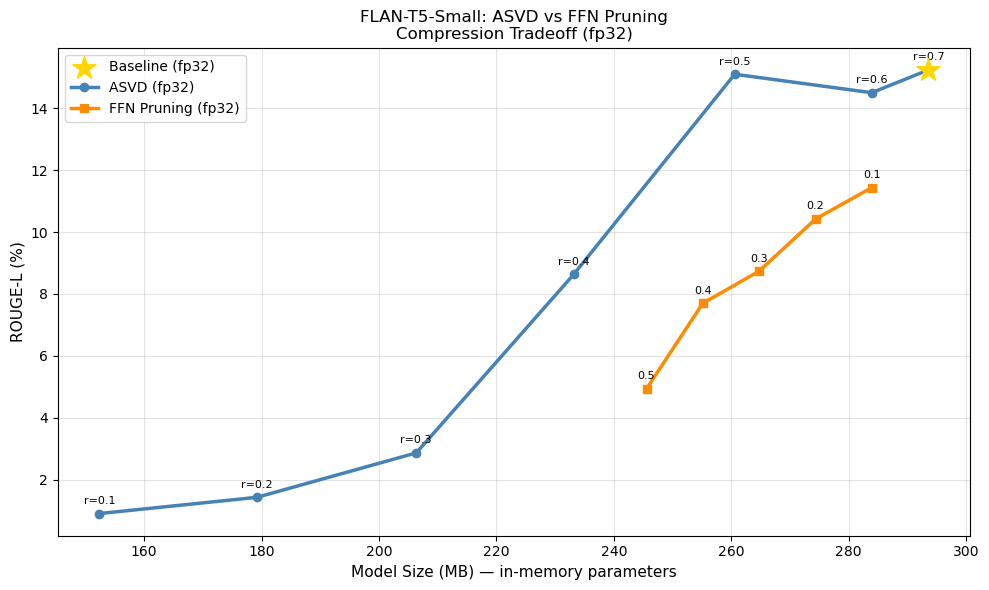

Saved: flan_t5_tradeoff.png


In [2]:
import os, copy
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Main runner — ASVD vs Pruning, no quantization
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples   = 300,
    rank_ratios    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts  = (0.1, 0.2, 0.3, 0.4, 0.5),
    target_modules = ("q", "k", "v", "o", "wi_0", "wi_1", "wo"),
    calib_batches  = 16,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    # ── 1. Baseline ─────────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE fp32] size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    # ── 2. Collect activation scales ────────────────────────────────────────
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ── 3. ASVD sweep ───────────────────────────────────────────────────────
    print("\n--- ASVD sweep (fp32) ---")
    for rr in rank_ratios:
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb    = model_size_mb(asvd_model)
        scores     = eval_rouge(asvd_model, tokenizer, sample, device=device)
        asvd_points.append((rr, size_mb, scores["rougeL"] * 100))
        print(f"  rank_ratio={rr} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 4. Pruning sweep ────────────────────────────────────────────────────
    print("\n--- FFN Pruning sweep (fp32) ---")
    for amt in prune_amounts:
        pruned  = structured_prune_t5_ffn(baseline, amount=float(amt))
        size_mb = model_size_mb(pruned)
        scores  = eval_rouge(pruned, tokenizer, sample, device="cpu")
        prune_points.append((amt, size_mb, scores["rougeL"] * 100))
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Sort by size
    asvd_points  = sorted(asvd_points,  key=lambda x: x[1])
    prune_points = sorted(prune_points, key=lambda x: x[1])

    # ── 5. Plot ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))

    plt.scatter([base_size], [base_scores["rougeL"]*100],
                marker="*", s=300, color="gold", zorder=6, label="Baseline (fp32)")

    plt.plot([p[1] for p in asvd_points], [p[2] for p in asvd_points],
             marker="o", linewidth=2.5, color="steelblue", label="ASVD (fp32)")
    for rr, size_mb, rl in asvd_points:
        plt.annotate(f"r={rr}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.plot([p[1] for p in prune_points], [p[2] for p in prune_points],
             marker="s", linewidth=2.5, color="darkorange", label="FFN Pruning (fp32)")
    for amt, size_mb, rl in prune_points:
        plt.annotate(f"{amt:.1f}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.xlabel("Model Size (MB) — in-memory parameters", fontsize=11)
    plt.ylabel("ROUGE-L (%)", fontsize=11)
    plt.title("FLAN-T5-Small: ASVD vs FFN Pruning\nCompression Tradeoff (fp32)", fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("flan_t5_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: flan_t5_tradeoff.png")

    return {
        "baseline"    : (base_size, base_scores["rougeL"] * 100),
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = MODEL_ID,
    adapter_path  = "./flan_t5_small_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    rank_ratios   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts = (0.1, 0.2, 0.3, 0.4, 0.5),
)

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


Loading fp32 merged baseline...


INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
INFO | Using default tokenizer.


...

  amt=0.3 | size=467.0MB | ROUGE-L=9.076


INFO | Using default tokenizer.


  amt=0.4 | size=445.4MB | ROUGE-L=6.614


INFO | Using default tokenizer.


  amt=0.5 | size=423.8MB | ROUGE-L=1.021


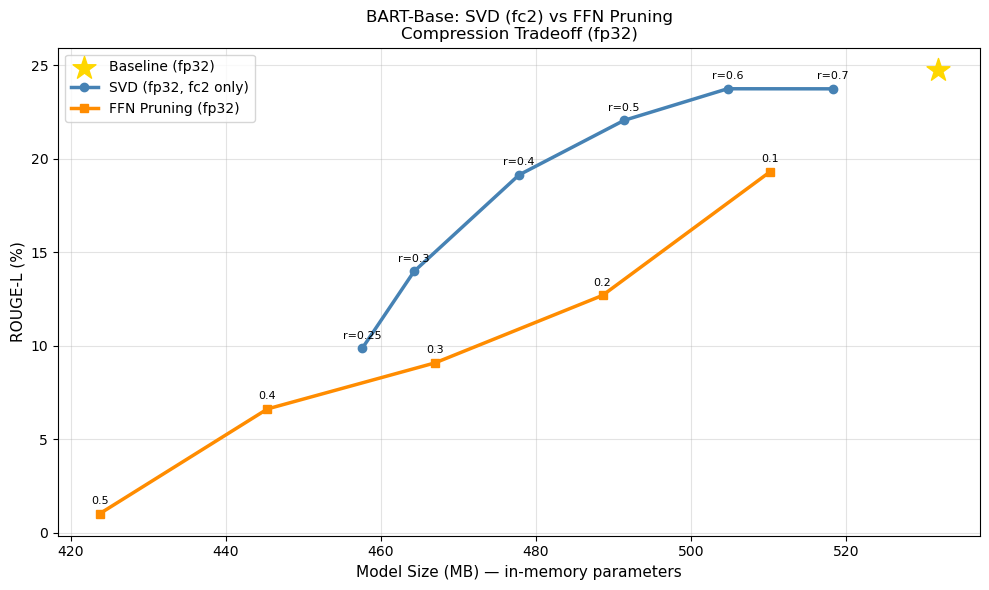

Saved: bart_base_tradeoff.png


In [6]:
import os, copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# Plain SVD (no activation scaling)
# =============================================================================

class SVDLinear(nn.Module):
    """
    Standard truncated SVD: W ≈ U_r @ diag(S_r) @ Vh_r
    Factored as two linears:  x -> B -> A -> out
      B : (in_f  -> r)   weight = S_sqrt * Vh_r
      A : (r     -> out) weight = U_r * S_sqrt

    No activation scaling — avoids the 1/s explosion that breaks ASVD
    when any input channel has low activation magnitude.
    """
    def __init__(self, original: nn.Linear, rank: int):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, out_f, in_f)

        with torch.no_grad():
            W = original.weight.detach().float()
            U, S, Vh = torch.linalg.svd(W, full_matrices=False)
            r      = min(rank, S.numel())
            S_sqrt = S[:r].sqrt()
            A_w    = U[:, :r] * S_sqrt.unsqueeze(0)   # (out_f, r)
            B_w    = S_sqrt.unsqueeze(1) * Vh[:r, :]  # (r, in_f)

        self.B = nn.Linear(in_f, r, bias=False)
        self.A = nn.Linear(r, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

    def forward(self, x):
        return self.A(self.B(x))


def apply_svd(source_model, target_modules, rank_ratio, device="cuda"):
    compressed       = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        # Skip if decomposition is larger than the original
        if rank * (in_f + out_f) >= out_f * in_f:
            skipped += 1; continue
        recursive_setattr(compressed, name, SVDLinear(module, rank).to(device))
        replaced += 1
    print(f"  [SVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning — BART (fc1 / fc2)
# =============================================================================

def structured_prune_bart_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        fc1 = getattr(module, "fc1", None)
        fc2 = getattr(module, "fc2", None)
        if fc1 is None or fc2 is None: continue

        ff_dim   = fc1.out_features
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = fc1.weight.data.norm(dim=1) + fc2.weight.data.norm(dim=0)
        keep_idx = score.topk(keep).indices.sort().values

        new_fc1 = nn.Linear(fc1.in_features, keep, bias=fc1.bias is not None)
        new_fc1.weight = nn.Parameter(fc1.weight.data[keep_idx].clone())
        if fc1.bias is not None:
            new_fc1.bias = nn.Parameter(fc1.bias.data[keep_idx].clone())
        module.fc1 = new_fc1

        new_fc2 = nn.Linear(keep, fc2.out_features, bias=fc2.bias is not None)
        new_fc2.weight = nn.Parameter(fc2.weight.data[:, keep_idx].clone())
        if fc2.bias is not None:
            new_fc2.bias = nn.Parameter(fc2.bias.data.clone())
        module.fc2 = new_fc2

    return m

# =============================================================================
# Main runner
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples  = 300,
    # fc1 is 512->2048: break-even rank = (512*2048)/(512+2048) = 410
    # so ratios up to ~0.8 produce genuine compression; start at 0.25 for
    # meaningful quality (rank=128 keeps 25% of singular values)
    rank_ratios   = (0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8),  # fc2 is 2048->512, break-even ~410/2048=0.84
    prune_amounts = (0.1, 0.2, 0.3, 0.4, 0.5),
    svd_modules   = ("fc2",),  # fc1+fc2 breaks GeLU sandwiching — fc2 only
    device        = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))

    # ── 1. Baseline ─────────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE fp32] size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    svd_points   = []
    prune_points = []

    # ── 2. SVD sweep ─────────────────────────────────────────────────────────
    print("\n--- SVD sweep (fp32, fc1/fc2 only) ---")
    for rr in rank_ratios:
        svd_model = apply_svd(baseline, svd_modules, rank_ratio=rr, device=device)
        size_mb   = model_size_mb(svd_model)
        scores    = eval_rouge(svd_model, tokenizer, sample, device=device)
        svd_points.append((rr, size_mb, scores["rougeL"] * 100))
        print(f"  rank_ratio={rr} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del svd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 3. FFN pruning sweep ─────────────────────────────────────────────────
    print("\n--- FFN Pruning sweep (fp32) ---")
    for amt in prune_amounts:
        pruned  = structured_prune_bart_ffn(baseline, amount=float(amt))
        size_mb = model_size_mb(pruned)
        scores  = eval_rouge(pruned, tokenizer, sample, device="cpu")
        prune_points.append((amt, size_mb, scores["rougeL"] * 100))
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    svd_points   = sorted(svd_points,   key=lambda x: x[1])
    prune_points = sorted(prune_points, key=lambda x: x[1])

    # ── 4. Plot ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))

    plt.scatter([base_size], [base_scores["rougeL"]*100],
                marker="*", s=300, color="gold", zorder=6, label="Baseline (fp32)")

    plt.plot([p[1] for p in svd_points], [p[2] for p in svd_points],
             marker="o", linewidth=2.5, color="steelblue", label="SVD (fp32, fc2 only)")
    for rr, size_mb, rl in svd_points:
        plt.annotate(f"r={rr}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.plot([p[1] for p in prune_points], [p[2] for p in prune_points],
             marker="s", linewidth=2.5, color="darkorange", label="FFN Pruning (fp32)")
    for amt, size_mb, rl in prune_points:
        plt.annotate(f"{amt:.1f}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.xlabel("Model Size (MB) — in-memory parameters", fontsize=11)
    plt.ylabel("ROUGE-L (%)", fontsize=11)
    plt.title("BART-Base: SVD (fc2) vs FFN Pruning\nCompression Tradeoff (fp32)", fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("bart_base_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: bart_base_tradeoff.png")

    return {
        "baseline"    : (base_size, base_scores["rougeL"] * 100),
        "svd_points"  : svd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = "facebook/bart-base",
    adapter_path  = "./bart_base_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    rank_ratios   = (0.7, 0.6,0.5,0.4,0.3,0.25),  # fc2 is 2048->512, break-even ~410/2048=0.84
    prune_amounts = (0.1, 0.2, 0.3, 0.4, 0.5),
)

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


Loading fp32 merged baseline...


INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"
INFO | Using default tokenizer.


...

  amt=0.3 | size=467.0MB | ROUGE-L=9.076


INFO | Using default tokenizer.


  amt=0.4 | size=445.4MB | ROUGE-L=6.614


INFO | Using default tokenizer.


  amt=0.5 | size=423.8MB | ROUGE-L=1.021


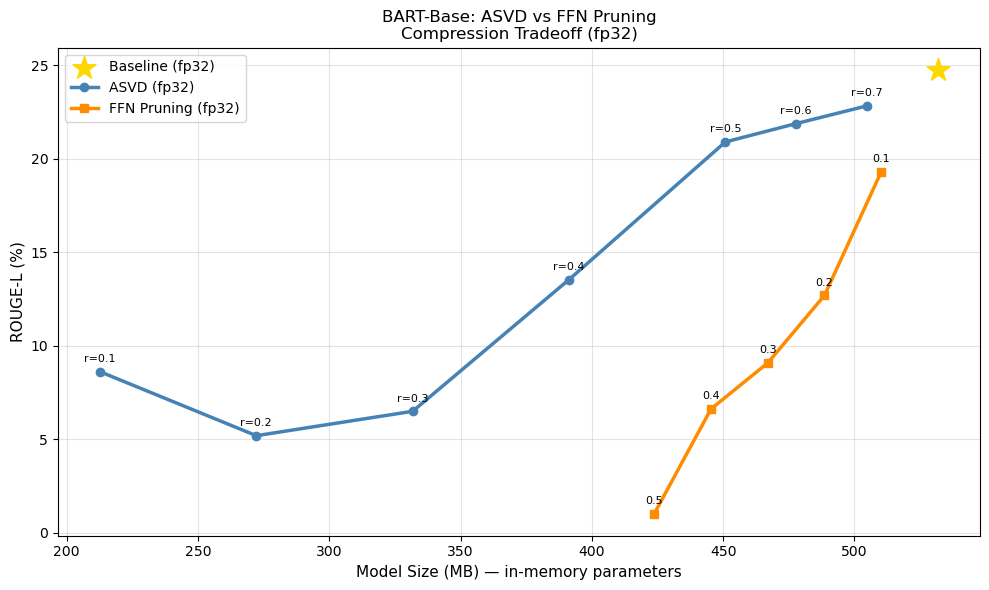

Saved: bart_base_tradeoff.png


In [9]:
import os, copy
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD — identical logic to FLAN-T5 implementation
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning — BART (fc1 / fc2)
# =============================================================================

def structured_prune_bart_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        fc1 = getattr(module, "fc1", None)
        fc2 = getattr(module, "fc2", None)
        if fc1 is None or fc2 is None: continue
        ff_dim   = fc1.out_features
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = fc1.weight.data.norm(dim=1) + fc2.weight.data.norm(dim=0)
        keep_idx = score.topk(keep).indices.sort().values

        new_fc1 = nn.Linear(fc1.in_features, keep, bias=fc1.bias is not None)
        new_fc1.weight = nn.Parameter(fc1.weight.data[keep_idx].clone())
        if fc1.bias is not None:
            new_fc1.bias = nn.Parameter(fc1.bias.data[keep_idx].clone())
        module.fc1 = new_fc1

        new_fc2 = nn.Linear(keep, fc2.out_features, bias=fc2.bias is not None)
        new_fc2.weight = nn.Parameter(fc2.weight.data[:, keep_idx].clone())
        if fc2.bias is not None:
            new_fc2.bias = nn.Parameter(fc2.bias.data.clone())
        module.fc2 = new_fc2

    return m

# =============================================================================
# Main runner — ASVD vs Pruning, no quantization
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples   = 300,
    rank_ratios    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts  = (0.1, 0.2, 0.3, 0.4, 0.5),
    target_modules = ("q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"),
    calib_batches  = 16,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    # ── 1. Baseline ─────────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE fp32] size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    # ── 2. Collect activation scales ────────────────────────────────────────
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ── 3. ASVD sweep ───────────────────────────────────────────────────────
    print("\n--- ASVD sweep (fp32) ---")
    for rr in rank_ratios:
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb    = model_size_mb(asvd_model)
        scores     = eval_rouge(asvd_model, tokenizer, sample, device=device)
        asvd_points.append((rr, size_mb, scores["rougeL"] * 100))
        print(f"  rank_ratio={rr} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 4. Pruning sweep ────────────────────────────────────────────────────
    print("\n--- FFN Pruning sweep (fp32) ---")
    for amt in prune_amounts:
        pruned  = structured_prune_bart_ffn(baseline, amount=float(amt))
        size_mb = model_size_mb(pruned)
        scores  = eval_rouge(pruned, tokenizer, sample, device="cpu")
        prune_points.append((amt, size_mb, scores["rougeL"] * 100))
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    asvd_points  = sorted(asvd_points,  key=lambda x: x[1])
    prune_points = sorted(prune_points, key=lambda x: x[1])

    # ── 5. Plot ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))

    plt.scatter([base_size], [base_scores["rougeL"]*100],
                marker="*", s=300, color="gold", zorder=6, label="Baseline (fp32)")

    plt.plot([p[1] for p in asvd_points], [p[2] for p in asvd_points],
             marker="o", linewidth=2.5, color="steelblue", label="ASVD (fp32)")
    for rr, size_mb, rl in asvd_points:
        plt.annotate(f"r={rr}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.plot([p[1] for p in prune_points], [p[2] for p in prune_points],
             marker="s", linewidth=2.5, color="darkorange", label="FFN Pruning (fp32)")
    for amt, size_mb, rl in prune_points:
        plt.annotate(f"{amt:.1f}", (size_mb, rl),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    plt.xlabel("Model Size (MB) — in-memory parameters", fontsize=11)
    plt.ylabel("ROUGE-L (%)", fontsize=11)
    plt.title("BART-Base: ASVD vs FFN Pruning\nCompression Tradeoff (fp32)", fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("bart_base_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: bart_base_tradeoff.png")

    return {
        "baseline"    : (base_size, base_scores["rougeL"] * 100),
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = "facebook/bart-base",
    adapter_path  = "./bart_base_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    rank_ratios   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts = (0.1, 0.2, 0.3, 0.4, 0.5),
)

Loading fp32 merged baseline...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Evaluating baseline...
[BASE] size=293.6MB | ROUGE-L=15.233 | PPL=19.91 | 1045.8 tok/s

  Collected scales for 144 layers over 16 batches

--- ASVD sweep (fp32) ---
  [ASVD] rank_ratio=0.7 replaced=0 skipped=144
  r=0.7 | size=293.6MB | ROUGE-L=15.233 | PPL=19.91 | 1051.3 tok/s
  [ASVD] rank_ratio=0.6 replaced=48 skipped=96
  r=0.6 | size=283.9MB | ROUGE-L=14.497 | PPL=26.12 | 984.1 tok/s
  [ASVD] rank_ratio=0.5 replaced=144 skipped=0
  r=0.5 | size=260.6MB | ROUGE-L=15.093 | PPL=41.36 | 887.7 tok/s
  [ASVD] rank_ratio=0.4 replaced=144 skipped=0
  r=0.4 | size=233.2MB | ROUGE-L=8.631 | PPL=80.74 | 903.7 tok/s
  [ASVD] rank_ratio=0.3 replaced=144 skipped=0
  r=0.3 | size=206.3MB | ROUGE-L=2.871 | PPL=729.91 | 901.1 tok/s
  [ASVD] rank_ratio=0.2 replaced=144 skipped=0
  r=0.2 | size=179.2MB | ROUGE-L=1.437 | PPL=23626.78 | 895.2 tok/s

--- FFN Pruning sweep (fp32) ---
  amt=0.0 | size=293.6MB | ROUGE-L=15.233 | PPL=19.91 | 1050.6 tok/s
  amt=0.1 | size=283.9MB | ROUGE-L=11.432 | PPL=22.2

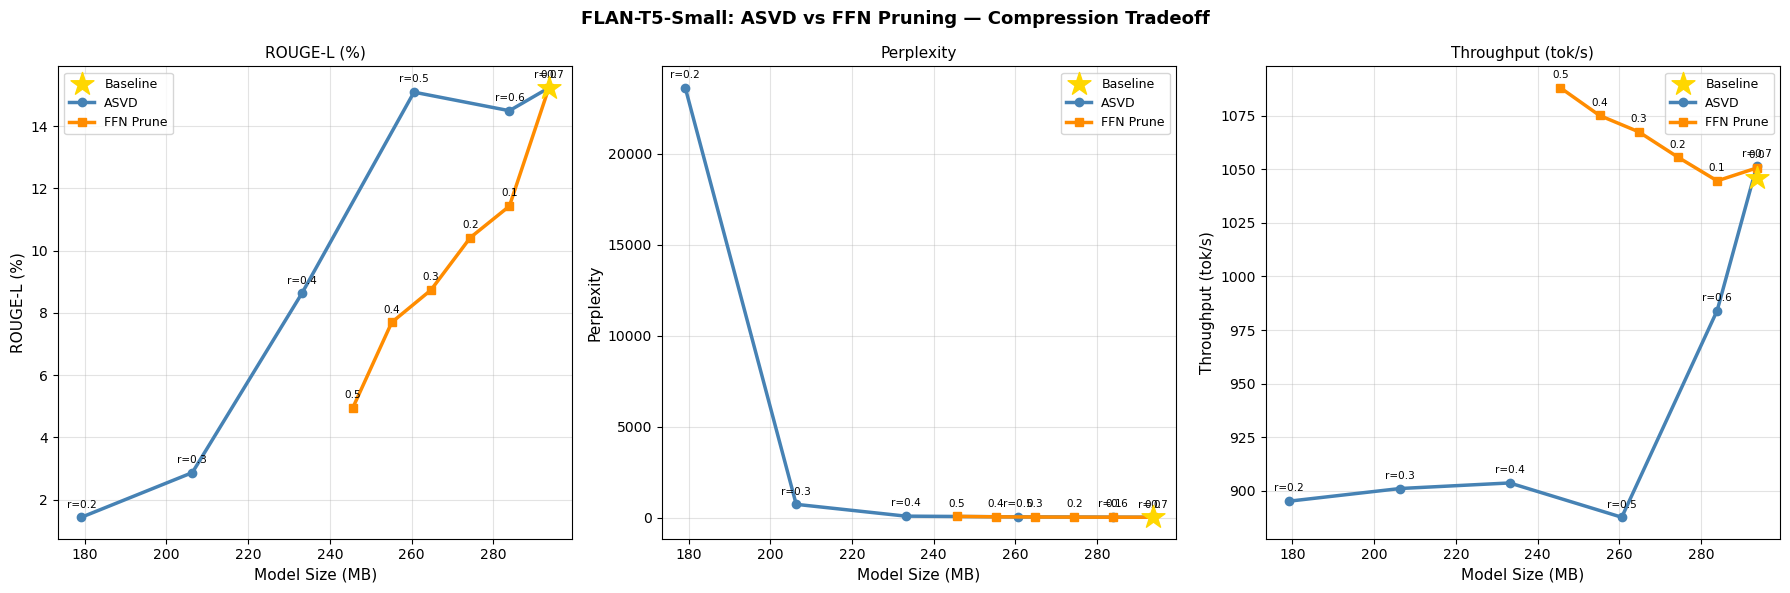

Saved: flan_t5_tradeoff.png

                method   size_MB   ROUGE-L        PPL    tok/s   ms/tok
              baseline     293.6    15.233      19.91   1045.8    0.956
            ASVD r=0.2     179.2     1.437   23626.78    895.2    1.117
            ASVD r=0.3     206.3     2.871     729.91    901.1    1.110
            ASVD r=0.4     233.2     8.631      80.74    903.7    1.107
            ASVD r=0.5     260.6    15.093      41.36    887.7    1.126
            ASVD r=0.6     283.9    14.497      26.12    984.1    1.016
            ASVD r=0.7     293.6    15.233      19.91   1051.3    0.951
         Prune amt=0.5     245.6     4.945      67.61   1088.0    0.919
         Prune amt=0.4     255.1     7.699      43.84   1075.1    0.930
         Prune amt=0.3     264.7     8.734      32.62   1067.5    0.937
         Prune amt=0.2     274.4    10.421      25.87   1055.6    0.947
         Prune amt=0.1     283.9    11.432      22.26   1044.6    0.957
         Prune amt=0.0     293.6   

In [7]:
import os, copy, time
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}


def eval_perplexity(model, tokenizer, dataset, batch_size=8, max_length=256, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch   = dataset[i:i+batch_size]
            inputs  = tokenizer(
                batch["input_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=max_length
            ).to(device)
            labels  = tokenizer(
                batch["target_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=max_length
            ).input_ids.to(device)
            labels[labels == tokenizer.pad_token_id] = -100
            out = model(**inputs, labels=labels)
            n_tokens = (labels != -100).sum().item()
            total_loss   += out.loss.item() * n_tokens
            total_tokens += n_tokens

    avg_nll = total_loss / max(total_tokens, 1)
    return float(torch.exp(torch.tensor(avg_nll)).item())


def eval_latency(model, tokenizer, dataset, n_batches=20, batch_size=4,
                 max_new_tokens=64, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    # warmup
    warmup_inputs = tokenizer(
        dataset[:batch_size]["input_text"], return_tensors="pt",
        padding=True, truncation=True, max_length=256
    ).to(device)
    with torch.no_grad():
        model.generate(**warmup_inputs, max_new_tokens=16, num_beams=1)
    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()

    total_tokens = 0
    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        for i in range(n_batches):
            idx    = (i * batch_size) % len(dataset)
            batch  = dataset[idx:idx+batch_size]
            inputs = tokenizer(
                batch["input_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=256
            ).to(device)
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=1)
            total_tokens += out.shape[0] * (out.shape[1] - 1)

    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()

    elapsed        = time.perf_counter() - start
    tokens_per_sec = total_tokens / elapsed
    ms_per_token   = (elapsed / total_tokens) * 1000
    return round(tokens_per_sec, 1), round(ms_per_token, 3)


def eval_all(model, tokenizer, sample, ppl_sample, device):
    rouge_scores            = eval_rouge(model, tokenizer, sample, device=device)
    ppl                     = eval_perplexity(model, tokenizer, ppl_sample, device=device)
    tok_per_sec, ms_per_tok = eval_latency(model, tokenizer, sample, device=device)
    return {
        "rougeL"     : rouge_scores["rougeL"] * 100,
        "ppl"        : ppl,
        "tok_per_sec": tok_per_sec,
        "ms_per_tok" : ms_per_tok,
    }


def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Main runner
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples   = 300,
    ppl_samples    = 200,
    rank_ratios    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts  = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5),
    target_modules = ("q", "k", "v", "o", "wi_0", "wi_1", "wo"),
    calib_batches  = 16,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample     = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    ppl_sample = val_dataset.select(range(min(ppl_samples,  len(val_dataset))))
    calib      = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    # ── 1. Baseline ─────────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline     = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_size    = model_size_mb(baseline)
    print("Evaluating baseline...")
    base_metrics = eval_all(baseline, tokenizer, sample, ppl_sample, device)
    print(f"[BASE] size={base_size:.1f}MB | ROUGE-L={base_metrics['rougeL']:.3f} | "
          f"PPL={base_metrics['ppl']:.2f} | {base_metrics['tok_per_sec']:.1f} tok/s")

    # ── 2. Collect activation scales ────────────────────────────────────────
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ── 3. ASVD sweep ───────────────────────────────────────────────────────
    print("\n--- ASVD sweep (fp32) ---")
    for rr in rank_ratios:
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb    = model_size_mb(asvd_model)
        metrics    = eval_all(asvd_model, tokenizer, sample, ppl_sample, device)
        asvd_points.append({"rr": rr, "size": size_mb, **metrics})
        print(f"  r={rr} | size={size_mb:.1f}MB | ROUGE-L={metrics['rougeL']:.3f} | "
              f"PPL={metrics['ppl']:.2f} | {metrics['tok_per_sec']:.1f} tok/s")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 4. Pruning sweep ────────────────────────────────────────────────────
    print("\n--- FFN Pruning sweep (fp32) ---")
    for amt in prune_amounts:
        pruned  = structured_prune_t5_ffn(baseline, amount=float(amt))
        pruned  = pruned.to(device).eval()
        size_mb = model_size_mb(pruned)
        metrics = eval_all(pruned, tokenizer, sample, ppl_sample, device)
        prune_points.append({"amt": amt, "size": size_mb, **metrics})
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={metrics['rougeL']:.3f} | "
              f"PPL={metrics['ppl']:.2f} | {metrics['tok_per_sec']:.1f} tok/s")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Sort by size
    asvd_points  = sorted(asvd_points,  key=lambda x: x["size"])
    prune_points = sorted(prune_points, key=lambda x: x["size"])

    # ── 5. Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    metrics_cfg = [
        ("rougeL",      "ROUGE-L (%)"),
        ("ppl",         "Perplexity"),
        ("tok_per_sec", "Throughput (tok/s)"),
    ]

    for ax, (key, ylabel) in zip(axes, metrics_cfg):
        ax.scatter([base_size], [base_metrics[key]],
                   marker="*", s=300, color="gold", zorder=6, label="Baseline")

        ax.plot([p["size"] for p in asvd_points], [p[key] for p in asvd_points],
                marker="o", linewidth=2.5, color="steelblue", label="ASVD")
        for p in asvd_points:
            ax.annotate(f"r={p['rr']}", (p["size"], p[key]),
                        textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7.5)

        ax.plot([p["size"] for p in prune_points], [p[key] for p in prune_points],
                marker="s", linewidth=2.5, color="darkorange", label="FFN Prune")
        for p in prune_points:
            ax.annotate(f"{p['amt']:.1f}", (p["size"], p[key]),
                        textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7.5)

        ax.set_xlabel("Model Size (MB)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f"{ylabel}", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.35)

    fig.suptitle("FLAN-T5-Small: ASVD vs FFN Pruning — Compression Tradeoff",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("flan_t5_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: flan_t5_tradeoff.png")

    # ── 6. Summary table ─────────────────────────────────────────────────────
    print("\n" + "="*90)
    print(f"{'method':>22} {'size_MB':>9} {'ROUGE-L':>9} {'PPL':>10} {'tok/s':>8} {'ms/tok':>8}")
    print("="*90)
    print(f"{'baseline':>22} {base_size:>9.1f} {base_metrics['rougeL']:>9.3f} "
          f"{base_metrics['ppl']:>10.2f} {base_metrics['tok_per_sec']:>8.1f} "
          f"{base_metrics['ms_per_tok']:>8.3f}")
    for p in asvd_points:
        print(f"{'ASVD r='+str(p['rr']):>22} {p['size']:>9.1f} {p['rougeL']:>9.3f} "
              f"{p['ppl']:>10.2f} {p['tok_per_sec']:>8.1f} {p['ms_per_tok']:>8.3f}")
    for p in prune_points:
        print(f"{'Prune amt='+str(p['amt']):>22} {p['size']:>9.1f} {p['rougeL']:>9.3f} "
              f"{p['ppl']:>10.2f} {p['tok_per_sec']:>8.1f} {p['ms_per_tok']:>8.3f}")
    print("="*90)

    return {
        "baseline"    : {"size": base_size, **base_metrics},
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = MODEL_ID,
    adapter_path  = "./flan_t5_small_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    ppl_samples   = 200,
    rank_ratios   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2),
    prune_amounts = (0.0,0.1, 0.2, 0.3, 0.4, 0.5),
)

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


Loading fp32 merged baseline...


INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/bart-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-base/aadd2ab0ae0c8268c7c9693540e9904811f36177/config.json "HTTP/1.1 200 OK"


...

  amt=0.3 | size=467.0MB | ROUGE-L=9.076 | PPL=90.27 | 1620.9 tok/s


INFO | Using default tokenizer.


  amt=0.4 | size=445.4MB | ROUGE-L=6.614 | PPL=282.09 | 1622.4 tok/s


INFO | Using default tokenizer.


  amt=0.5 | size=423.8MB | ROUGE-L=1.021 | PPL=697.66 | 1468.8 tok/s


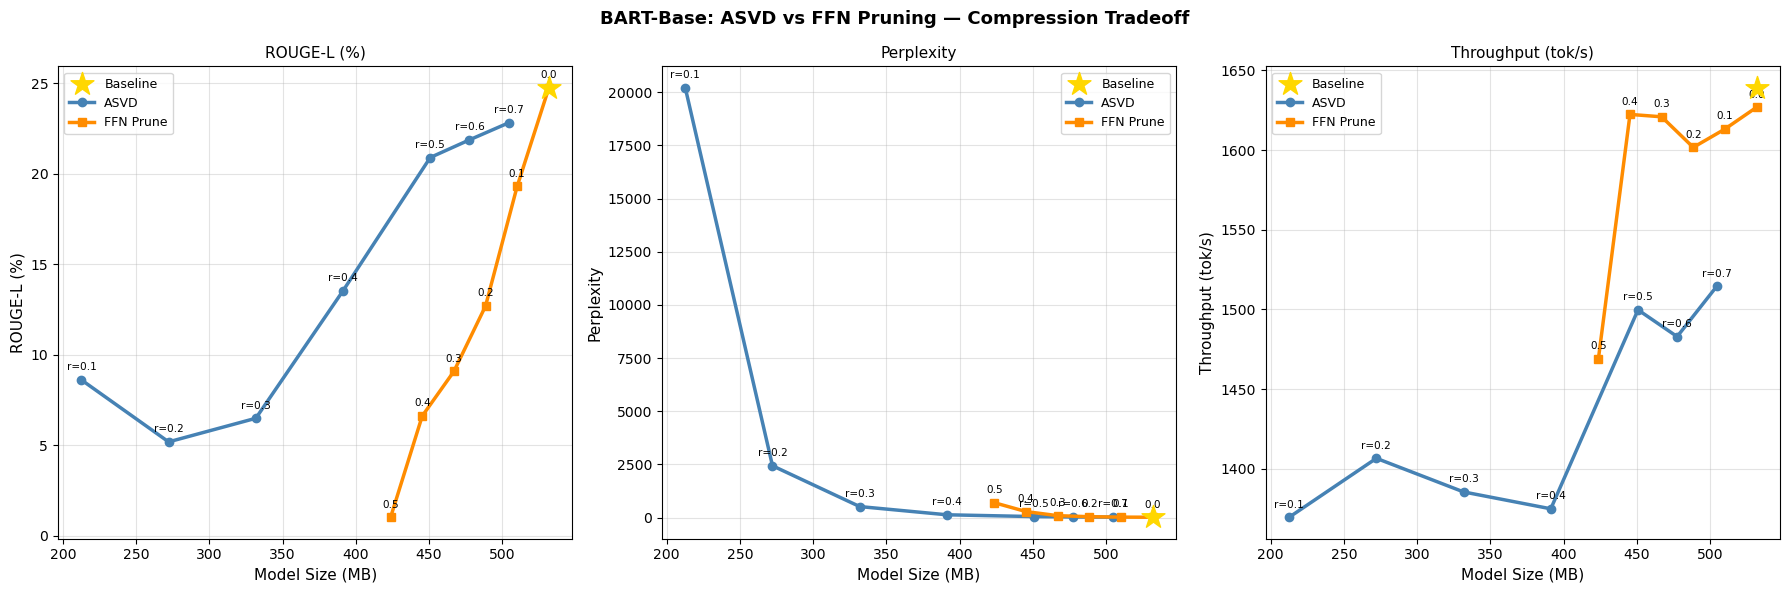

Saved: bart_base_tradeoff.png

                method   size_MB   ROUGE-L        PPL    tok/s   ms/tok
              baseline     531.8    24.742      16.41   1639.1    0.610
            ASVD r=0.1     212.6     8.607   20209.50   1369.5    0.730
            ASVD r=0.2     272.2     5.184    2436.70   1406.5    0.711
            ASVD r=0.3     331.7     6.488     518.96   1385.4    0.722
            ASVD r=0.4     391.3    13.532     132.27   1374.8    0.727
            ASVD r=0.5     450.8    20.892      47.33   1499.7    0.667
            ASVD r=0.6     477.6    21.865      29.78   1482.9    0.674
            ASVD r=0.7     504.6    22.816      22.80   1514.5    0.660
         Prune amt=0.5     423.8     1.021     697.66   1468.8    0.681
         Prune amt=0.4     445.4     6.614     282.09   1622.4    0.616
         Prune amt=0.3     467.0     9.076      90.27   1620.9    0.617
         Prune amt=0.2     488.6    12.684      42.52   1601.7    0.624
         Prune amt=0.1     510.2 

In [10]:
import os, copy, time
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}


def eval_perplexity(model, tokenizer, dataset, batch_size=8, max_length=256, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    total_loss   = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch  = dataset[i:i+batch_size]
            inputs = tokenizer(
                batch["input_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=max_length
            ).to(device)
            labels = tokenizer(
                batch["target_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=max_length
            ).input_ids.to(device)
            labels[labels == tokenizer.pad_token_id] = -100
            out      = model(**inputs, labels=labels)
            n_tokens = (labels != -100).sum().item()
            total_loss   += out.loss.item() * n_tokens
            total_tokens += n_tokens

    avg_nll = total_loss / max(total_tokens, 1)
    return float(torch.exp(torch.tensor(avg_nll)).item())


def eval_latency(model, tokenizer, dataset, n_batches=20, batch_size=4,
                 max_new_tokens=64, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    warmup_inputs = tokenizer(
        dataset[:batch_size]["input_text"], return_tensors="pt",
        padding=True, truncation=True, max_length=256
    ).to(device)
    with torch.no_grad():
        model.generate(**warmup_inputs, max_new_tokens=16, num_beams=1)
    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()

    total_tokens = 0
    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        for i in range(n_batches):
            idx    = (i * batch_size) % len(dataset)
            batch  = dataset[idx:idx+batch_size]
            inputs = tokenizer(
                batch["input_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=256
            ).to(device)
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=1)
            total_tokens += out.shape[0] * (out.shape[1] - 1)

    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()

    elapsed        = time.perf_counter() - start
    tokens_per_sec = total_tokens / elapsed
    ms_per_token   = (elapsed / total_tokens) * 1000
    return round(tokens_per_sec, 1), round(ms_per_token, 3)


def eval_all(model, tokenizer, sample, ppl_sample, device):
    rouge_scores            = eval_rouge(model, tokenizer, sample, device=device)
    ppl                     = eval_perplexity(model, tokenizer, ppl_sample, device=device)
    tok_per_sec, ms_per_tok = eval_latency(model, tokenizer, sample, device=device)
    return {
        "rougeL"     : rouge_scores["rougeL"] * 100,
        "ppl"        : ppl,
        "tok_per_sec": tok_per_sec,
        "ms_per_tok" : ms_per_tok,
    }


def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD — same logic as FLAN-T5 implementation
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning — BART (fc1 / fc2 neurons)
# =============================================================================

def structured_prune_bart_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        fc1 = getattr(module, "fc1", None)
        fc2 = getattr(module, "fc2", None)
        if fc1 is None or fc2 is None: continue

        ff_dim   = fc1.out_features
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = fc1.weight.data.norm(dim=1) + fc2.weight.data.norm(dim=0)
        keep_idx = score.topk(keep).indices.sort().values

        new_fc1 = nn.Linear(fc1.in_features, keep, bias=fc1.bias is not None)
        new_fc1.weight = nn.Parameter(fc1.weight.data[keep_idx].clone())
        if fc1.bias is not None:
            new_fc1.bias = nn.Parameter(fc1.bias.data[keep_idx].clone())
        module.fc1 = new_fc1

        new_fc2 = nn.Linear(keep, fc2.out_features, bias=fc2.bias is not None)
        new_fc2.weight = nn.Parameter(fc2.weight.data[:, keep_idx].clone())
        if fc2.bias is not None:
            new_fc2.bias = nn.Parameter(fc2.bias.data.clone())
        module.fc2 = new_fc2

    return m

# =============================================================================
# Main runner
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples   = 300,
    ppl_samples    = 200,
    rank_ratios    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts  = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5),
    target_modules = ("q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"),
    calib_batches  = 16,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample     = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    ppl_sample = val_dataset.select(range(min(ppl_samples,  len(val_dataset))))
    calib      = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    # ── 1. Baseline ─────────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline     = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_size    = model_size_mb(baseline)
    print("Evaluating baseline...")
    base_metrics = eval_all(baseline, tokenizer, sample, ppl_sample, device)
    print(f"[BASE] size={base_size:.1f}MB | ROUGE-L={base_metrics['rougeL']:.3f} | "
          f"PPL={base_metrics['ppl']:.2f} | {base_metrics['tok_per_sec']:.1f} tok/s")

    # ── 2. Collect activation scales ────────────────────────────────────────
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ── 3. ASVD sweep ───────────────────────────────────────────────────────
    print("\n--- ASVD sweep (fp32) ---")
    for rr in rank_ratios:
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb    = model_size_mb(asvd_model)
        metrics    = eval_all(asvd_model, tokenizer, sample, ppl_sample, device)
        asvd_points.append({"rr": rr, "size": size_mb, **metrics})
        print(f"  r={rr} | size={size_mb:.1f}MB | ROUGE-L={metrics['rougeL']:.3f} | "
              f"PPL={metrics['ppl']:.2f} | {metrics['tok_per_sec']:.1f} tok/s")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 4. FFN pruning sweep ─────────────────────────────────────────────────
    print("\n--- FFN Pruning sweep (fp32) ---")
    for amt in prune_amounts:
        pruned  = structured_prune_bart_ffn(baseline, amount=float(amt)).to(device).eval()
        size_mb = model_size_mb(pruned)
        metrics = eval_all(pruned, tokenizer, sample, ppl_sample, device)
        prune_points.append({"amt": amt, "size": size_mb, **metrics})
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={metrics['rougeL']:.3f} | "
              f"PPL={metrics['ppl']:.2f} | {metrics['tok_per_sec']:.1f} tok/s")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    asvd_points  = sorted(asvd_points,  key=lambda x: x["size"])
    prune_points = sorted(prune_points, key=lambda x: x["size"])

    # ── 5. Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    metrics_cfg = [
        ("rougeL",      "ROUGE-L (%)"),
        ("ppl",         "Perplexity"),
        ("tok_per_sec", "Throughput (tok/s)"),
    ]

    for ax, (key, ylabel) in zip(axes, metrics_cfg):
        ax.scatter([base_size], [base_metrics[key]],
                   marker="*", s=300, color="gold", zorder=6, label="Baseline")

        ax.plot([p["size"] for p in asvd_points], [p[key] for p in asvd_points],
                marker="o", linewidth=2.5, color="steelblue", label="ASVD")
        for p in asvd_points:
            ax.annotate(f"r={p['rr']}", (p["size"], p[key]),
                        textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7.5)

        ax.plot([p["size"] for p in prune_points], [p[key] for p in prune_points],
                marker="s", linewidth=2.5, color="darkorange", label="FFN Prune")
        for p in prune_points:
            ax.annotate(f"{p['amt']:.1f}", (p["size"], p[key]),
                        textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7.5)

        ax.set_xlabel("Model Size (MB)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(ylabel, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.35)

    fig.suptitle("BART-Base: ASVD vs FFN Pruning — Compression Tradeoff",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("bart_base_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: bart_base_tradeoff.png")

    # ── 6. Summary table ─────────────────────────────────────────────────────
    print("\n" + "="*90)
    print(f"{'method':>22} {'size_MB':>9} {'ROUGE-L':>9} {'PPL':>10} {'tok/s':>8} {'ms/tok':>8}")
    print("="*90)
    print(f"{'baseline':>22} {base_size:>9.1f} {base_metrics['rougeL']:>9.3f} "
          f"{base_metrics['ppl']:>10.2f} {base_metrics['tok_per_sec']:>8.1f} "
          f"{base_metrics['ms_per_tok']:>8.3f}")
    for p in asvd_points:
        print(f"{'ASVD r='+str(p['rr']):>22} {p['size']:>9.1f} {p['rougeL']:>9.3f} "
              f"{p['ppl']:>10.2f} {p['tok_per_sec']:>8.1f} {p['ms_per_tok']:>8.3f}")
    for p in prune_points:
        print(f"{'Prune amt='+str(p['amt']):>22} {p['size']:>9.1f} {p['rougeL']:>9.3f} "
              f"{p['ppl']:>10.2f} {p['tok_per_sec']:>8.1f} {p['ms_per_tok']:>8.3f}")
    print("="*90)

    return {
        "baseline"    : {"size": base_size, **base_metrics},
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = "facebook/bart-base",
    adapter_path  = "./bart_base_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    ppl_samples   = 200,
    rank_ratios   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5),
)

In [5]:
import os, copy, time
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}


def eval_perplexity(model, tokenizer, dataset, batch_size=8, max_length=256, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch   = dataset[i:i+batch_size]
            inputs  = tokenizer(
                batch["input_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=max_length
            ).to(device)
            labels  = tokenizer(
                batch["target_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=max_length
            ).input_ids.to(device)
            labels[labels == tokenizer.pad_token_id] = -100
            out = model(**inputs, labels=labels)
            n_tokens = (labels != -100).sum().item()
            total_loss   += out.loss.item() * n_tokens
            total_tokens += n_tokens

    avg_nll = total_loss / max(total_tokens, 1)
    return float(torch.exp(torch.tensor(avg_nll)).item())


def eval_latency(model, tokenizer, dataset, n_batches=20, batch_size=4,
                 max_new_tokens=64, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    # warmup
    warmup_inputs = tokenizer(
        dataset[:batch_size]["input_text"], return_tensors="pt",
        padding=True, truncation=True, max_length=256
    ).to(device)
    with torch.no_grad():
        model.generate(**warmup_inputs, max_new_tokens=16, num_beams=1)
    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()

    total_tokens = 0
    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        for i in range(n_batches):
            idx    = (i * batch_size) % len(dataset)
            batch  = dataset[idx:idx+batch_size]
            inputs = tokenizer(
                batch["input_text"], return_tensors="pt",
                padding=True, truncation=True, max_length=256
            ).to(device)
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=1)
            total_tokens += out.shape[0] * (out.shape[1] - 1)

    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()

    elapsed        = time.perf_counter() - start
    tokens_per_sec = total_tokens / elapsed
    ms_per_token   = (elapsed / total_tokens) * 1000
    return round(tokens_per_sec, 1), round(ms_per_token, 3)


def eval_all(model, tokenizer, sample, ppl_sample, device):
    rouge_scores            = eval_rouge(model, tokenizer, sample, device=device)
    ppl                     = eval_perplexity(model, tokenizer, ppl_sample, device=device)
    tok_per_sec, ms_per_tok = eval_latency(model, tokenizer, sample, device=device)
    return {
        "rougeL"     : rouge_scores["rougeL"] * 100,
        "ppl"        : ppl,
        "tok_per_sec": tok_per_sec,
        "ms_per_tok" : ms_per_tok,
    }


def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed


# =============================================================================
# Structured FFN pruning
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Main runner
# =============================================================================

def run_tradeoff(
    MODEL_ID,
    adapter_path,
    tokenizer,
    val_dataset,
    eval_samples   = 300,
    ppl_samples    = 200,
    rank_ratios    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    prune_amounts  = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5),
    target_modules = ("q", "k", "v", "o", "wi_0", "wi_1", "wo"),
    calib_batches  = 16,
    device         = "cuda" if torch.cuda.is_available() else "cpu",
):
    sample     = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    ppl_sample = val_dataset.select(range(min(ppl_samples,  len(val_dataset))))
    calib      = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    # ── 1. Baseline ─────────────────────────────────────────────────────────
    print("Loading fp32 merged baseline...")
    baseline     = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_size    = model_size_mb(baseline)
    print("Evaluating baseline...")
    base_metrics = eval_all(baseline, tokenizer, sample, ppl_sample, device)
    print(f"[BASE] size={base_size:.1f}MB | ROUGE-L={base_metrics['rougeL']:.3f} | "
          f"PPL={base_metrics['ppl']:.2f} | {base_metrics['tok_per_sec']:.1f} tok/s")

    # ── 2. Collect activation scales ────────────────────────────────────────
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ── 3. ASVD sweep ───────────────────────────────────────────────────────
    print("\n--- ASVD sweep (fp32) ---")
    for rr in rank_ratios:
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb    = model_size_mb(asvd_model)
        metrics    = eval_all(asvd_model, tokenizer, sample, ppl_sample, device)
        asvd_points.append({"rr": rr, "size": size_mb, **metrics})
        print(f"  r={rr} | size={size_mb:.1f}MB | ROUGE-L={metrics['rougeL']:.3f} | "
              f"PPL={metrics['ppl']:.2f} | {metrics['tok_per_sec']:.1f} tok/s")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ── 4. Pruning sweep ────────────────────────────────────────────────────
    print("\n--- FFN Pruning sweep (fp32) ---")
    for amt in prune_amounts:
        pruned  = structured_prune_t5_ffn(baseline, amount=float(amt))
        pruned  = pruned.to(device).eval()
        size_mb = model_size_mb(pruned)
        metrics = eval_all(pruned, tokenizer, sample, ppl_sample, device)
        prune_points.append({"amt": amt, "size": size_mb, **metrics})
        print(f"  amt={amt:.1f} | size={size_mb:.1f}MB | ROUGE-L={metrics['rougeL']:.3f} | "
              f"PPL={metrics['ppl']:.2f} | {metrics['tok_per_sec']:.1f} tok/s")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Sort by size
    asvd_points  = sorted(asvd_points,  key=lambda x: x["size"])
    prune_points = sorted(prune_points, key=lambda x: x["size"])

    # ── 5. Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    metrics_cfg = [
        ("rougeL",      "ROUGE-L (%)"),
        ("ppl",         "Perplexity"),
        ("tok_per_sec", "Throughput (tok/s)"),
    ]

    for ax, (key, ylabel) in zip(axes, metrics_cfg):
        ax.scatter([base_size], [base_metrics[key]],
                   marker="*", s=300, color="gold", zorder=6, label="Baseline")

        ax.plot([p["size"] for p in asvd_points], [p[key] for p in asvd_points],
                marker="o", linewidth=2.5, color="steelblue", label="ASVD")
        for p in asvd_points:
            ax.annotate(f"r={p['rr']}", (p["size"], p[key]),
                        textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7.5)

        ax.plot([p["size"] for p in prune_points], [p[key] for p in prune_points],
                marker="s", linewidth=2.5, color="darkorange", label="FFN Prune")
        for p in prune_points:
            ax.annotate(f"{p['amt']:.1f}", (p["size"], p[key]),
                        textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7.5)

        ax.set_xlabel("Model Size (MB)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f"{ylabel}", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.35)

    fig.suptitle("FLAN-T5-Small: ASVD vs FFN Pruning — Compression Tradeoff",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("flan_t5_tradeoff.png", dpi=150)
    plt.show()
    print("Saved: flan_t5_tradeoff.png")

    # ── 6. Summary table ─────────────────────────────────────────────────────
    print("\n" + "="*90)
    print(f"{'method':>22} {'size_MB':>9} {'ROUGE-L':>9} {'PPL':>10} {'tok/s':>8} {'ms/tok':>8}")
    print("="*90)
    print(f"{'baseline':>22} {base_size:>9.1f} {base_metrics['rougeL']:>9.3f} "
          f"{base_metrics['ppl']:>10.2f} {base_metrics['tok_per_sec']:>8.1f} "
          f"{base_metrics['ms_per_tok']:>8.3f}")
    for p in asvd_points:
        print(f"{'ASVD r='+str(p['rr']):>22} {p['size']:>9.1f} {p['rougeL']:>9.3f} "
              f"{p['ppl']:>10.2f} {p['tok_per_sec']:>8.1f} {p['ms_per_tok']:>8.3f}")
    for p in prune_points:
        print(f"{'Prune amt='+str(p['amt']):>22} {p['size']:>9.1f} {p['rougeL']:>9.3f} "
              f"{p['ppl']:>10.2f} {p['tok_per_sec']:>8.1f} {p['ms_per_tok']:>8.3f}")
    print("="*90)

    return {
        "baseline"    : {"size": base_size, **base_metrics},
        "asvd_points" : asvd_points,
        "prune_points": prune_points,
    }

# =============================================================================
# RUN
# =============================================================================
out = run_tradeoff(
    MODEL_ID      = MODEL_ID,
    adapter_path  = "./flan_t5_base_lora_adapter",
    tokenizer     = tokenizer,
    val_dataset   = val_dataset,
    eval_samples  = 300,
    ppl_samples   = 200,
    rank_ratios   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2),
    prune_amounts = (0.0,0.1, 0.2, 0.3, 0.4, 0.5),
)

Loading fp32 merged baseline...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Evaluating baseline...


KeyboardInterrupt: 

`torch_dtype` is deprecated! Use `dtype` instead!



  FLAN-T5-Small
Loading fp32 merged baseline...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE] size=293.6MB | ROUGE-L=15.233

  Collected scales for 144 layers over 16 batches

--- ASVD sweep ---
  [ASVD] rank_ratio=0.7 replaced=0 skipped=144
  r=0.7 | 293.6MB (100.0%) | ROUGE-L=15.233
  [ASVD] rank_ratio=0.6 replaced=48 skipped=96
  r=0.6 | 283.9MB (96.7%) | ROUGE-L=14.497
  [ASVD] rank_ratio=0.5 replaced=144 skipped=0
  r=0.5 | 260.6MB (88.8%) | ROUGE-L=15.093
  [ASVD] rank_ratio=0.4 replaced=144 skipped=0
  r=0.4 | 233.2MB (79.4%) | ROUGE-L=8.631
  [ASVD] rank_ratio=0.3 replaced=144 skipped=0
  r=0.3 | 206.3MB (70.3%) | ROUGE-L=2.871
  [ASVD] rank_ratio=0.2 replaced=144 skipped=0
  r=0.2 | 179.2MB (61.0%) | ROUGE-L=1.437
  [ASVD] rank_ratio=0.1 replaced=144 skipped=0
  r=0.1 | 152.4MB (51.9%) | ROUGE-L=0.913

--- FFN Pruning sweep ---
  amt=0.0 | 293.6MB (100.0%) | ROUGE-L=15.233
  amt=0.1 | 283.9MB (96.7%) | ROUGE-L=11.432
  amt=0.2 | 274.4MB (93.5%) | ROUGE-L=10.421
  amt=0.3 | 264.7MB (90.2%) | ROUGE-L=8.734
  amt=0.4 | 255.1MB (86.9%) | ROUGE-L=7.699
  amt=0.5 | 24

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE] size=944.4MB | ROUGE-L=16.061

  Collected scales for 216 layers over 16 batches

--- ASVD sweep ---
  [ASVD] rank_ratio=0.7 replaced=72 skipped=144
  r=0.7 | 927.8MB (98.2%) | ROUGE-L=15.674
  [ASVD] rank_ratio=0.6 replaced=72 skipped=144
  r=0.6 | 868.2MB (91.9%) | ROUGE-L=15.781
  [ASVD] rank_ratio=0.5 replaced=72 skipped=144
  r=0.5 | 809.4MB (85.7%) | ROUGE-L=14.148
  [ASVD] rank_ratio=0.4 replaced=216 skipped=0
  r=0.4 | 684.9MB (72.5%) | ROUGE-L=14.216
  [ASVD] rank_ratio=0.3 replaced=216 skipped=0
  r=0.3 | 560.4MB (59.3%) | ROUGE-L=6.715
  [ASVD] rank_ratio=0.2 replaced=216 skipped=0
  r=0.2 | 435.9MB (46.2%) | ROUGE-L=1.783
  [ASVD] rank_ratio=0.1 replaced=216 skipped=0
  r=0.1 | 311.3MB (33.0%) | ROUGE-L=2.017

--- FFN Pruning sweep ---
  amt=0.0 | 944.4MB (100.0%) | ROUGE-L=16.061
  amt=0.1 | 901.2MB (95.4%) | ROUGE-L=8.420
  amt=0.2 | 858.0MB (90.8%) | ROUGE-L=4.608
  amt=0.3 | 814.7MB (86.3%) | ROUGE-L=0.846
  amt=0.4 | 771.5MB (81.7%) | ROUGE-L=0.674
  amt=0.5 | 7

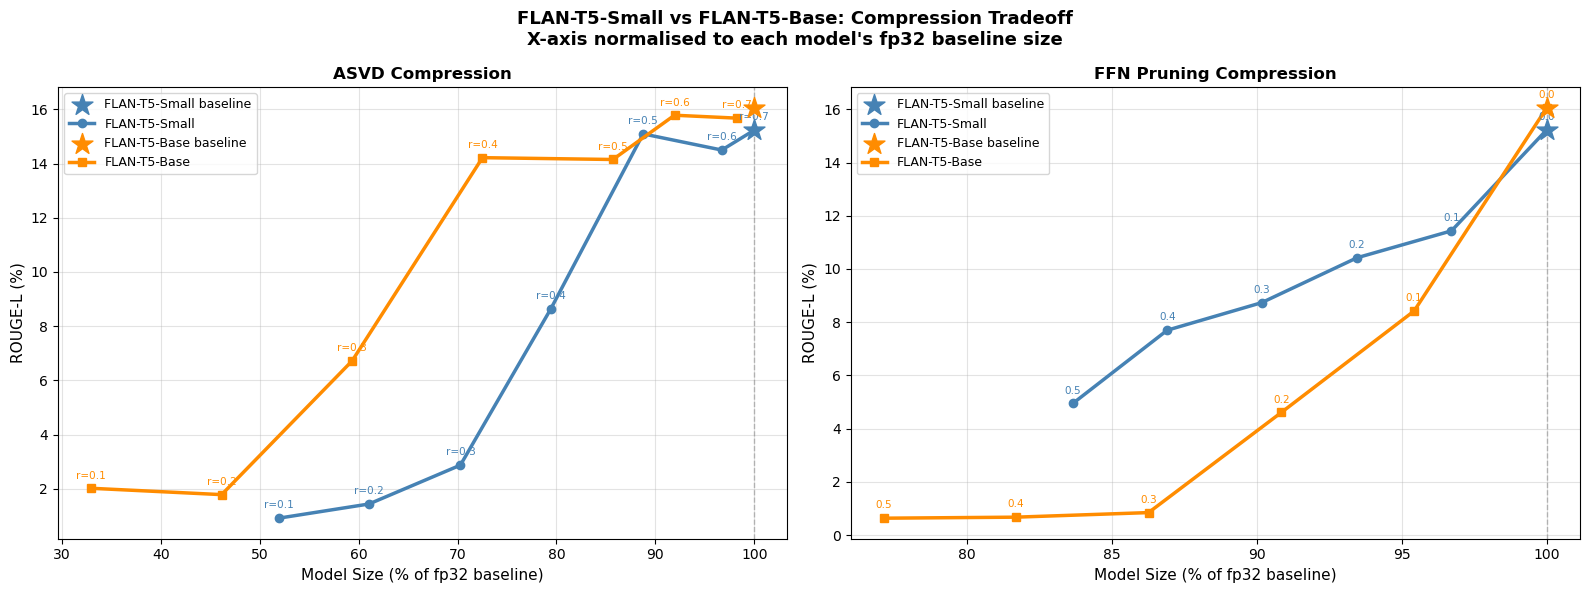

Saved: flan_t5_comparison.png


In [3]:
import os, copy, shutil
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Per-model sweep
# =============================================================================

def run_model_sweep(
    MODEL_ID,
    adapter_path,
    model_name,
    tokenizer,
    val_dataset,
    eval_samples,
    rank_ratios,
    prune_amounts,
    target_modules,
    calib_batches,
    device,
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    # Baseline
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE] size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    # Activation scales
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ASVD sweep
    print("\n--- ASVD sweep ---")
    for rr in rank_ratios:
        asvd_model  = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb     = model_size_mb(asvd_model)
        size_pct    = (size_mb / base_size) * 100
        scores      = eval_rouge(asvd_model, tokenizer, sample, device=device)
        asvd_points.append({
            "rr"      : rr,
            "size_mb" : size_mb,
            "size_pct": size_pct,
            "rougeL"  : scores["rougeL"] * 100,
        })
        print(f"  r={rr} | {size_mb:.1f}MB ({size_pct:.1f}%) | ROUGE-L={scores['rougeL']*100:.3f}")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Pruning sweep
    print("\n--- FFN Pruning sweep ---")
    for amt in prune_amounts:
        pruned   = structured_prune_t5_ffn(baseline, amount=float(amt))
        pruned   = pruned.to(device).eval()
        size_mb  = model_size_mb(pruned)
        size_pct = (size_mb / base_size) * 100
        scores   = eval_rouge(pruned, tokenizer, sample, device=device)
        prune_points.append({
            "amt"     : amt,
            "size_mb" : size_mb,
            "size_pct": size_pct,
            "rougeL"  : scores["rougeL"] * 100,
        })
        print(f"  amt={amt:.1f} | {size_mb:.1f}MB ({size_pct:.1f}%) | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    del baseline
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return {
        "model_name"  : model_name,
        "base_size"   : base_size,
        "base_rougeL" : base_scores["rougeL"] * 100,
        "asvd_points" : sorted(asvd_points,  key=lambda x: x["size_pct"]),
        "prune_points": sorted(prune_points, key=lambda x: x["size_pct"]),
    }

# =============================================================================
# Plot — two subplots: SVD | Pruning
# =============================================================================

def plot_comparison(results_small, results_base):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = {
        "FLAN-T5-Small": ("steelblue",   "o"),
        "FLAN-T5-Base" : ("darkorange",  "s"),
    }

    titles   = ["ASVD Compression",    "FFN Pruning Compression"]
    keys     = ["asvd_points",         "prune_points"]
    label_fn = [lambda p: f"r={p['rr']}", lambda p: f"{p['amt']:.1f}"]

    for ax, title, key, lbl_fn in zip(axes, titles, keys, label_fn):

        for results in [results_small, results_base]:
            name       = results["model_name"]
            color, mrk = colors[name]
            points     = results[key]

            # baseline star
            ax.scatter([100], [results["base_rougeL"]],
                       marker="*", s=250, color=color, zorder=6,
                       label=f"{name} baseline")

            ax.plot(
                [p["size_pct"] for p in points],
                [p["rougeL"]   for p in points],
                marker=mrk, linewidth=2.5, color=color,
                label=name,
            )
            for p in points:
                ax.annotate(lbl_fn(p), (p["size_pct"], p["rougeL"]),
                            textcoords="offset points", xytext=(0, 7),
                            ha="center", fontsize=7.5, color=color)

        ax.axvline(x=100, color="gray", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_xlabel("Model Size (% of fp32 baseline)", fontsize=11)
        ax.set_ylabel("ROUGE-L (%)", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.35)

    fig.suptitle(
        "FLAN-T5-Small vs FLAN-T5-Base: Compression Tradeoff\n"
        "X-axis normalised to each model's fp32 baseline size",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("flan_t5_comparison.png", dpi=150)
    plt.show()
    print("Saved: flan_t5_comparison.png")

# =============================================================================
# RUN
# =============================================================================

TARGET_MODULES = ("q", "k", "v", "o", "wi_0", "wi_1", "wo")
RANK_RATIOS    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1)
PRUNE_AMOUNTS  = (0.0,0.1, 0.2, 0.3, 0.4, 0.5)
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"

results_small = run_model_sweep(
    MODEL_ID       = "google/flan-t5-small",
    adapter_path   = "./flan_t5_small_lora_adapter",
    model_name     = "FLAN-T5-Small",
    tokenizer      = tokenizer,
    val_dataset    = val_dataset,
    eval_samples   = 300,
    rank_ratios    = RANK_RATIOS,
    prune_amounts  = PRUNE_AMOUNTS,
    target_modules = TARGET_MODULES,
    calib_batches  = 16,
    device         = DEVICE,
)

results_base = run_model_sweep(
    MODEL_ID       = "google/flan-t5-base",
    adapter_path   = "./flan_t5_base_lora_adapter",
    model_name     = "FLAN-T5-Base",
    tokenizer      = tokenizer,
    val_dataset    = val_dataset,
    eval_samples   = 300,
    rank_ratios    = RANK_RATIOS,
    prune_amounts  = PRUNE_AMOUNTS,
    target_modules = TARGET_MODULES,
    calib_batches  = 16,
    device         = DEVICE,
)

plot_comparison(results_small, results_base)

In [13]:
import os, copy, torch, torch.nn as nn, matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

nltk.download("punkt", quiet=True)
rouge = evaluate.load("rouge")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =============================================================================
# Utilities
# =============================================================================
def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None: device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(batch["input_text"], return_tensors="pt",
                           padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    return {k: float(v) for k, v in rouge.compute(predictions=preds, references=refs, use_stemmer=True).items()}

def load_merged_fp32(MODEL_ID, adapter_path, device=DEVICE):
    base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1: setattr(obj, parts[0], value)
    else: recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD for T5/BART
# =============================================================================
class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))
        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)
        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None: self.A.bias.data.copy_(original.bias.data)
        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x): return self.A(self.B(x))

def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval(); scales, counts, hooks = {}, {}, {}
    def make_hook(name):
        def hook_fn(module, inp, out):
            x = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales: scales[name]=rms; counts[name]=1
            else: counts[name]+=1; scales[name]+=(rms-scales[name])/counts[name]
        return hook_fn
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))
    with torch.no_grad():
        for i in range(num_batches):
            start = i*8
            if start >= len(calib_dataset): break
            batch = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt", padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt", padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass
    for h in hooks.values(): h.remove()
    return scales

def apply_asvd(source_model, scales, target_modules, rank_ratio, device=DEVICE):
    compressed = copy.deepcopy(source_model); replaced=skipped=0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped+=1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank*(in_f+out_f) >= out_f*in_f: skipped+=1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced+=1
    return compressed

# =============================================================================
# FFN pruning
# =============================================================================
def structured_prune_t5_ffn(model, amount):
    m = copy.deepcopy(model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo", None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        keep = max(1, int(wi0.weight.shape[0]*(1-amount)))
        score = wi0.weight.data.norm(dim=1)+wi1.weight.data.norm(dim=1)
        idx = score.topk(keep).indices.sort().values
        module.wi_0 = nn.Linear(wi0.in_features, len(idx), bias=wi0.bias is not None)
        module.wi_0.weight.data = wi0.weight.data[idx].clone()
        if wi0.bias is not None: module.wi_0.bias.data = wi0.bias.data[idx].clone()
        module.wi_1 = nn.Linear(wi1.in_features, len(idx), bias=wi1.bias is not None)
        module.wi_1.weight.data = wi1.weight.data[idx].clone()
        if wi1.bias is not None: module.wi_1.bias.data = wi1.bias.data[idx].clone()
        module.wo   = nn.Linear(len(idx), wo.out_features, bias=wo.bias is not None)
        module.wo.weight.data = wo.weight.data[:, idx].clone()
        if wo.bias is not None: module.wo.bias.data = wo.bias.data.clone()
    return m

def structured_prune_bart_ffn(model, amount):
    m = copy.deepcopy(model).cpu().eval()
    for _, module in m.named_modules():
        fc1 = getattr(module, "fc1", None)
        fc2 = getattr(module, "fc2", None)
        if fc1 is None or fc2 is None: continue
        keep = max(1, int(fc1.out_features*(1-amount)))
        score = fc1.weight.data.norm(dim=1)+fc2.weight.data.norm(dim=0)
        idx = score.topk(keep).indices.sort().values
        new_fc1 = nn.Linear(fc1.in_features, keep, bias=fc1.bias is not None)
        new_fc1.weight.data = fc1.weight.data[idx].clone()
        if fc1.bias is not None: new_fc1.bias.data = fc1.bias.data[idx].clone()
        module.fc1 = new_fc1
        new_fc2 = nn.Linear(keep, fc2.out_features, bias=fc2.bias is not None)
        new_fc2.weight.data = fc2.weight.data[:, idx].clone()
        if fc2.bias is not None: new_fc2.bias.data = fc2.bias.data.clone()
        module.fc2 = new_fc2
    return m

# =============================================================================
# Combined sweep
# =============================================================================
def run_sweep(model_id, adapter_path, model_name, tokenizer, val_dataset, rank_ratios, prune_amounts, target_modules, calib_batches, device):
    sample = val_dataset.select(range(min(300,len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches*8,len(val_dataset))))
    baseline = load_merged_fp32(model_id, adapter_path, device=device)
    base_size = model_size_mb(baseline)
    base_rl   = eval_rouge(baseline, tokenizer, sample, device=device)["rougeL"]*100
    scales = collect_activation_scales(baseline, tokenizer, calib, target_modules, device=device, num_batches=calib_batches)
    asvd_points, prune_points = [], []

    # ASVD
    for rr in rank_ratios:
        model_r = apply_asvd(baseline, scales, target_modules, rr, device)
        asvd_points.append((rr, model_size_mb(model_r), eval_rouge(model_r, tokenizer, sample, device=device)["rougeL"]*100))
        del model_r; torch.cuda.empty_cache()

    # FFN pruning
    prune_fn = structured_prune_t5_ffn if "T5" in model_name else structured_prune_bart_ffn
    for amt in prune_amounts:
        pruned = prune_fn(baseline, amt)
        prune_points.append((amt, model_size_mb(pruned), eval_rouge(pruned, tokenizer, sample, device=device)["rougeL"]*100))
        del pruned; torch.cuda.empty_cache()

    del baseline; torch.cuda.empty_cache()
    return {"name": model_name, "base_size": base_size, "base_rl": base_rl, "asvd": asvd_points, "prune": prune_points}

# =============================================================================
# Plot combined
# =============================================================================
def plot_all(results):
    plt.figure(figsize=(12,6))
    colors = {"FLAN-T5-Small":"steelblue","FLAN-T5-Base":"darkorange","BART-Base":"green"}
    markers = {"FLAN-T5-Small":"o","FLAN-T5-Base":"s","BART-Base":"D"}
    for r in results:
        plt.scatter([r["base_size"]],[r["base_rl"]], marker="*", s=250, color=colors[r["name"]], label=f"{r['name']} baseline")
        plt.plot([x[1] for x in r["asvd"]],[x[2] for x in r["asvd"]], marker=markers[r["name"]], color=colors[r["name"]], linewidth=2, label=f"{r['name']} ASVD")
        plt.plot([x[1] for x in r["prune"]],[x[2] for x in r["prune"]], marker=markers[r["name"]], linestyle="--", color=colors[r["name"]], linewidth=2, label=f"{r['name']} FFN Prune")
    plt.xlabel("Model Size (MB)")
    plt.ylabel("ROUGE-L (%)")
    plt.title("Compression Tradeoff: FLAN-T5-Small / FLAN-T5-Base / BART-Base")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =============================================================================
# RUN for all 3 models
# =============================================================================
TARGET_MODULES_T5  = ("q","k","v","o","wi_0","wi_1","wo")
TARGET_MODULES_BART = ("fc1","fc2")

RANK_RATIOS   = (0.7,0.6,0.5,0.4,0.3,0.2,0.1)
PRUNE_AMOUNTS = (0.0,0.1,0.2,0.3,0.4,0.5)

results_small = run_sweep("google/flan-t5-small","./flan_t5_small_lora_adapter","FLAN-T5-Small",tokenizer,val_dataset,RANK_RATIOS,PRUNE_AMOUNTS,TARGET_MODULES_T5,16,DEVICE)
results_base  = run_sweep("google/flan-t5-base","./flan_t5_base_lora_adapter","FLAN-T5-Base",tokenizer,val_dataset,RANK_RATIOS,PRUNE_AMOUNTS,TARGET_MODULES_T5,16,DEVICE)
results_bart  = run_sweep("facebook/bart-base","./bart_base_lora_adapter","BART-Base",tokenizer,val_dataset,RANK_RATIOS,PRUNE_AMOUNTS,TARGET_MODULES_BART,16,DEVICE)

plot_all([results_small, results_base, results_bart])

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



  FLAN-T5-Small
Loading fp32 merged baseline...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE] size=293.6MB | ROUGE-L=15.233

  Collected scales for 144 layers over 16 batches

--- ASVD sweep ---
  [ASVD] rank_ratio=0.7 replaced=0 skipped=144
  r=0.7 | 293.6MB (100.0%) | ROUGE-L=15.233
  [ASVD] rank_ratio=0.6 replaced=48 skipped=96
  r=0.6 | 283.9MB (96.7%) | ROUGE-L=14.497
  [ASVD] rank_ratio=0.5 replaced=144 skipped=0
  r=0.5 | 260.6MB (88.8%) | ROUGE-L=15.093
  [ASVD] rank_ratio=0.4 replaced=144 skipped=0
  r=0.4 | 233.2MB (79.4%) | ROUGE-L=8.631
  [ASVD] rank_ratio=0.3 replaced=144 skipped=0
  r=0.3 | 206.3MB (70.3%) | ROUGE-L=2.871
  [ASVD] rank_ratio=0.2 replaced=144 skipped=0
  r=0.2 | 179.2MB (61.0%) | ROUGE-L=1.437
  [ASVD] rank_ratio=0.1 replaced=144 skipped=0
  r=0.1 | 152.4MB (51.9%) | ROUGE-L=0.913

--- FFN Pruning sweep ---
  amt=0.0 | 293.6MB (100.0%) | ROUGE-L=15.233
  amt=0.1 | 283.9MB (96.7%) | ROUGE-L=11.432
  amt=0.2 | 274.4MB (93.5%) | ROUGE-L=10.421
  amt=0.3 | 264.7MB (90.2%) | ROUGE-L=8.734
  amt=0.4 | 255.1MB (86.9%) | ROUGE-L=7.699
  amt=0.5 | 24

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE] size=944.4MB | ROUGE-L=16.061

  Collected scales for 216 layers over 16 batches

--- ASVD sweep ---
  [ASVD] rank_ratio=0.7 replaced=72 skipped=144
  r=0.7 | 927.8MB (98.2%) | ROUGE-L=15.674
  [ASVD] rank_ratio=0.6 replaced=72 skipped=144
  r=0.6 | 868.2MB (91.9%) | ROUGE-L=15.781
  [ASVD] rank_ratio=0.5 replaced=72 skipped=144
  r=0.5 | 809.4MB (85.7%) | ROUGE-L=14.148
  [ASVD] rank_ratio=0.4 replaced=216 skipped=0
  r=0.4 | 684.9MB (72.5%) | ROUGE-L=14.216
  [ASVD] rank_ratio=0.3 replaced=216 skipped=0
  r=0.3 | 560.4MB (59.3%) | ROUGE-L=6.715
  [ASVD] rank_ratio=0.2 replaced=216 skipped=0
  r=0.2 | 435.9MB (46.2%) | ROUGE-L=1.783
  [ASVD] rank_ratio=0.1 replaced=216 skipped=0
  r=0.1 | 311.3MB (33.0%) | ROUGE-L=2.017

--- FFN Pruning sweep ---
  amt=0.0 | 944.4MB (100.0%) | ROUGE-L=16.061
  amt=0.1 | 901.2MB (95.4%) | ROUGE-L=8.420
  amt=0.2 | 858.0MB (90.8%) | ROUGE-L=4.608
  amt=0.3 | 814.7MB (86.3%) | ROUGE-L=0.846
  amt=0.4 | 771.5MB (81.7%) | ROUGE-L=0.674
  amt=0.5 | 7

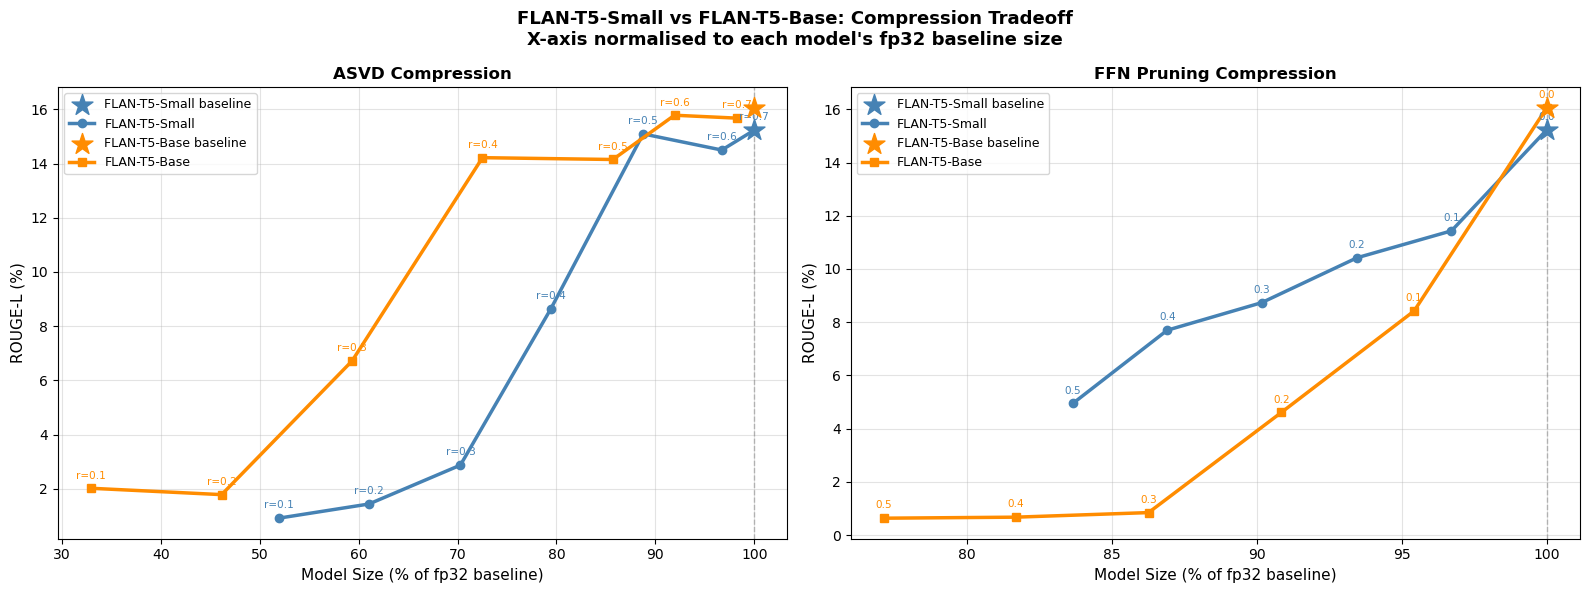

Saved: flan_t5_comparison.png


In [5]:
import os, copy, shutil
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Per-model sweep
# =============================================================================

def run_model_sweep(
    MODEL_ID,
    adapter_path,
    model_name,
    tokenizer,
    val_dataset,
    eval_samples,
    rank_ratios,
    prune_amounts,
    target_modules,
    calib_batches,
    device,
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    # Baseline
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE] size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    # Activation scales
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ASVD sweep
    print("\n--- ASVD sweep ---")
    for rr in rank_ratios:
        asvd_model  = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb     = model_size_mb(asvd_model)
        size_pct    = (size_mb / base_size) * 100
        scores      = eval_rouge(asvd_model, tokenizer, sample, device=device)
        asvd_points.append({
            "rr"      : rr,
            "size_mb" : size_mb,
            "size_pct": size_pct,
            "rougeL"  : scores["rougeL"] * 100,
        })
        print(f"  r={rr} | {size_mb:.1f}MB ({size_pct:.1f}%) | ROUGE-L={scores['rougeL']*100:.3f}")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Pruning sweep
    print("\n--- FFN Pruning sweep ---")
    for amt in prune_amounts:
        pruned   = structured_prune_t5_ffn(baseline, amount=float(amt))
        pruned   = pruned.to(device).eval()
        size_mb  = model_size_mb(pruned)
        size_pct = (size_mb / base_size) * 100
        scores   = eval_rouge(pruned, tokenizer, sample, device=device)
        prune_points.append({
            "amt"     : amt,
            "size_mb" : size_mb,
            "size_pct": size_pct,
            "rougeL"  : scores["rougeL"] * 100,
        })
        print(f"  amt={amt:.1f} | {size_mb:.1f}MB ({size_pct:.1f}%) | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    del baseline
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return {
        "model_name"  : model_name,
        "base_size"   : base_size,
        "base_rougeL" : base_scores["rougeL"] * 100,
        "asvd_points" : sorted(asvd_points,  key=lambda x: x["size_pct"]),
        "prune_points": sorted(prune_points, key=lambda x: x["size_pct"]),
    }

# =============================================================================
# Plot — two subplots: SVD | Pruning
# =============================================================================

def plot_comparison(results_small, results_base):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = {
        "FLAN-T5-Small": ("steelblue",   "o"),
        "FLAN-T5-Base" : ("darkorange",  "s"),
    }

    titles   = ["ASVD Compression",    "FFN Pruning Compression"]
    keys     = ["asvd_points",         "prune_points"]
    label_fn = [lambda p: f"r={p['rr']}", lambda p: f"{p['amt']:.1f}"]

    for ax, title, key, lbl_fn in zip(axes, titles, keys, label_fn):

        for results in [results_small, results_base]:
            name       = results["model_name"]
            color, mrk = colors[name]
            points     = results[key]

            # baseline star
            ax.scatter([100], [results["base_rougeL"]],
                       marker="*", s=250, color=color, zorder=6,
                       label=f"{name} baseline")

            ax.plot(
                [p["size_pct"] for p in points],
                [p["rougeL"]   for p in points],
                marker=mrk, linewidth=2.5, color=color,
                label=name,
            )
            for p in points:
                ax.annotate(lbl_fn(p), (p["size_pct"], p["rougeL"]),
                            textcoords="offset points", xytext=(0, 7),
                            ha="center", fontsize=7.5, color=color)

        ax.axvline(x=100, color="gray", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_xlabel("Model Size (% of fp32 baseline)", fontsize=11)
        ax.set_ylabel("ROUGE-L (%)", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.35)

    fig.suptitle(
        "FLAN-T5-Small vs FLAN-T5-Base: Compression Tradeoff\n"
        "X-axis normalised to each model's fp32 baseline size",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("flan_t5_comparison.png", dpi=150)
    plt.show()
    print("Saved: flan_t5_comparison.png")

# =============================================================================
# RUN
# =============================================================================

TARGET_MODULES = ("q", "k", "v", "o", "wi_0", "wi_1", "wo")
RANK_RATIOS    = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1)
PRUNE_AMOUNTS  = (0.0,0.1, 0.2, 0.3, 0.4, 0.5)
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"

results_small = run_model_sweep(
    MODEL_ID       = "google/flan-t5-small",
    adapter_path   = "./flan_t5_small_lora_adapter",
    model_name     = "FLAN-T5-Small",
    tokenizer      = tokenizer,
    val_dataset    = val_dataset,
    eval_samples   = 300,
    rank_ratios    = RANK_RATIOS,
    prune_amounts  = PRUNE_AMOUNTS,
    target_modules = TARGET_MODULES,
    calib_batches  = 16,
    device         = DEVICE,
)

results_base = run_model_sweep(
    MODEL_ID       = "google/flan-t5-base",
    adapter_path   = "./flan_t5_base_lora_adapter",
    model_name     = "FLAN-T5-Base",
    tokenizer      = tokenizer,
    val_dataset    = val_dataset,
    eval_samples   = 300,
    rank_ratios    = RANK_RATIOS,
    prune_amounts  = PRUNE_AMOUNTS,
    target_modules = TARGET_MODULES,
    calib_batches  = 16,
    device         = DEVICE,
)

plot_comparison(results_small, results_base)

In [6]:
import gc
[k for k, v in globals().items() if hasattr(v, 'parameters') and callable(getattr(v, 'parameters', None))]

['PeftModel', 'ASVDLinear', 'model']


  FLAN-T5-Small
Loading fp32 merged baseline...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE] size=293.6MB | ROUGE-L=15.233

  Collected scales for 144 layers over 16 batches

--- ASVD sweep ---
  [ASVD] rank_ratio=0.7 replaced=0 skipped=144
  r=0.7 | 293.6MB (100.0%) | ROUGE-L=15.233
  [ASVD] rank_ratio=0.6 replaced=48 skipped=96
  r=0.6 | 283.9MB (96.7%) | ROUGE-L=14.497
  [ASVD] rank_ratio=0.5 replaced=144 skipped=0
  r=0.5 | 260.6MB (88.8%) | ROUGE-L=15.093
  [ASVD] rank_ratio=0.4 replaced=144 skipped=0
  r=0.4 | 233.2MB (79.4%) | ROUGE-L=8.631
  [ASVD] rank_ratio=0.3 replaced=144 skipped=0
  r=0.3 | 206.3MB (70.3%) | ROUGE-L=2.871
  [ASVD] rank_ratio=0.2 replaced=144 skipped=0
  r=0.2 | 179.2MB (61.0%) | ROUGE-L=1.437
  [ASVD] rank_ratio=0.1 replaced=144 skipped=0
  r=0.1 | 152.4MB (51.9%) | ROUGE-L=0.913

--- FFN Pruning sweep ---
  amt=0.0 | 293.6MB (100.0%) | ROUGE-L=15.233
  amt=0.1 | 283.9MB (96.7%) | ROUGE-L=11.432
  amt=0.2 | 274.4MB (93.5%) | ROUGE-L=10.421
  amt=0.3 | 264.7MB (90.2%) | ROUGE-L=8.734
  amt=0.4 | 255.1MB (86.9%) | ROUGE-L=7.699
  amt=0.5 | 24

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[BASE] size=944.4MB | ROUGE-L=16.061

  Collected scales for 216 layers over 16 batches

--- ASVD sweep ---
  [ASVD] rank_ratio=0.7 replaced=72 skipped=144
  r=0.7 | 927.8MB (98.2%) | ROUGE-L=15.674
  [ASVD] rank_ratio=0.6 replaced=72 skipped=144
  r=0.6 | 868.2MB (91.9%) | ROUGE-L=15.781
  [ASVD] rank_ratio=0.5 replaced=72 skipped=144
  r=0.5 | 809.4MB (85.7%) | ROUGE-L=14.148
  [ASVD] rank_ratio=0.4 replaced=216 skipped=0
  r=0.4 | 684.9MB (72.5%) | ROUGE-L=14.216
  [ASVD] rank_ratio=0.3 replaced=216 skipped=0
  r=0.3 | 560.4MB (59.3%) | ROUGE-L=6.715
  [ASVD] rank_ratio=0.2 replaced=216 skipped=0
  r=0.2 | 435.9MB (46.2%) | ROUGE-L=1.783
  [ASVD] rank_ratio=0.1 replaced=216 skipped=0
  r=0.1 | 311.3MB (33.0%) | ROUGE-L=2.017

--- FFN Pruning sweep ---
  amt=0.0 | 944.4MB (100.0%) | ROUGE-L=16.061
  amt=0.1 | 901.2MB (95.4%) | ROUGE-L=8.420
  amt=0.2 | 858.0MB (90.8%) | ROUGE-L=4.608
  amt=0.3 | 814.7MB (86.3%) | ROUGE-L=0.846
  amt=0.4 | 771.5MB (81.7%) | ROUGE-L=0.674
  amt=0.5 | 7

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[BASE] size=531.8MB | ROUGE-L=25.412

  Collected scales for 96 layers over 16 batches

--- ASVD sweep ---
  [ASVD] rank_ratio=0.7 replaced=24 skipped=72
  r=0.7 | 504.6MB (94.9%) | ROUGE-L=23.768
  [ASVD] rank_ratio=0.6 replaced=24 skipped=72
  r=0.6 | 477.6MB (89.8%) | ROUGE-L=21.709
  [ASVD] rank_ratio=0.5 replaced=24 skipped=72
  r=0.5 | 450.8MB (84.8%) | ROUGE-L=20.299
  [ASVD] rank_ratio=0.4 replaced=96 skipped=0
  r=0.4 | 391.3MB (73.6%) | ROUGE-L=13.866
  [ASVD] rank_ratio=0.3 replaced=96 skipped=0
  r=0.3 | 331.7MB (62.4%) | ROUGE-L=6.595
  [ASVD] rank_ratio=0.2 replaced=96 skipped=0
  r=0.2 | 272.2MB (51.2%) | ROUGE-L=5.450
  [ASVD] rank_ratio=0.1 replaced=96 skipped=0
  r=0.1 | 212.6MB (40.0%) | ROUGE-L=8.707

--- FFN Pruning sweep ---
  amt=0.0 | 531.8MB (100.0%) | ROUGE-L=25.412
  amt=0.1 | 510.2MB (95.9%) | ROUGE-L=19.626
  amt=0.2 | 488.6MB (91.9%) | ROUGE-L=12.684
  amt=0.3 | 467.0MB (87.8%) | ROUGE-L=9.417
  amt=0.4 | 445.4MB (83.7%) | ROUGE-L=6.866
  amt=0.5 | 423.8MB

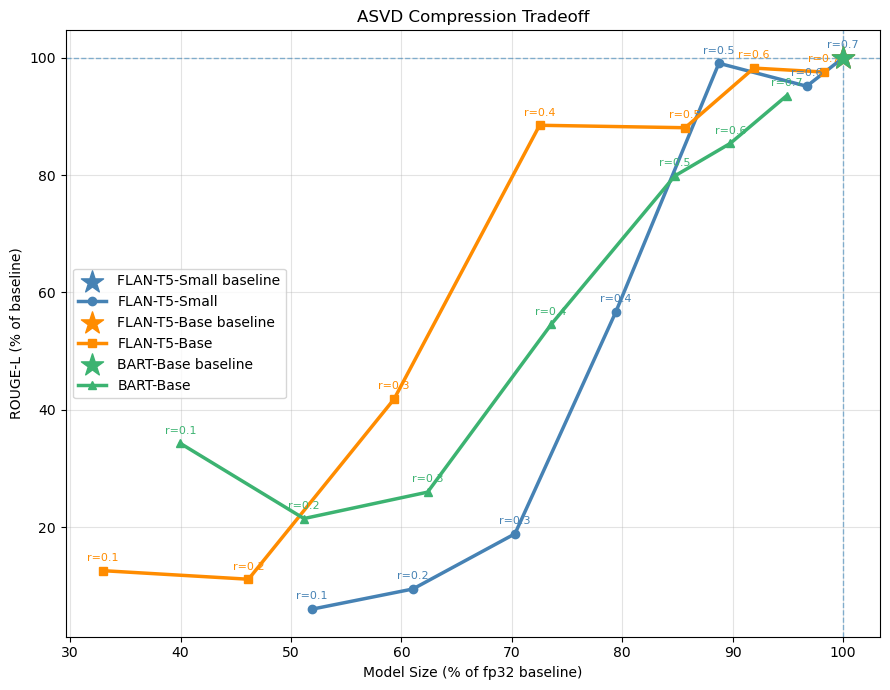

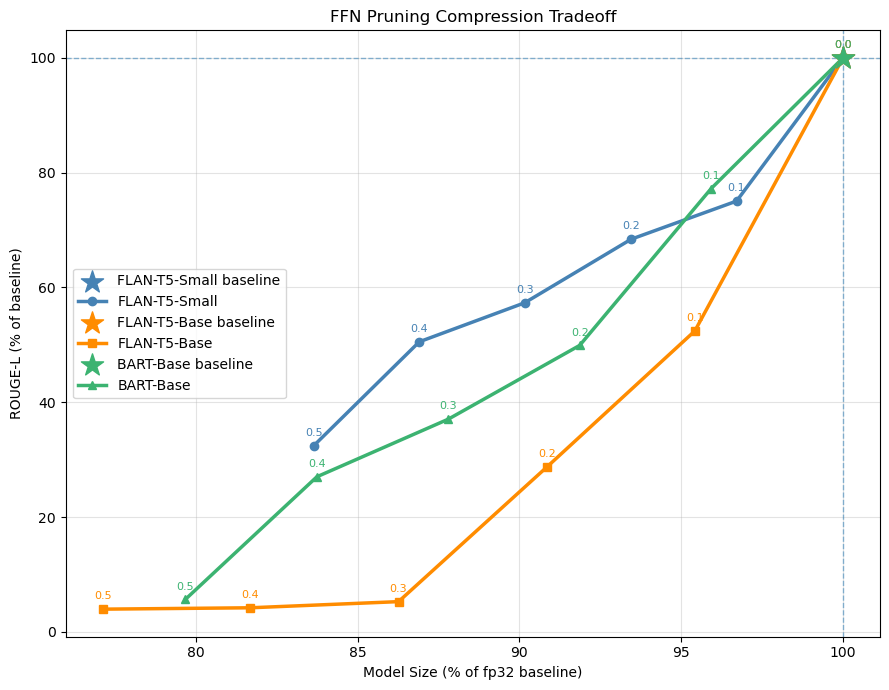

Saved: asvd_tradeoff.png, pruning_tradeoff.png


In [13]:
import os, copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import evaluate, nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt", quiet=True)

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

rouge = evaluate.load("rouge")

# =============================================================================
# Utilities
# =============================================================================

def model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)

def eval_rouge(model, tokenizer, dataset, batch_size=8, max_new_tokens=128, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        preds.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
        refs.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(v) for k, v in scores.items()}

def load_merged_fp32(MODEL_ID, adapter_path, device="cuda"):
    base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32, device_map=device)
    merged = PeftModel.from_pretrained(base, adapter_path).merge_and_unload()
    return merged.to(device).eval()

def recursive_setattr(obj, attr, value):
    parts = attr.split(".", 1)
    if len(parts) == 1:
        setattr(obj, parts[0], value)
    else:
        recursive_setattr(getattr(obj, parts[0]), parts[1], value)

# =============================================================================
# ASVD — shared by all three models
# =============================================================================

class ASVDLinear(nn.Module):
    def __init__(self, original: nn.Linear, rank: int, scale: torch.Tensor):
        super().__init__()
        out_f, in_f = original.weight.shape
        rank = min(rank, min(out_f, in_f))

        with torch.no_grad():
            W = original.weight.detach().float()
            s = scale.float().to(W.device).clamp(min=1e-6)
            U, S, Vh = torch.linalg.svd(W * s.unsqueeze(0), full_matrices=False)
            r = min(rank, S.numel())
            S_sqrt = torch.sqrt(S[:r])
            A_w = U[:, :r] * S_sqrt.unsqueeze(0)
            B_w = (S_sqrt.unsqueeze(1) * Vh[:r, :]) / s.unsqueeze(0)

        self.B = nn.Linear(in_f, rank, bias=False)
        self.A = nn.Linear(rank, out_f, bias=(original.bias is not None))
        self.B.weight.data.copy_(B_w.to(original.weight.dtype))
        self.A.weight.data.copy_(A_w.to(original.weight.dtype))
        if original.bias is not None:
            self.A.bias.data.copy_(original.bias.data)

        self.weight = self.A.weight
        self.bias   = self.A.bias

    def forward(self, x):
        return self.A(self.B(x))


def collect_activation_scales(model, tokenizer, calib_dataset, target_modules, device, num_batches=16):
    model.eval()
    scales, counts, hooks = {}, {}, {}

    def make_hook(name):
        def hook_fn(module, inp, out):
            x   = inp[0].detach().float()
            rms = x.pow(2).mean(dim=list(range(x.dim() - 1))).sqrt().cpu()
            if name not in scales:
                scales[name] = rms; counts[name] = 1
            else:
                counts[name] += 1
                scales[name] += (rms - scales[name]) / counts[name]
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith("." + t) for t in target_modules):
            hooks[name] = module.register_forward_hook(make_hook(name))

    with torch.no_grad():
        for i in range(num_batches):
            start = i * 8
            if start >= len(calib_dataset): break
            batch  = calib_dataset[start:start+8]
            inputs = tokenizer(batch["input_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=256).to(device)
            labels = tokenizer(batch["target_text"], return_tensors="pt",
                               padding=True, truncation=True, max_length=128).input_ids.to(device)
            try: model(**inputs, labels=labels)
            except Exception: pass

    for h in hooks.values(): h.remove()
    print(f"  Collected scales for {len(scales)} layers over {num_batches} batches")
    return scales


def apply_asvd(source_model, scales, target_modules, rank_ratio, device="cuda"):
    compressed = copy.deepcopy(source_model)
    replaced = skipped = 0
    for name, module in source_model.named_modules():
        if not isinstance(module, nn.Linear): continue
        if not any(name.endswith("." + t) for t in target_modules): continue
        if name not in scales: skipped += 1; continue
        out_f, in_f = module.weight.shape
        rank = max(1, int(min(out_f, in_f) * rank_ratio))
        if rank * (in_f + out_f) >= out_f * in_f: skipped += 1; continue
        layer = ASVDLinear(module, rank, scales[name].cpu())
        recursive_setattr(compressed, name, layer.to(device))
        replaced += 1
    print(f"  [ASVD] rank_ratio={rank_ratio} replaced={replaced} skipped={skipped}")
    return compressed

# =============================================================================
# Structured FFN pruning — T5 variant (wi_0 / wi_1 / wo)
# =============================================================================

def structured_prune_t5_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        wo  = getattr(module, "wo",   None)
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)
        if wo is None or wi0 is None or wi1 is None: continue
        ff_dim   = wi0.weight.data.shape[0]
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
        keep_idx = score.topk(keep).indices.sort().values

        def prune_wi(layer, idx):
            new = nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data[idx].clone())
            return new

        def prune_wo_cols(layer, idx):
            new = nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
            new.weight = nn.Parameter(layer.weight.data[:, idx].clone())
            if layer.bias is not None: new.bias = nn.Parameter(layer.bias.data.clone())
            return new

        module.wi_0 = prune_wi(wi0, keep_idx)
        module.wi_1 = prune_wi(wi1, keep_idx)
        module.wo   = prune_wo_cols(wo, keep_idx)
    return m

# =============================================================================
# Structured FFN pruning — BART variant (fc1 / fc2)
# =============================================================================

def structured_prune_bart_ffn(source_model, amount: float):
    m = copy.deepcopy(source_model).cpu().eval()
    for _, module in m.named_modules():
        fc1 = getattr(module, "fc1", None)
        fc2 = getattr(module, "fc2", None)
        if fc1 is None or fc2 is None: continue
        ff_dim   = fc1.out_features
        keep     = max(1, int(ff_dim * (1.0 - amount)))
        score    = fc1.weight.data.norm(dim=1) + fc2.weight.data.norm(dim=0)
        keep_idx = score.topk(keep).indices.sort().values

        new_fc1 = nn.Linear(fc1.in_features, keep, bias=fc1.bias is not None)
        new_fc1.weight = nn.Parameter(fc1.weight.data[keep_idx].clone())
        if fc1.bias is not None:
            new_fc1.bias = nn.Parameter(fc1.bias.data[keep_idx].clone())
        module.fc1 = new_fc1

        new_fc2 = nn.Linear(keep, fc2.out_features, bias=fc2.bias is not None)
        new_fc2.weight = nn.Parameter(fc2.weight.data[:, keep_idx].clone())
        if fc2.bias is not None:
            new_fc2.bias = nn.Parameter(fc2.bias.data.clone())
        module.fc2 = new_fc2
    return m

# =============================================================================
# Per-model sweep — arch_type selects the right pruning function
# =============================================================================

def run_model_sweep(
    MODEL_ID,
    adapter_path,
    model_name,
    tokenizer,
    val_dataset,
    eval_samples,
    rank_ratios,
    prune_amounts,
    target_modules,
    calib_batches,
    arch_type,          # "t5" or "bart"
    device,
):
    sample = val_dataset.select(range(min(eval_samples, len(val_dataset))))
    calib  = val_dataset.select(range(min(calib_batches * 8, len(val_dataset))))

    prune_fn = structured_prune_t5_ffn if arch_type == "t5" else structured_prune_bart_ffn

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    # Baseline
    print("Loading fp32 merged baseline...")
    baseline    = load_merged_fp32(MODEL_ID, adapter_path, device=device)
    base_scores = eval_rouge(baseline, tokenizer, sample, device=device)
    base_size   = model_size_mb(baseline)
    print(f"[BASE] size={base_size:.1f}MB | ROUGE-L={base_scores['rougeL']*100:.3f}")

    # Activation scales
    print("\nCollecting activation scales...")
    scales = collect_activation_scales(
        baseline, tokenizer, calib, target_modules,
        device=device, num_batches=calib_batches
    )

    asvd_points  = []
    prune_points = []

    # ASVD sweep
    print("\n--- ASVD sweep ---")
    for rr in rank_ratios:
        asvd_model = apply_asvd(baseline, scales, target_modules, rank_ratio=rr, device=device)
        size_mb    = model_size_mb(asvd_model)
        size_pct   = (size_mb / base_size) * 100
        scores     = eval_rouge(asvd_model, tokenizer, sample, device=device)
        asvd_points.append({
            "rr"      : rr,
            "size_mb" : size_mb,
            "size_pct": size_pct,
            "rougeL"  : scores["rougeL"] * 100,
        })
        print(f"  r={rr} | {size_mb:.1f}MB ({size_pct:.1f}%) | ROUGE-L={scores['rougeL']*100:.3f}")
        del asvd_model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Pruning sweep
    print("\n--- FFN Pruning sweep ---")
    for amt in prune_amounts:
        pruned   = prune_fn(baseline, amount=float(amt))
        pruned   = pruned.to(device).eval()
        size_mb  = model_size_mb(pruned)
        size_pct = (size_mb / base_size) * 100
        scores   = eval_rouge(pruned, tokenizer, sample, device=device)
        prune_points.append({
            "amt"     : amt,
            "size_mb" : size_mb,
            "size_pct": size_pct,
            "rougeL"  : scores["rougeL"] * 100,
        })
        print(f"  amt={amt:.1f} | {size_mb:.1f}MB ({size_pct:.1f}%) | ROUGE-L={scores['rougeL']*100:.3f}")
        del pruned
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    del baseline
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return {
        "model_name"  : model_name,
        "base_size"   : base_size,
        "base_rougeL" : base_scores["rougeL"] * 100,
        "asvd_points" : sorted(asvd_points,  key=lambda x: x["size_pct"]),
        "prune_points": sorted(prune_points, key=lambda x: x["size_pct"]),
    }

# =============================================================================
# Plot — two subplots: ASVD | Pruning, all three models
# =============================================================================
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

def plot_all_three(results_list):

    styles = {
        "FLAN-T5-Small": ("steelblue",      "o"),
        "FLAN-T5-Base" : ("darkorange",     "s"),
        "BART-Base"    : ("mediumseagreen", "^"),
    }

    # ============================================================
    # 1️⃣ ASVD PLOT
    # ============================================================
    fig, ax = plt.subplots(figsize=(9, 7))

    for results in results_list:
        name        = results["model_name"]
        color, mrk  = styles[name]
        points      = results["asvd_points"]
        base_rougeL = results["base_rougeL"]

        ax.scatter([100], [100],
                   marker="*", s=280, color=color, zorder=6,
                   label=f"{name} baseline")

        ax.plot(
            [p["size_pct"] for p in points],
            [p["rougeL"] / base_rougeL * 100 for p in points],
            marker=mrk, linewidth=2.5, color=color,
            label=name,
        )

        for p in points:
            ax.annotate(
                f"r={p['rr']}",
                (p["size_pct"], p["rougeL"] / base_rougeL * 100),
                textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=8, color=color,
            )

    ax.axvline(x=100, linestyle="--", linewidth=1, alpha=0.5)
    ax.axhline(y=100, linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Model Size (% of fp32 baseline)")
    ax.set_ylabel("ROUGE-L (% of baseline)")
    ax.set_title("ASVD Compression Tradeoff")
    ax.legend()
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("asvd_tradeoff.png", dpi=150)
    plt.show()

    # ============================================================
    # 2️⃣ PRUNING PLOT
    # ============================================================
    fig, ax = plt.subplots(figsize=(9, 7))

    for results in results_list:
        name        = results["model_name"]
        color, mrk  = styles[name]
        points      = results["prune_points"]
        base_rougeL = results["base_rougeL"]

        ax.scatter([100], [100],
                   marker="*", s=280, color=color, zorder=6,
                   label=f"{name} baseline")

        ax.plot(
            [p["size_pct"] for p in points],
            [p["rougeL"] / base_rougeL * 100 for p in points],
            marker=mrk, linewidth=2.5, color=color,
            label=name,
        )

        for p in points:
            ax.annotate(
                f"{p['amt']:.1f}",
                (p["size_pct"], p["rougeL"] / base_rougeL * 100),
                textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=8, color=color,
            )

    ax.axvline(x=100, linestyle="--", linewidth=1, alpha=0.5)
    ax.axhline(y=100, linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Model Size (% of fp32 baseline)")
    ax.set_ylabel("ROUGE-L (% of baseline)")
    ax.set_title("FFN Pruning Compression Tradeoff")
    ax.legend()
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("pruning_tradeoff.png", dpi=150)
    plt.show()

    print("Saved: asvd_tradeoff.png, pruning_tradeoff.png")
# =============================================================================
# RUN
# =============================================================================

RANK_RATIOS   = (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1)
PRUNE_AMOUNTS = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5)
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

# Load tokenizers once — each model has its own
tokenizer_small = AutoTokenizer.from_pretrained("google/flan-t5-small", use_fast=True)
tokenizer_base  = AutoTokenizer.from_pretrained("google/flan-t5-base",  use_fast=True)
tokenizer_bart  = AutoTokenizer.from_pretrained("facebook/bart-base",   use_fast=True)

results_small = run_model_sweep(
    MODEL_ID       = "google/flan-t5-small",
    adapter_path   = "./flan_t5_small_lora_adapter",
    model_name     = "FLAN-T5-Small",
    tokenizer      = tokenizer_small,
    val_dataset    = val_dataset,
    eval_samples   = 300,
    rank_ratios    = RANK_RATIOS,
    prune_amounts  = PRUNE_AMOUNTS,
    target_modules = ("q", "k", "v", "o", "wi_0", "wi_1", "wo"),
    calib_batches  = 16,
    arch_type      = "t5",
    device         = DEVICE,
)

results_base = run_model_sweep(
    MODEL_ID       = "google/flan-t5-base",
    adapter_path   = "./flan_t5_base_lora_adapter",
    model_name     = "FLAN-T5-Base",
    tokenizer      = tokenizer_base,
    val_dataset    = val_dataset,
    eval_samples   = 300,
    rank_ratios    = RANK_RATIOS,
    prune_amounts  = PRUNE_AMOUNTS,
    target_modules = ("q", "k", "v", "o", "wi_0", "wi_1", "wo"),
    calib_batches  = 16,
    arch_type      = "t5",
    device         = DEVICE,
)

results_bart = run_model_sweep(
    MODEL_ID       = "facebook/bart-base",
    adapter_path   = "./bart_base_lora_adapter",
    model_name     = "BART-Base",
    tokenizer      = tokenizer_bart,
    val_dataset    = val_dataset,
    eval_samples   = 300,
    rank_ratios    = RANK_RATIOS,
    prune_amounts  = PRUNE_AMOUNTS,
    target_modules = ("q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"),
    calib_batches  = 16,
    arch_type      = "bart",
    device         = DEVICE,
)

plot_all_three([results_small, results_base, results_bart])

In [4]:
# =============================================================================
# Structured Pruning — run after your training script
# Assumes: MODEL_ID, tokenizer, val_dataset already in memory
# Prunes wi/wo feed-forward pairs together to maintain shape compatibility
# =============================================================================

import copy, torch, evaluate, nltk
from transformers import AutoModelForSeq2SeqLM
from peft import PeftModel

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize

rouge = evaluate.load("rouge")

# ── 1. Load & merge once ──────────────────────────────────────────────────────
print("Loading fp32 merged model...")
base   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, dtype=torch.float32, device_map="cpu")
merged = PeftModel.from_pretrained(base, "./flan_t5_small_lora_adapter").merge_and_unload()
merged.eval()
print("✅ Model ready")

# ── 2. Structured pruning ─────────────────────────────────────────────────────
def structured_prune(source_model, amount: float):
    """
    Prunes T5 feed-forward blocks by removing the lowest-norm neurons from wi
    and the corresponding columns from wo so their dimensions stay compatible.

    T5 feed-forward structure:
        wi: [hidden_dim -> ff_dim]   (expand)
        wo: [ff_dim -> hidden_dim]   (project back)

    We prune ff_dim by `amount` — removing rows from wi and matching columns
    from wo. The hidden_dim (residual stream) is never touched.
    """
    model = copy.deepcopy(source_model)

    # Iterate over every T5DenseGatedActDense / T5DenseActDense block
    for name, module in model.named_modules():
        # Target the DenseReluDense sub-module which contains wi and wo
        wi = getattr(module, "wi",   None)
        wo = getattr(module, "wo",   None)
        # FLAN-T5 uses gated FFN with wi_0 and wi_1
        wi0 = getattr(module, "wi_0", None)
        wi1 = getattr(module, "wi_1", None)

        if wo is None:
            continue  # not an FFN block

        if wi0 is not None and wi1 is not None:
            # Gated variant (FLAN-T5): wi_0 and wi_1 gate each other
            # Both must keep the same rows, and wo must lose matching columns
            weight0  = wi0.weight.data   # [ff_dim, hidden_dim]
            n_rows   = weight0.shape[0]
            n_keep   = max(1, int(n_rows * (1 - amount)))

            # Score by combined norm of both gate branches
            row_norms = wi0.weight.data.norm(dim=1) + wi1.weight.data.norm(dim=1)
            keep_idx  = row_norms.topk(n_keep).indices.sort().values

            def prune_wi(layer, idx):
                new = torch.nn.Linear(layer.in_features, len(idx), bias=layer.bias is not None)
                new.weight = torch.nn.Parameter(layer.weight.data[idx])
                if layer.bias is not None:
                    new.bias = torch.nn.Parameter(layer.bias.data[idx])
                return new

            def prune_wo_cols(layer, idx):
                new = torch.nn.Linear(len(idx), layer.out_features, bias=layer.bias is not None)
                new.weight = torch.nn.Parameter(layer.weight.data[:, idx])
                if layer.bias is not None:
                    new.bias = torch.nn.Parameter(layer.bias.data)
                return new

            module.wi_0 = prune_wi(wi0, keep_idx)
            module.wi_1 = prune_wi(wi1, keep_idx)
            module.wo   = prune_wo_cols(wo, keep_idx)

        elif wi is not None:
            # Non-gated variant
            n_rows  = wi.weight.shape[0]
            n_keep  = max(1, int(n_rows * (1 - amount)))
            keep_idx = wi.weight.data.norm(dim=1).topk(n_keep).indices.sort().values

            new_wi = torch.nn.Linear(wi.in_features, len(keep_idx), bias=wi.bias is not None)
            new_wi.weight = torch.nn.Parameter(wi.weight.data[keep_idx])
            if wi.bias is not None:
                new_wi.bias = torch.nn.Parameter(wi.bias.data[keep_idx])

            new_wo = torch.nn.Linear(len(keep_idx), wo.out_features, bias=wo.bias is not None)
            new_wo.weight = torch.nn.Parameter(wo.weight.data[:, keep_idx])
            if wo.bias is not None:
                new_wo.bias = torch.nn.Parameter(wo.bias.data)

            module.wi = new_wi
            module.wo = new_wo

    return model

# ── 3. Helpers ────────────────────────────────────────────────────────────────
def eval_rouge(model, dataset, batch_size=8, max_new_tokens=128):
    device = next(model.parameters()).device
    model.eval()
    predictions, references = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i : i + batch_size]
        inputs = tokenizer(
            batch["input_text"], return_tensors="pt",
            padding=True, truncation=True, max_length=512,
        ).to(device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=2)
        predictions.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
        references.extend(batch["target_text"])
    preds = ["\n".join(sent_tokenize(p.strip())) for p in predictions]
    refs  = ["\n".join(sent_tokenize(r.strip())) for r in references]
    scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: round(v * 100, 3) for k, v in scores.items()}

def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

def param_count(model):
    return sum(p.numel() for p in model.parameters())

# ── 4. Run experiments ────────────────────────────────────────────────────────
EVAL_SAMPLES = 300
sample = val_dataset.select(range(min(EVAL_SAMPLES, len(val_dataset))))

experiments = [
    ("Baseline (no pruning)",    0.0),
    ("Light pruning (10%)",      0.1),
    ("Medium pruning (20%)",     0.2),
    ("Aggressive pruning (30%)", 0.3),
]

results = []

for name, amount in experiments:
    print(f"\n{'='*50}\n🧪 {name}")
    model = structured_prune(merged, amount) if amount > 0 else copy.deepcopy(merged)

    params  = param_count(model)
    size_mb = model_size_mb(model)
    print(f"  Params: {params:,}  |  Size: {size_mb:.1f} MB")

    print(f"  Evaluating ROUGE...")
    scores = eval_rouge(model, sample)
    scores["name"]    = name
    scores["params"]  = params
    scores["size_mb"] = size_mb
    results.append(scores)
    print(f"  ROUGE-L: {scores['rougeL']}")

# ── 5. Results table ──────────────────────────────────────────────────────────
baseline = results[0]
print("\n" + "="*80)
print(f"{'':28} {'Params':>12} {'Size MB':>9} {'ROUGE-1':>8} {'ROUGE-2':>8} {'ROUGE-L':>8} {'Δ R-L':>7}")
print("="*80)
for r in results:
    delta      = f"{r['rougeL'] - baseline['rougeL']:+.3f}" if r["name"] != baseline["name"] else "—"
    size_delta = f"({100 * (1 - r['size_mb'] / baseline['size_mb']):.1f}% smaller)" if r["name"] != baseline["name"] else ""
    print(f"{r['name']:28} {r['params']:>12,} {r['size_mb']:>9.1f} "
          f"{r['rouge1']:>8.3f} {r['rouge2']:>8.3f} {r['rougeL']:>8.3f} {delta:>7}  {size_delta}")
print("="*80)

Loading fp32 merged model...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model ready

🧪 Baseline (no pruning)
  Params: 76,961,152  |  Size: 293.6 MB
  Evaluating ROUGE...
  ROUGE-L: 15.233

🧪 Light pruning (10%)
  Params: 74,429,824  |  Size: 283.9 MB
  Evaluating ROUGE...
  ROUGE-L: 11.432

🧪 Medium pruning (20%)
  Params: 71,923,072  |  Size: 274.4 MB
  Evaluating ROUGE...
  ROUGE-L: 10.421

🧪 Aggressive pruning (30%)
  Params: 69,391,744  |  Size: 264.7 MB
  Evaluating ROUGE...
  ROUGE-L: 8.734

                                   Params   Size MB  ROUGE-1  ROUGE-2  ROUGE-L   Δ R-L
Baseline (no pruning)          76,961,152     293.6   16.456    7.170   15.233       —  
Light pruning (10%)            74,429,824     283.9   12.613    4.904   11.432  -3.801  (3.3% smaller)
Medium pruning (20%)           71,923,072     274.4   11.497    3.762   10.421  -4.812  (6.5% smaller)
Aggressive pruning (30%)       69,391,744     264.7    9.472    2.995    8.734  -6.499  (9.8% smaller)


In [ ]:
# ==========================================================
# PCA -> QUANT (once)
# and for each ratio:
#   (1) Structured pruning (torch-pruning magnitude)
#       - prune-only
#       - prune + Traditional fine-tune
#       - quant
#   (2) Lottery Ticket Hypothesis (LTH) UNSTRUCTURED magnitude masks
#       - mask prune-only
#       - rewind ticket + Traditional fine-tune (ticket retraining)
#       - quant
#
# IMPORTANT:
# - LTH here is UNSTRUCTURED mask pruning: it will NOT reduce model size in MB unless you do sparse serialization.
# - Structured pruning (torch-pruning) DOES change structure and can reduce size/compute.
#
# Assumes you already have:
#   - vgg, train_dl, val_dl
#   - hybrid_compress_vgg16_projection(...)
#   - replace_vgg16_fc0_with_lowrank(...)
#   - finetune_epochs(...)
#
# pip install torch-pruning
# ==========================================================

import os, copy, time
import torch
import torch.nn as nn
import torch_pruning as tp
from torch.ao.quantization.quantize import quantize_dynamic
import matplotlib.pyplot as plt

# --------------------------
# Helpers
# --------------------------
def model_size_mb_state_dict(model, tmp="tmp_size.pth"):
    torch.save(model.state_dict(), tmp)
    mb = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return mb

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p is not None)

def vgg_conv_out_channels_signature(model, max_layers=13):
    sig = []
    if not hasattr(model, "features"):
        return tuple(sig)
    for m in model.features:
        if isinstance(m, nn.Conv2d):
            sig.append(m.out_channels)
            if len(sig) >= max_layers:
                break
    return tuple(sig)

@torch.inference_mode()
def evaluate(model, dataloader, device):
    model.eval()
    dtype = next(model.parameters()).dtype
    correct = total = 0
    for xb, yb in dataloader:
        xb = xb.to(device, non_blocking=True).to(dtype)
        yb = yb.to(device, non_blocking=True).long()
        preds = model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.numel()
    return 100.0 * correct / max(1, total)

def traditional_finetune_steps(model, train_dl, device, steps=200, lr=1e-5, only_classifier=True):
    """Your existing fine-tune style; kept separate and explicitly called 'traditional'."""
    model.to(device).train()
    crit = nn.CrossEntropyLoss()

    if only_classifier and hasattr(model, "classifier"):
        params = list(model.classifier.parameters())
    else:
        params = list(model.parameters())

    opt = torch.optim.Adam(params, lr=lr)
    it = iter(train_dl)

    last_loss = None
    for _ in range(steps):
        try:
            xb, yb = next(it)
        except StopIteration:
            it = iter(train_dl)
            xb, yb = next(it)

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True).long()

        opt.zero_grad(set_to_none=True)
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        last_loss = loss

    return float(last_loss.item()) if last_loss is not None else float("nan")

# --------------------------
# Structured pruning (torch-pruning)
# --------------------------
def prune_vgg_tp_magnitude(model, pruning_ratio, example_inputs):
    model.eval()
    pruner = tp.pruner.MagnitudePruner(
        model,
        example_inputs,
        importance=tp.importance.MagnitudeImportance(p=1),
        pruning_ratio=pruning_ratio,
        ignored_layers=[model.classifier[-1]],
    )
    pruner.step()
    return model

# --------------------------
# LTH helpers (OOM-safe)
#   - Build mask on CPU (avoid CUDA topk OOM)
#   - Apply masks on GPU for training/eval
#   - Enforce masks after each optimizer step
# --------------------------
def snapshot_state_cpu(model):
    """CPU snapshot for rewinding (state_dict tensors on CPU)."""
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state_cpu_(model, state_cpu):
    """Load a CPU state snapshot into model (handles device placement)."""
    model.load_state_dict(state_cpu, strict=True)

def build_global_magnitude_mask_cpu(model, sparsity=0.2, include_bias=False):
    """
    Global unstructured magnitude mask computed on CPU.
    Returns: dict[name] = boolean mask tensor (CPU)
    """
    score_list = []
    names = []
    for name, p in model.named_parameters():
        if p is None or not p.requires_grad:
            continue
        if (not include_bias) and name.endswith("bias"):
            continue
        score_list.append(p.detach().float().cpu().abs().reshape(-1))
        names.append(name)

    scores = torch.cat(score_list)  # CPU
    k_keep = max(1, int((1.0 - sparsity) * scores.numel()))
    thresh = torch.topk(scores, k_keep, largest=True).values.min()

    mask = {}
    for name, p in model.named_parameters():
        if p is None or not p.requires_grad:
            continue
        if (not include_bias) and name.endswith("bias"):
            continue
        w = p.detach().float().cpu().abs()
        mask[name] = (w >= thresh)
    return mask

def apply_mask_(model, mask):
    """
    Apply mask in-place. Automatically moves each mask tensor to the same device
    (and dtype) as the parameter it masks.
    """
    with torch.no_grad():
        for name, p in model.named_parameters():
            if name not in mask:
                continue
            m = mask[name]
            # move mask to the param device; keep it boolean
            if m.device != p.device:
                m = m.to(p.device, non_blocking=True)
            # multiply (bool mask will broadcast to numeric)
            p.mul_(m)


def enforce_mask_grad_(model, mask_cpu, device=None):
    """
    Zero gradients of pruned weights (so they stay zero after optimizer step).
    """
    for name, p in model.named_parameters():
        if name in mask_cpu and p.grad is not None:
            m = mask_cpu[name]
            if device is None:
                device = p.device
            p.grad.data.mul_(m.to(device))

def mask_sparsity(mask_cpu):
    total = 0
    zeros = 0
    for m in mask_cpu.values():
        total += m.numel()
        zeros += (m == 0).sum().item()
    return zeros / max(1, total)

def lth_mask_prune_only(model, sparsity=0.2, include_bias=False, apply_device="cuda"):
    """
    1) Build mask on CPU using current weights.
    2) Apply mask to model on apply_device.
    Returns (model_on_device, mask_cpu)
    """
    model.eval()
    model_cpu = copy.deepcopy(model).cpu().eval()
    mask_cpu = build_global_magnitude_mask_cpu(model_cpu, sparsity=sparsity, include_bias=include_bias)

    model = model.to(apply_device).eval()
    apply_mask_(model, mask_cpu)
    return model, mask_cpu

def lth_ticket_train(
    model, train_dl, device, mask_cpu,
    steps=200, lr=1e-5, only_classifier=True
):
    """
    Ticket retraining: train while enforcing the mask (grad + weights).
    """
    model.to(device).train()
    crit = nn.CrossEntropyLoss()

    if only_classifier and hasattr(model, "classifier"):
        params = list(model.classifier.parameters())
    else:
        params = list(model.parameters())

    opt = torch.optim.Adam(params, lr=lr)
    it = iter(train_dl)

    # Ensure masked weights start at 0
    apply_mask_(model, mask_cpu)

    last_loss = None
    for _ in range(steps):
        try:
            xb, yb = next(it)
        except StopIteration:
            it = iter(train_dl)
            xb, yb = next(it)

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True).long()

        opt.zero_grad(set_to_none=True)
        loss = crit(model(xb), yb)
        loss.backward()

        enforce_mask_grad_(model, mask_cpu, device=device)
        opt.step()

        apply_mask_(model, mask_cpu)
        last_loss = loss

    return float(last_loss.item()) if last_loss is not None else float("nan")

# --------------------------
# Main
# --------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

example_inputs = torch.randn(1, 3, 224, 224, device=device)

ratios = [0.1, 0.3, 0.5]
results = []

# ----------------------------------------------------------
# 0) Baseline
# ----------------------------------------------------------
vgg_master = copy.deepcopy(vgg).cpu().eval()
baseline = vgg_master.to(device).eval()

base_acc  = evaluate(baseline, val_dl, device)
base_size = model_size_mb_state_dict(baseline)
base_params = count_params(baseline)
base_sig = vgg_conv_out_channels_signature(baseline)

print(f"\nBaseline(VGG): acc={base_acc:.2f}% | size={base_size:.2f} MB")
print("Baseline params:", f"{base_params:,}")
print("Baseline conv_sig:", base_sig)

del baseline
if device == "cuda":
    torch.cuda.empty_cache()

base_row = {"base_acc": base_acc, "base_size": base_size}

# ----------------------------------------------------------
# A) PCA-PROJ -> QUANT (once)
# ----------------------------------------------------------
print("\n" + "="*75)
print("PCA-PROJ -> QUANT")
print("="*75)

pca_acc = pca_size = float("nan")
pca_fp16_acc = pca_fp16_size = float("nan")
pca_int8_acc = pca_int8_size = float("nan")
FC_RANK = 512

m_for_pca = copy.deepcopy(vgg_master).to(device).eval()

vgg_pca = hybrid_compress_vgg16_projection(
    vgg=m_for_pca,
    train_dl=train_dl,
    device=device,
    tau=0.95,
    r_min=8,
    cap_frac=0.25,
    skip_first_n_convs=2,
    num_batches=8,
    max_samples=50000,
    verbose=True,
).to(device).eval()

# NOTE: If you hit OOM here, change your SVD factorization to run on CPU inside factorize_linear_svd.
# (SVD on the first FC is huge.)
vgg_pca = replace_vgg16_fc0_with_lowrank(vgg_pca, rank=FC_RANK).to(device).eval()

finetune_epochs(vgg_pca, train_dl, device, epochs=1, lr=1e-5, only_classifier=False)

pca_acc  = evaluate(vgg_pca, val_dl, device)
pca_size = model_size_mb_state_dict(vgg_pca)
print(f"[PCA]       acc={pca_acc:.2f}% | size={pca_size:.2f} MB")
print("PCA params:", f"{count_params(vgg_pca):,}")
print("PCA conv_sig:", vgg_conv_out_channels_signature(vgg_pca))

if device == "cuda":
    vgg_pca_fp16 = copy.deepcopy(vgg_pca).half().to(device).eval()
    pca_fp16_acc  = evaluate(vgg_pca_fp16, val_dl, device)
    pca_fp16_size = model_size_mb_state_dict(vgg_pca_fp16)
    print(f"[PCA+FP16]  acc={pca_fp16_acc:.2f}% | size={pca_fp16_size:.2f} MB")
    del vgg_pca_fp16
else:
    pca_fp16_acc, pca_fp16_size = float("nan"), float("nan")

vgg_pca_int8 = quantize_dynamic(copy.deepcopy(vgg_pca).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
pca_int8_acc  = evaluate(vgg_pca_int8, val_dl, "cpu")
pca_int8_size = model_size_mb_state_dict(vgg_pca_int8)
print(f"[PCA+INT8]  acc={pca_int8_acc:.2f}% | size={pca_int8_size:.2f} MB")

del m_for_pca, vgg_pca, vgg_pca_int8
if device == "cuda":
    torch.cuda.empty_cache()

# ----------------------------------------------------------
# B) Structured prune + LTH (separate reporting)
# ----------------------------------------------------------
print("\n" + "="*75)
print("PRUNE (Structured) + LTH (Mask) -> QUANT")
print("="*75)

TRAD_FT_STEPS = 80
TRAD_FT_LR = 1e-5
ONLY_CLASSIFIER = True

# LTH rewind point: snapshot the baseline (already trained) weights ON CPU
rewind_state = snapshot_state_cpu(vgg_master)

for pruning_ratio in ratios:
    print("\n" + "-"*75)
    print(f"pruning_ratio={pruning_ratio}")
    print("-"*75)

    # =========================
    # (1) Structured pruning track (torch-pruning)
    # =========================
    m_tp = copy.deepcopy(vgg_master).to(device).eval()

    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()

    m_tp = prune_vgg_tp_magnitude(m_tp, pruning_ratio, example_inputs)

    if device == "cuda":
        torch.cuda.synchronize()
    tp_prune_time = time.time() - t0

    tp_prune_only_acc  = evaluate(m_tp, val_dl, device)
    tp_prune_only_size = model_size_mb_state_dict(m_tp)
    print(f"[Structured PRUNE-ONLY]        acc={tp_prune_only_acc:.2f}% | size={tp_prune_only_size:.2f} MB | prune_time={tp_prune_time:.3f}s")

    tp_ft_loss = traditional_finetune_steps(
        m_tp, train_dl, device,
        steps=TRAD_FT_STEPS, lr=TRAD_FT_LR, only_classifier=ONLY_CLASSIFIER
    )
    tp_acc  = evaluate(m_tp, val_dl, device)
    tp_size = model_size_mb_state_dict(m_tp)
    print(f"[Structured PRUNE + Trad FT]    acc={tp_acc:.2f}% | size={tp_size:.2f} MB | ft_loss={tp_ft_loss:.4f}")

    if device == "cuda":
        tp_fp16 = copy.deepcopy(m_tp).half().to(device).eval()
        tp_fp16_acc  = evaluate(tp_fp16, val_dl, device)
        tp_fp16_size = model_size_mb_state_dict(tp_fp16)
        del tp_fp16
    else:
        tp_fp16_acc, tp_fp16_size = float("nan"), float("nan")

    tp_int8 = quantize_dynamic(copy.deepcopy(m_tp).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
    tp_int8_acc  = evaluate(tp_int8, val_dl, "cpu")
    tp_int8_size_sd = model_size_mb_state_dict(tp_int8)

    tmp_mod = "tmp_tp_int8.pt"
    torch.save(tp_int8, tmp_mod)
    tp_int8_size_mod = os.path.getsize(tmp_mod) / (1024*1024)
    os.remove(tmp_mod)

    print(f"[Structured + FP16]            acc={tp_fp16_acc:.2f}% | size(sd)={tp_fp16_size:.2f} MB")
    print(f"[Structured + INT8]            acc={tp_int8_acc:.2f}% | size(sd)={tp_int8_size_sd:.2f} MB | size(module)={tp_int8_size_mod:.2f} MB")

    # =========================
    # (2) LTH track (mask-based) – separate prune-only and ticket-training
    # =========================
    lth_sparsity = float(pruning_ratio)

    # Build mask on CPU (OOM-safe), apply on GPU for eval/training
    m_lth_base = copy.deepcopy(vgg_master).eval()  # CPU
    m_lth_pruned, lth_mask = lth_mask_prune_only(
        m_lth_base, sparsity=lth_sparsity, include_bias=False, apply_device=device
    )
    print(f"[LTH] mask sparsity={mask_sparsity(lth_mask):.2f}")

    lth_prune_only_acc  = evaluate(m_lth_pruned, val_dl, device)
    lth_prune_only_size = model_size_mb_state_dict(m_lth_pruned)
    print(f"[LTH MASK PRUNE-ONLY]          acc={lth_prune_only_acc:.2f}% | size={lth_prune_only_size:.2f} MB | sparsity={lth_sparsity:.2f}")

    del m_lth_base
    if device == "cuda":
        torch.cuda.empty_cache()

    # Rewind to baseline weights, then apply SAME mask (this is the ticket)
    m_ticket = copy.deepcopy(vgg_master).to(device).eval()
    load_state_cpu_(m_ticket, rewind_state)
    apply_mask_(m_ticket, lth_mask)

    lth_ticket_acc_before = evaluate(m_ticket, val_dl, device)
    print(f"[LTH TICKET (rewind+mask)]     acc={lth_ticket_acc_before:.2f}% | (before Trad FT)")

    lth_ft_loss = lth_ticket_train(
        m_ticket, train_dl, device, mask_cpu=lth_mask,
        steps=TRAD_FT_STEPS, lr=TRAD_FT_LR, only_classifier=ONLY_CLASSIFIER
    )
    lth_acc  = evaluate(m_ticket, val_dl, device)
    lth_size = model_size_mb_state_dict(m_ticket)
    print(f"[LTH TICKET + Trad FT]         acc={lth_acc:.2f}% | size={lth_size:.2f} MB | ft_loss={lth_ft_loss:.4f}")

    if device == "cuda":
        lth_fp16 = copy.deepcopy(m_ticket).half().to(device).eval()
        lth_fp16_acc  = evaluate(lth_fp16, val_dl, device)
        lth_fp16_size = model_size_mb_state_dict(lth_fp16)
        del lth_fp16
    else:
        lth_fp16_acc, lth_fp16_size = float("nan"), float("nan")

    lth_int8 = quantize_dynamic(copy.deepcopy(m_ticket).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
    lth_int8_acc  = evaluate(lth_int8, val_dl, "cpu")
    lth_int8_size_sd = model_size_mb_state_dict(lth_int8)

    tmp_mod2 = "tmp_lth_int8.pt"
    torch.save(lth_int8, tmp_mod2)
    lth_int8_size_mod = os.path.getsize(tmp_mod2) / (1024*1024)
    os.remove(tmp_mod2)

    print(f"[LTH + FP16]                  acc={lth_fp16_acc:.2f}% | size(sd)={lth_fp16_size:.2f} MB")
    print(f"[LTH + INT8]                  acc={lth_int8_acc:.2f}% | size(sd)={lth_int8_size_sd:.2f} MB | size(module)={lth_int8_size_mod:.2f} MB")

    results.append({
        **base_row,
        "ratio": pruning_ratio,

        "pca_acc": pca_acc, "pca_size": pca_size,
        "pca_fp16_acc": pca_fp16_acc, "pca_fp16_size": pca_fp16_size,
        "pca_int8_acc": pca_int8_acc, "pca_int8_size": pca_int8_size,

        # structured
        "tp_prune_time_s": tp_prune_time,
        "tp_prune_only_acc": tp_prune_only_acc, "tp_prune_only_size": tp_prune_only_size,
        "tp_acc": tp_acc, "tp_size": tp_size,
        "tp_fp16_acc": tp_fp16_acc, "tp_fp16_size": tp_fp16_size,
        "tp_int8_acc": tp_int8_acc, "tp_int8_size_sd": tp_int8_size_sd, "tp_int8_size_module": tp_int8_size_mod,
        "tp_trad_ft_loss": tp_ft_loss,

        # LTH
        "lth_sparsity": lth_sparsity,
        "lth_prune_only_acc": lth_prune_only_acc, "lth_prune_only_size": lth_prune_only_size,
        "lth_ticket_acc_before": lth_ticket_acc_before,
        "lth_acc": lth_acc, "lth_size": lth_size,
        "lth_fp16_acc": lth_fp16_acc, "lth_fp16_size": lth_fp16_size,
        "lth_int8_acc": lth_int8_acc, "lth_int8_size_sd": lth_int8_size_sd, "lth_int8_size_module": lth_int8_size_mod,
        "lth_trad_ft_loss": lth_ft_loss,
    })

    del m_tp, tp_int8, m_ticket, lth_int8, m_lth_pruned
    if device == "cuda":
        torch.cuda.empty_cache()

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\n" + "─"*200)
print("SUMMARY")
print("─"*200)

for r in results:
    print(
        f"ratio={r['ratio']:.1f} | "
        f"BASE {r['base_size']:.2f}MB/{r['base_acc']:.2f}% | "
        f"PCA-INT8 {r['pca_int8_size']:.2f}MB/{r['pca_int8_acc']:.2f}% | "
        f"TP prune-only {r['tp_prune_only_size']:.2f}MB/{r['tp_prune_only_acc']:.2f}% | "
        f"TP+Trad {r['tp_size']:.2f}MB/{r['tp_acc']:.2f}% | "
        f"LTH prune-only {r['lth_prune_only_size']:.2f}MB/{r['lth_prune_only_acc']:.2f}% | "
        f"LTH ticket+Trad {r['lth_size']:.2f}MB/{r['lth_acc']:.2f}% | "
        f"tp_prune_time={r['tp_prune_time_s']:.3f}s"
    )

print("─"*200)

# ----------------------------------------------------------
# Plot: Accuracy vs Size
# ----------------------------------------------------------
def curve(key_acc, key_size):
    return [x[key_size] for x in results], [x[key_acc] for x in results]

plt.figure(figsize=(9, 6))
plt.scatter(results[0]["base_size"], results[0]["base_acc"], marker="*", s=250, label="Baseline")

# PCA
sizes, accs = curve("pca_int8_acc", "pca_int8_size")
plt.plot(sizes, accs, marker="o", label="PCA + INT8")

# structured prune
sizes, accs = curve("tp_acc", "tp_size")
plt.plot(sizes, accs, marker="s", label="Structured prune + Traditional FT")

sizes, accs = curve("tp_prune_only_acc", "tp_prune_only_size")
plt.plot(sizes, accs, marker="s", linestyle="--", label="Structured prune-only")

# LTH (sizes will appear flat because unstructured mask doesn’t change dense size)
sizes, accs = curve("lth_acc", "lth_size")
plt.plot(sizes, accs, marker="^", label="LTH ticket + Traditional FT")

sizes, accs = curve("lth_prune_only_acc", "lth_prune_only_size")
plt.plot(sizes, accs, marker="^", linestyle="--", label="LTH prune-only (mask)")

plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy (%)")
plt.title("VGG16: PCA+Quant vs Structured Prune vs Lottery Ticket (mask)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Using device: cuda
GPU: NVIDIA GeForce RTX 3090

Baseline(VGG): acc=95.62% | size=512.21 MB
Baseline params: 134,268,738
Baseline conv_sig: (64, 64, 128, 128, 256, 256, 256, 512, 512, 512, 512, 512, 512)

PCA-PROJ -> QUANT
VGG PROJ: conv2 features[5] Cout 128 -> r 28 | params 0.074M -> 0.020M
VGG PROJ: conv3 features[7] Cout 128 -> r 32 | params 0.148M -> 0.041M
VGG PROJ: conv4 features[10] Cout 256 -> r 62 | params 0.295M -> 0.088M
VGG PROJ: conv5 features[12] Cout 256 -> r 64 | params 0.590M -> 0.164M
VGG PROJ: conv6 features[14] Cout 256 -> r 64 | params 0.590M -> 0.164M
VGG PROJ: conv7 features[17] Cout 512 -> r 125 | params 1.180M -> 0.353M
VGG PROJ: conv8 features[19] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv9 features[21] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv10 features[24] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv11 features[26] Cout 512 -> r 128 | params 2.360M -> 0.656M
VGG PROJ: conv12 features[28] Cout 512 -> r 128 | pa

/tmp/ipykernel_1031587/1704915664.py:335: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  vgg_pca_int8 = quantize_dynamic(copy.deepcopy(vgg_pca).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[PCA+INT8]  acc=92.94% | size=46.14 MB

PRUNE (Structured) + LTH (Mask) -> QUANT

---------------------------------------------------------------------------
pruning_ratio=0.1
---------------------------------------------------------------------------
[Structured PRUNE-ONLY]        acc=95.32% | size=460.79 MB | prune_time=0.022s
[Structured PRUNE + Trad FT]    acc=96.06% | size=460.79 MB | ft_loss=0.0634


/tmp/ipykernel_1031587/1704915664.py:398: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  tp_int8 = quantize_dynamic(copy.deepcopy(m_tp).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[Structured + FP16]            acc=95.92% | size(sd)=230.40 MB
[Structured + INT8]            acc=95.70% | size(sd)=157.33 MB | size(module)=157.34 MB
[LTH] mask sparsity=0.10
[LTH MASK PRUNE-ONLY]          acc=96.02% | size=512.21 MB | sparsity=0.10
[LTH TICKET (rewind+mask)]     acc=95.44% | (before Trad FT)
[LTH TICKET + Trad FT]         acc=95.92% | size=512.21 MB | ft_loss=0.0477


/tmp/ipykernel_1031587/1704915664.py:454: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  lth_int8 = quantize_dynamic(copy.deepcopy(m_ticket).cpu().eval(), {nn.Linear}, dtype=torch.qint8)


[LTH + FP16]                  acc=96.20% | size(sd)=256.11 MB
[LTH + INT8]                  acc=96.10% | size(sd)=170.18 MB | size(module)=170.19 MB

---------------------------------------------------------------------------
pruning_ratio=0.3
---------------------------------------------------------------------------
[Structured PRUNE-ONLY]        acc=95.82% | size=361.92 MB | prune_time=0.040s
[Structured PRUNE + Trad FT]    acc=95.68% | size=361.92 MB | ft_loss=0.0551
[Structured + FP16]            acc=95.88% | size(sd)=180.97 MB
[Structured + INT8]            acc=96.06% | size(sd)=132.61 MB | size(module)=132.62 MB
[LTH] mask sparsity=0.30
[LTH MASK PRUNE-ONLY]          acc=95.68% | size=512.21 MB | sparsity=0.30
[LTH TICKET (rewind+mask)]     acc=96.08% | (before Trad FT)
[LTH TICKET + Trad FT]         acc=96.02% | size=512.21 MB | ft_loss=0.0431
[LTH + FP16]                  acc=96.04% | size(sd)=256.11 MB
[LTH + INT8]                  acc=96.30% | size(sd)=170.18 MB | size(modul

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import torch_pruning as tp
import copy

# 1) Setup Model & Capture "Initial Ticket" Weights
weights = models.VGG16_Weights.IMAGENET1K_V1
vgg = models.vgg16(weights=weights)
in_features = vgg.classifier[-1].in_features
vgg.classifier[-1] = nn.Linear(in_features, 2)
vgg = vgg.to(device)

# CRITICAL LTH STEP: Save the initial state before any training
# We use deepcopy so the weights don't update as we train 'vgg'
initial_state_dict = copy.deepcopy(vgg.state_dict())

# 2) [Your Training Code from Stage 1 & 2 goes here]
# ... (Train the model until it reaches good accuracy) ...

# 3) Identify the Winning Ticket (Pruning)
print("\n--- Finding the Winning Ticket ---")
example_inputs = torch.randn(1, 3, 224, 224).to(device)
importance = tp.importance.MagnitudeImportance(p=2)

pruner = tp.pruner.MagnitudePruner(
    vgg,
    example_inputs,
    importance=importance,
    pruning_ratio=0.5, # Prune 50% of the model
    ignored_layers=[vgg.classifier[-1]], 
)
pruner.step() # This physically removes the channels

# 4) The LTH Reset Step
print("Resetting surviving weights to original values...")
current_state_dict = vgg.state_dict()

# We loop through the pruned model and pull weights from the 'initial_state_dict'
# We only take the weights that fit the new, smaller shapes
for name, param in vgg.named_parameters():
    if name in initial_state_dict:
        # Slice the initial weight to match the pruned weight shape
        if param.shape == initial_state_dict[name].shape:
            param.data.copy_(initial_state_dict[name])
        else:
            # Handle sliced dimensions (for structured pruning)
            idx = [slice(0, s) for s in param.shape]
            param.data.copy_(initial_state_dict[name][idx])

# 5) Retrain the Winning Ticket
print("Retraining the sparse 'Winning Ticket'...")
# Now you run your training loop again. 
# According to LTH, this smaller model will converge to high accuracy!

# 6) Save the physically smaller file
torch.save(vgg, "vgg16_winning_ticket.pth")
import os

original_size = os.path.getsize("vgg16_dogs_vs_cats.pth") / (1024 * 1024)
pruned_size = os.path.getsize("vgg16_winning_ticket.pth") / (1024 * 1024)

print(f"Original Size: {original_size:.2f} MB")
print(f"Pruned Size: {pruned_size:.2f} MB")
print(f"Compression Ratio: {original_size / pruned_size:.2f}x")
def check_accuracy(model, data_loader, device):
    model.eval()  # Set to evaluation mode
    correct = 0
    total = 0
    
    with torch.no_grad(): # Disable gradient tracking to save memory
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
            
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')
    return accuracy

# 5) Retrain the Winning Ticket
print("\nStarting retraining of the Winning Ticket...")

# Use the same optimizer and loss function as before
# Note: Adam with a slightly lower learning rate often helps sparse models converge
optimizer = optim.Adam(vgg.parameters(), lr=1e-5) 

num_epochs_retrain = 3 # Sparse models often converge faster
for epoch in range(num_epochs_retrain):
    vgg.train()
    running_loss = 0.0
    loop = tqdm(train_dl, desc=f"Retrain Epoch [{epoch+1}/{num_epochs_retrain}]")

    for x, y in loop:
        x, y = x.to(device), y.to(device).long()
        optimizer.zero_grad(set_to_none=True)
        out = vgg(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        loop.set_postfix(loss=float(loss.item()))

    # Check accuracy after each epoch
    print(f"\nEpoch {epoch+1} Complete.")
    check_accuracy(vgg, val_dl, device)

# 6) Final Save
torch.save(vgg, "vgg16_winning_ticket_trained.pth")
print("Trained Winning Ticket saved!")

# Usage:
print("Accuracy after Pruning & Reset (should be low):")
check_accuracy(vgg, val_dl, device)





--- Finding the Winning Ticket ---


/tmp/ipykernel_1227601/3143121075.py:50: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  param.data.copy_(initial_state_dict[name][idx])


Resetting surviving weights to original values...
Retraining the sparse 'Winning Ticket'...
Original Size: 512.21 MB
Pruned Size: 128.09 MB
Compression Ratio: 4.00x

Starting retraining of the Winning Ticket...


Retrain Epoch [1/3]: 100%|████████| 625/625 [01:26<00:00,  7.24it/s, loss=0.605]



Epoch 1 Complete.
Accuracy: 73.88%


Retrain Epoch [2/3]: 100%|████████| 625/625 [01:23<00:00,  7.46it/s, loss=0.437]



Epoch 2 Complete.
Accuracy: 78.96%


Retrain Epoch [3/3]: 100%|████████| 625/625 [01:29<00:00,  6.96it/s, loss=0.374]



Epoch 3 Complete.
Accuracy: 82.12%
Trained Winning Ticket saved!
Accuracy after Pruning & Reset (should be low):
Accuracy: 83.00%


83.0

In [23]:
# ==========================================================
# Option C: STRUCTURED "Lottery Ticket"-style pruning (shrinks model)
#   1) You must have:
#        - vgg_trained : your already-trained dense VGG (2-class head)
#        - vgg_init    : SAME architecture, saved BEFORE training (initial weights)
#        - train_dl, val_dl
#   2) We:
#        - compute channel importance on vgg_trained
#        - choose channels to prune (global threshold)
#        - apply the SAME structured pruning to vgg_init using torch-pruning DG
#        - the result is the "ticket" model (small + rewound to init)
#        - then you retrain it normally
#
# IMPORTANT:
# - This DOES shrink the model (real MB reduction) because pruning is structured.
# - This is not classic unstructured LTH; it's "structured rewind ticket".
# - Works best if vgg_init truly is the initialization used before training.
#
# pip install torch-pruning
# ==========================================================

import copy, os, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_pruning as tp

# -------------------------
# Utils
# -------------------------
def model_size_mb_state_dict(model, tmp="tmp_size.pth"):
    torch.save(model.state_dict(), tmp)
    mb = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return mb

@torch.inference_mode()
def evaluate_acc(model, dl, device):
    model.eval()
    correct = total = 0
    for xb, yb in dl:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True).long()
        pred = model(xb).argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
    return 100.0 * correct / max(1, total)

def train_epochs(model, train_dl, val_dl, device, epochs=1, lr=1e-4):
    model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).long()
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        acc = evaluate_acc(model, val_dl, device)
        print(f"  epoch {ep+1}/{epochs} | val_acc={acc:.2f}%")
    return model

def iter_vgg_convs(model):
    # VGG from torchvision: convs are inside model.features
    for m in model.features:
        if isinstance(m, nn.Conv2d):
            yield m

# -------------------------
# Core: compute global channel prune indices from TRAINED model
# -------------------------
def compute_global_channel_prune_idxs_vgg(vgg_trained, pruning_ratio=0.5, p=2):
    """
    Returns dict: conv_module -> idxs_to_prune (list[int])
    We compute per-out-channel importance = ||W[out,:,:,:]||_p
    then prune the smallest channels globally across all conv layers.
    """
    # 1) collect all channel scores (on CPU to avoid GPU OOM)
    convs = list(iter_vgg_convs(vgg_trained))
    all_scores = []
    meta = []  # (conv_i, out_channel_j)

    for i, conv in enumerate(convs):
        W = conv.weight.detach().float().cpu()  # [out, in, k, k]
        # channel norm over (in,k,k)
        scores = torch.norm(W.flatten(1), p=p, dim=1)  # [out]
        for j in range(scores.numel()):
            all_scores.append(scores[j])
            meta.append((i, j))

    all_scores = torch.stack(all_scores)  # CPU
    n_total = all_scores.numel()
    n_prune = int(pruning_ratio * n_total)
    n_prune = max(0, min(n_prune, n_total-1))  # keep at least 1 channel somewhere

    if n_prune == 0:
        return {convs[i]: [] for i in range(len(convs))}

    # 2) threshold = n_prune smallest globally
    prune_idx_flat = torch.topk(all_scores, k=n_prune, largest=False).indices.tolist()

    # 3) build per-layer idx list
    per_layer = {i: [] for i in range(len(convs))}
    for k in prune_idx_flat:
        li, cj = meta[k]
        per_layer[li].append(cj)

    # ensure sorted unique
    for li in per_layer:
        per_layer[li] = sorted(set(per_layer[li]))

    # map module->idxs
    return {convs[i]: per_layer[i] for i in range(len(convs))}

# -------------------------
# Apply structured pruning to a model using DG (this shrinks tensors)
# -------------------------
def apply_structured_pruning_vgg(model_to_prune, idxs_per_layer, example_inputs):
    import torch_pruning as tp
    
    model_to_prune.eval()
    convs = list(iter_vgg_convs(model_to_prune))
    
    # Prune layers one at a time in reverse order
    for layer_idx in reversed(range(len(convs))):
        idxs = idxs_per_layer.get(layer_idx, [])
        if len(idxs) > 0:
            conv = convs[layer_idx]
            
            # Use functional pruning
            tp.prune_conv_out_channels(
                conv, 
                idxs=idxs
            )
            
            # Handle batch norm if it exists
            # VGG has BN after each conv in some variants
            if layer_idx + 1 < len(model_to_prune.features):
                next_module = model_to_prune.features[layer_idx + 1]
                if isinstance(next_module, nn.BatchNorm2d):
                    tp.prune_batchnorm_out_channels(next_module, idxs=idxs)
    
    return model_to_prune

# -------------------------
# Option C pipeline:
#   trained -> compute prune decisions
#   init    -> apply same structured prune (ticket = rewound + small)
# -------------------------
def make_structured_ticket(vgg_trained, vgg_init, device, pruning_ratio=0.5):
    example_inputs = torch.randn(1, 3, 224, 224, device=device)
    
    # Compute decisions from trained model
    vgg_trained_cpu = vgg_trained.cpu().eval()
    idxs_map = compute_global_channel_prune_idxs_vgg(vgg_trained_cpu, pruning_ratio=pruning_ratio, p=2)
    
    convs_trained = list(iter_vgg_convs(vgg_trained_cpu))
    idxs_per_layer = {i: idxs_map[convs_trained[i]] for i in range(len(convs_trained))}
    
    # Apply to init model
    ticket = copy.deepcopy(vgg_init).to(device).eval()
    convs_ticket = list(iter_vgg_convs(ticket))
    
    # Track output dimensions as we prune
    for layer_idx in range(len(convs_ticket)):
        conv = convs_ticket[layer_idx]
        idxs_to_prune = idxs_per_layer.get(layer_idx, [])
        
        if len(idxs_to_prune) > 0:
            # Keep indices (complement of prune indices)
            n_out = conv.out_channels
            keep_idxs = [i for i in range(n_out) if i not in idxs_to_prune]
            keep_idxs = torch.tensor(keep_idxs, dtype=torch.long)
            
            # Prune output channels of current conv
            conv.weight = nn.Parameter(conv.weight.data[keep_idxs])
            if conv.bias is not None:
                conv.bias = nn.Parameter(conv.bias.data[keep_idxs])
            conv.out_channels = len(keep_idxs)
            
            # Find and prune corresponding BatchNorm (if exists)
            features_list = list(ticket.features)
            conv_idx_in_features = features_list.index(conv)
            if conv_idx_in_features + 1 < len(features_list):
                next_layer = features_list[conv_idx_in_features + 1]
                if isinstance(next_layer, nn.BatchNorm2d):
                    next_layer.weight = nn.Parameter(next_layer.weight.data[keep_idxs])
                    next_layer.bias = nn.Parameter(next_layer.bias.data[keep_idxs])
                    next_layer.running_mean = next_layer.running_mean[keep_idxs]
                    next_layer.running_var = next_layer.running_var[keep_idxs]
                    next_layer.num_features = len(keep_idxs)
            
            # Prune input channels of NEXT conv layer
            if layer_idx + 1 < len(convs_ticket):
                next_conv = convs_ticket[layer_idx + 1]
                next_conv.weight = nn.Parameter(next_conv.weight.data[:, keep_idxs, :, :])
                next_conv.in_channels = len(keep_idxs)
    
    # Fix classifier input size
    # VGG classifier expects flattened features from last conv
    with torch.no_grad():
        dummy = torch.randn(1, 3, 224, 224, device=device)
        features_out = ticket.features(dummy)
        flattened_size = features_out.view(1, -1).shape[1]
        
        # Rebuild classifier with correct input size
        old_classifier = ticket.classifier
        ticket.classifier = nn.Sequential(
            nn.Linear(flattened_size, old_classifier[0].out_features),
            *old_classifier[1:]
        ).to(device)
        
        # Copy weights where dimensions match
        if flattened_size <= vgg_init.classifier[0].in_features:
            ticket.classifier[0].weight.data[:, :flattened_size] = \
                vgg_init.classifier[0].weight.data[:, :flattened_size]
    
    return ticket
# ==========================================================
# RUN
# ==========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# --- YOU MUST PROVIDE THESE ---

vgg_trained = vgg          # the model AFTER training
vgg_init = copy.deepcopy(vgg_trained)
vgg_init.load_state_dict(vgg_init_state)



# Sanity check sizes/acc
dense = copy.deepcopy(vgg_trained).to(device).eval()
print(f"Dense size: {model_size_mb_state_dict(dense):.2f} MB | acc={evaluate_acc(dense, val_dl, device):.2f}%")

# Make ticket (shrunk + rewound)
PRUNE_RATIO = 0.5  # try 0.3 / 0.5 / 0.7 (be careful: too high can collapse accuracy)
ticket = make_structured_ticket(vgg_trained, vgg_init, device, pruning_ratio=PRUNE_RATIO)

print(f"Ticket (pruned-init) size: {model_size_mb_state_dict(ticket):.2f} MB | acc(before retrain)={evaluate_acc(ticket, val_dl, device):.2f}%")

# Retrain ticket (traditional training)
print("\nRetraining ticket...")
ticket = train_epochs(ticket, train_dl, val_dl, device, epochs=2, lr=1e-4)

print(f"\nFinal ticket size: {model_size_mb_state_dict(ticket):.2f} MB | acc={evaluate_acc(ticket, val_dl, device):.2f}%")

# Save
torch.save(ticket.state_dict(), "vgg16_structured_ticket_state_dict.pth")
print("Saved: vgg16_structured_ticket_state_dict.pth")


device: cuda
Dense size: 512.21 MB | acc=95.72%
Ticket (pruned-init) size: 254.66 MB | acc(before retrain)=51.42%

Retraining ticket...
  epoch 1/2 | val_acc=87.16%
  epoch 2/2 | val_acc=89.80%

Final ticket size: 254.66 MB | acc=89.86%
Saved: vgg16_structured_ticket_state_dict.pth
